# International Football Score Prediction

- **Dataset:** `martj42/international_results` · matches from 2018-01-01 onward.
- **Stack:** Python 3.14+, Polars, NumPy, SciPy, PyMC, ArviZ, XGBoost, Optuna, Scikit-Learn, Matplotlib, Seaborn

---

## Methodology Overview

The pipeline produces a full **(K+1) × (K+1) scoreline probability matrix** for any fixture by combining three independent estimators of each team's home and away goal rates:

| Stage | Method | Contribution |
|---|---|---|
| A | Dixon-Coles (weighted MAP via SciPy) | Frequentist baseline; source of static team-strength features; only stage with the explicit low-score `tau` correlation correction |
| B | Bayesian hierarchical Poisson (PyMC / NUTS) | Full posterior over attack, defense, home-advantage, and intercept; posterior-predictive scoreline distribution for the target fixture; R-hat / ESS convergence diagnostics mandatory |
| C | XGBoost (two Poisson-objective regressors, Optuna-tuned) | Nonlinear correction layer over Dixon-Coles strength features and rolling-form features |

The three matrices are combined into a single ensemble matrix via **backtest-loss-weighted averaging** (softmax over negative log loss from the chronological holdout).  

The notebook runs in two passes:  
- **Backtest pass** — all three models are fit on `train` (before cutoff), scored on `test` (after cutoff), and used to derive ensemble weights and evaluate per-model metrics.  
- **Production pass** — all three models are refit on the full played history to give the best possible current ratings, then used to predict the headline fixture.

---

## Module Map

```
config            Configuration dataclasses and constants
data_ingestion    Raw CSV fetch, schema validation, caching
team_registry     FIFA-code resolution, core-team selection
data_preparation  Played/upcoming split, date filtering, weighting, chronological split
dixon_coles       Weighted MAP fit (attack / defense / home-advantage / rho)
feature_eng       Leak-free rolling form, static DC features, fixture feature row
bayesian_model    PyMC model build/fit, convergence diagnostics, posterior extraction
xgboost_model     Training, Optuna search, prediction
scoring           Poisson/DC scoreline matrix construction, outcome collapse, top-N
ensemble          Backtest-weighted matrix combination, entropy
evaluation        Backtest metrics, calibration, baseline comparison
visualization     Heatmap, outcome bar chart, top-10 bar chart, diagnostic plots
```

Module dependencies run strictly top-to-bottom in the list above. `config` has no internal dependencies and is imported everywhere.

---

## Section 0 — Project Configuration

The project contains the following tree structure:

```sh
.
├── common
│   ├── fifa_country_codes.py
│   └── tournament_weights.py
├── MCMC
│   └── predictor.ipynb
├── PyMC_NUTS
│   ├── data/
│   ├── Design.md
│   ├── football_score_predictor.ipynb
│   └── models/
└── requirements.txt
```

In [102]:
# Set Root
import sys
from pathlib import Path

repo_root = Path.cwd()
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
    if (candidate / "common" / "fifa_country_codes.py").exists():
        repo_root = candidate
        break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

NOTEBOOK_DIR = Path.cwd().parent

In [103]:
%pip install --upgrade pip
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


---

## Section 1 — Configuration

All pipeline behaviour is controlled by a single frozen `PipelineConfig` dataclass composed of twelve nested config objects. No magic numbers appear anywhere else in the notebook; every tunable value is a named field here.

**Design rule:** `PipelineConfig` is instantiated once in subsection 1.14 and passed explicitly to every top-level function. Global mutable state is forbidden.

### 1.0 Prediction

Configuration for the match that is to be predicted.

In [ ]:
import datetime
HOME_TEAM_FIFA_CODE="NED"
AWAY_TEAM_FIFA_CODE="MAR"
MATCH_DATE=datetime.date(2026, 6, 29)
IS_NEUTRAL_VENUE=True
IS_PLAYOFF=True

### 1.1 Imports

All third-party and standard-library imports for the entire notebook are declared here, in a single cell, to make dependency auditing straightforward.

In [105]:
# ── Standard library ────────────────────────────────────────────────────────
import itertools
import pathlib
import hashlib
import warnings
from dataclasses import dataclass, field
from typing import Iterator
import math
import joblib

# ── Numerics / data ──────────────────────────────────────────────────────────
import numpy as np
import polars as pl

# ── Scientific / statistical ─────────────────────────────────────────────────
import scipy.optimize as opt
import scipy.stats as stats

# ── Bayesian ─────────────────────────────────────────────────────────────────
import arviz as az
import pymc as pm

# ── Machine learning ─────────────────────────────────────────────────────────
import optuna
import xgboost as xgb
from sklearn.metrics import log_loss as sk_log_loss, brier_score_loss
from sklearn.metrics import mean_poisson_deviance

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns

# --- Printing and Logging ----------------------------------------------------
import logging
from colorama import Fore, Style, init as colorama_init

colorama_init(autoreset=True)
LOGGER = logging.getLogger(__name__)

# matplotlib.use("QtAgg")  # "Agg" for non-interactive backend; change to "QtAgg" for live display
%matplotlib inline

# ── Global design system ─────────────────────────────────────────────────────
_C = {
    "bg":         "#0d1117",
    "surface":    "#161b22",
    "border":     "#30363d",
    "home":       "#2f81f7",
    "home_pens":  "#6aabfc",
    "draw":       "#8b949e",
    "away":       "#f78166",
    "away_pens":  "#f7a898",
    "accent":     "#3fb950",
    "text":       "#e6edf3",
    "text_muted": "#8b949e",
}

# Dark Matplotlib theme derived from the design system
plt.rcParams.update({
    # Figure
    "figure.facecolor":        _C["bg"],
    "figure.dpi":              150,
    "figure.titlesize":        13,
    "figure.titleweight":      "bold",
    # Axes
    "axes.facecolor":          _C["surface"],
    "axes.edgecolor":          _C["border"],
    "axes.labelcolor":         _C["text"],
    "axes.titlecolor":         _C["text"],
    "axes.titlesize":          11,
    "axes.titleweight":        "semibold",
    "axes.titlepad":           10,
    "axes.labelsize":          9,
    "axes.labelpad":           6,
    "axes.spines.top":         False,
    "axes.spines.right":       False,
    "axes.grid":               True,
    "axes.axisbelow":          True,
    # Grid
    "grid.color":              _C["border"],
    "grid.linewidth":          0.5,
    "grid.alpha":              0.6,
    # Ticks
    "xtick.color":             _C["text_muted"],
    "ytick.color":             _C["text_muted"],
    "xtick.labelsize":         8,
    "ytick.labelsize":         8,
    "xtick.major.size":        3,
    "ytick.major.size":        3,
    # Legend
    "legend.facecolor":        _C["surface"],
    "legend.edgecolor":        _C["border"],
    "legend.labelcolor":       _C["text"],
    "legend.fontsize":         8,
    "legend.title_fontsize":   8,
    "legend.framealpha":       0.9,
    # Lines / patches
    "lines.linewidth":         1.6,
    "patch.linewidth":         0.6,
    # Font
    "font.family":             "DejaVu Sans",
    "font.size":               9,
    # Save
    "savefig.facecolor":       _C["bg"],
    "savefig.bbox":            "tight",
    "savefig.dpi":             150,
})

# ── Suppress noisy but non-critical log output ────────────────────────────────
warnings.filterwarnings("ignore", category=UserWarning, module="pymc")
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility guard: verify version strings ─────────────────────────────
_DEPS: dict[str, str] = {
    "numpy":      np.__version__,
    "polars":     pl.__version__,
    "scipy":      getattr(__import__("scipy"), "__version__", "?"),
    "pymc":       pm.__version__,
    "arviz":      az.__version__,
    "xgboost":    xgb.__version__,
    "optuna":     optuna.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn":    sns.__version__,
}
_col_w = max(len(k) for k in _DEPS) + 2
print("Dependency versions")
print("─" * (_col_w + 12))
for _lib, _ver in _DEPS.items():
    print(f"  {_lib:<{_col_w}}{_ver}")
print("─" * (_col_w + 12))

Dependency versions
────────────────────────
  numpy       2.4.6
  polars      1.41.2
  scipy       1.18.0
  pymc        6.0.1
  arviz       1.2.0
  xgboost     3.3.0
  optuna      4.9.0
  matplotlib  3.11.0
  seaborn     0.13.2
────────────────────────


### 1.2 `DataConfig`

Controls where raw match data is loaded from and which time window is included.

In [106]:
@dataclass(frozen=True)
class DataConfig:
    """Configuration for raw data acquisition.

    Args:
        source_url: Direct URL to the raw results CSV file.
        cache_path: Local path for caching the downloaded CSV. ``None``
            disables caching and forces a fresh download on every run.
        start_date: Earliest match date to include in the analysis.
            Matches played before this date are discarded after ingestion.
    """

    source_url: str
    shootout_url: str
    cache_path: pathlib.Path | None
    start_date: datetime.date


### 1.3 `TeamFilterConfig`

Controls which teams are included in the model universe. Teams below the `min_matches` threshold are excluded from fitting and from evaluation rows that involve them. The exclusion count is always reported, never silently dropped.

In [107]:
@dataclass(frozen=True)
class TeamFilterConfig:
    """Configuration for the core-team universe.

    Args:
        min_matches: Minimum number of matches (home + away combined) a team
            must have played in the *training window* to be included in model
            fitting and backtest evaluation.  Teams below this threshold are
            excluded silently only after the exclusion count has been printed.
    """

    min_matches: int


### 1.4 `WeightingConfig`

Controls both sources of per-match weight:

- **Time decay** — exponential half-life; a match `half_life_days` before the reference date gets half the weight of a match on the reference date.
- **Tournament importance** — exact-string lookup against `tournament_weight_table`. Unrecognized names fall back to `default_tournament_weight`.

> **Implementation note:** the weight table must be keyed on the *exact* tournament name strings present in the dataset. Substring or accent-normalized matching is forbidden — two confirmed bugs in an earlier draft arose from precisely this pattern.

In [108]:
from common.tournament_weights import TOURNAMENT_WEIGHTS

def get_tournament_weight_table() -> dict[str, float]:
    """Return the canonical tournament-importance weight table.

    Keys are **exact** strings as they appear in the ``results.csv``
    ``tournament`` column (including accented characters). Weights are
    multiplicative scalars applied before the time-decay weight.

    Returns:
        Mapping from tournament name to importance weight.

    Note:
        An exact-string match is intentional: substring or
        accent-normalised matching introduced two confirmed bugs in an
        earlier draft (silent Copa America misweighting and World Cup
        qualifier/final conflation).
    """
    return TOURNAMENT_WEIGHTS


@dataclass(frozen=True)
class WeightingConfig:
    """Configuration for per-match sample weighting.

    Args:
        half_life_days: Number of days before the reference date at which
            a match receives exactly half the base weight.  Exponential
            decay: ``weight = exp(-log(2) / half_life_days * delta_days)``.
        tournament_weight_table: Exact-string mapping from tournament name
            to a multiplicative importance scalar.  Keys must match the
            ``tournament`` column strings in the dataset verbatim.
        default_tournament_weight: Fallback weight for tournaments not
            found in ``tournament_weight_table``.  A warning is emitted
            for every unrecognised tournament name.
    """

    half_life_days: int
    tournament_weight_table: dict[str, float]
    default_tournament_weight: float

    def __post_init__(self) -> None:
        _required = {
            "Copa América", "FIFA World Cup", "UEFA Euro",
            "African Cup of Nations", "FIFA World Cup qualification", "Friendly",
        }
        _missing = _required - self.tournament_weight_table.keys()
        assert not _missing, (
            f"WeightingConfig.tournament_weight_table is missing required keys: {_missing}"
        )
        assert self.half_life_days > 0, "half_life_days must be positive"
        assert self.default_tournament_weight > 0, "default_tournament_weight must be positive"


### 1.5 `SplitConfig`

Defines the single chronological train/test boundary. Matches strictly before `cutoff_date` form the training set; matches on or after it form the holdout. This field is intentionally a named config value, not a hardcoded literal, to allow walk-forward sensitivity analysis without editing function bodies.

In [109]:
@dataclass(frozen=True)
class SplitConfig:
    """Chronological train/test split configuration.

    Args:
        cutoff_date: Matches with ``date < cutoff_date`` form the training
            set; matches with ``date >= cutoff_date`` form the holdout.
            Using a named config value (rather than a hardcoded literal)
            allows walk-forward sensitivity analysis without editing any
            function bodies.
    """

    cutoff_date: datetime.date


### 1.6 `DixonColesConfig`

Controls the SciPy L-BFGS-B optimizer that fits the Dixon-Coles MAP estimates. `prior_scale` acts as a regularizer — larger values give flatter priors and allow more extreme attack/defense estimates for sparse teams.

In [110]:
@dataclass(frozen=True)
class DixonColesConfig:
    """Configuration for the Dixon-Coles MAP optimizer.

    Args:
        optimizer_method: SciPy minimization method.  Must be ``'L-BFGS-B'``
            to support box constraints and an analytic gradient.
        max_iterations: Maximum iterations passed to the L-BFGS-B solver.
        prior_scale: Standard deviation of the zero-mean Gaussian prior
            placed on each attack and defense parameter.  Acts as an L2
            regularizer; larger values allow more extreme estimates for
            data-sparse teams.
    """

    optimizer_method: str
    max_iterations: int
    prior_scale: float

    def __post_init__(self) -> None:
        assert self.optimizer_method == "L-BFGS-B", (
            f"optimizer_method must be 'L-BFGS-B', got {self.optimizer_method!r}"
        )
        assert self.max_iterations > 0, "max_iterations must be positive"
        assert self.prior_scale > 0, "prior_scale must be positive"


### 1.7 `BayesianConfig`

Controls the PyMC / NUTS hierarchical model. Every stochastic aspect (draws, chains, seed) is a named field. Convergence thresholds (`rhat_threshold`, `min_ess`) are also stored here so that the pass/fail report in Section 8 references the same values.

In [111]:
@dataclass(frozen=True)
class BayesianConfig:
    """Configuration for the PyMC / NUTS hierarchical model.

    Args:
        draws: Number of post-tuning NUTS samples per chain.
        tune: Number of tuning (warm-up) steps per chain.
        chains: Number of independent Markov chains.
        target_accept: Target Metropolis-Hastings acceptance rate for the
            dual-averaging step-size adaptor (NUTS).
        attack_prior_sigma: Scale of the ZeroSumNormal prior on attack
            parameters.
        defense_prior_sigma: Scale of the ZeroSumNormal prior on defense
            parameters.
        home_advantage_prior_mu: Prior mean for the home-advantage term.
        home_advantage_prior_sigma: Prior standard deviation for the
            home-advantage term.
        random_seed: Seed passed to ``pm.sample`` for reproducibility.
        rhat_threshold: Maximum acceptable R-hat value for convergence.
            Typically 1.01 (strict) or 1.05 (lenient).
        min_ess: Minimum acceptable effective sample size for convergence.
    """

    draws: int
    tune: int
    chains: int
    target_accept: float
    attack_prior_sigma: float
    defense_prior_sigma: float
    home_advantage_prior_mu: float
    home_advantage_prior_sigma: float
    random_seed: int
    rhat_threshold: float
    min_ess: int

    def __post_init__(self) -> None:
        assert self.draws > 0, "draws must be positive"
        assert self.tune > 0, "tune must be positive"
        assert 4 <= self.chains <= 8, "chains must be in [4, 8]: R-hat is undefined with 1 chain and unreliable with 2; the standard minimum is 4."
        assert 0 < self.target_accept < 1, "target_accept must be in (0, 1)"
        assert self.attack_prior_sigma > 0
        assert self.defense_prior_sigma > 0
        assert self.home_advantage_prior_sigma > 0
        assert 1.0 < self.rhat_threshold <= 1.1, "rhat_threshold must be in (1.0, 1.1]"
        assert self.min_ess > 0


### 1.8 `FeatureConfig`

Specifies which features the XGBoost layer receives. The canonical `feature_columns` list is the single source of truth used in both training and prediction — it must never be manually re-typed at the call site.

In [112]:
_REQUIRED_FEATURE_COLUMNS: list[str] = [
    "home_attack_dc",
    "home_defense_dc",
    "away_attack_dc",
    "away_defense_dc",
    "home_form_goals_for",
    "home_form_goals_against",
    "home_form_points",
    "away_form_goals_for",
    "away_form_goals_against",
    "away_form_points",
    "is_neutral",
]


@dataclass(frozen=True)
class FeatureConfig:
    """Configuration for XGBoost feature engineering.

    Args:
        rolling_window: Number of preceding matches used to compute
            each team's rolling form statistics.
        feature_columns: Ordered list of column names fed to XGBoost.
            This is the **single source of truth** used in both training
            and at prediction time; it must never be manually re-typed
            at a call site.
    """

    rolling_window: int
    feature_columns: list[str]

    def __post_init__(self) -> None:
        assert self.rolling_window >= 3, "rolling_window must be at least 3"
        _missing = set(_REQUIRED_FEATURE_COLUMNS) - set(self.feature_columns)
        assert not _missing, (
            f"FeatureConfig.feature_columns is missing required features: {_missing}"
        )


### 1.9 `OptunaConfig`

Controls the Optuna hyperparameter search executed strictly within the training set via expanding-window cross-validation. `sampler_seed` ensures reproducibility; `min_train_fraction` prevents the smallest folds from having too little data.

In [113]:
@dataclass(frozen=True)
class OptunaConfig:
    """Configuration for the Optuna hyperparameter search.

    Args:
        n_trials: Total number of Optuna trials.
        timeout_seconds: Wall-clock time limit in seconds.  ``None``
            means no time limit; the search runs for exactly ``n_trials``.
        cv_folds: Number of expanding-window folds used inside each trial.
        min_train_fraction: Folds whose training fraction is below this
            threshold are skipped to prevent very small training windows.
        sampler_seed: Seed for the TPE sampler, ensuring reproducible
            trial sequences.
    """

    n_trials: int
    timeout_seconds: int | None
    cv_folds: int
    min_train_fraction: float
    sampler_seed: int

    def __post_init__(self) -> None:
        assert self.n_trials > 0, "n_trials must be positive"
        assert self.cv_folds >= 2, "cv_folds must be at least 2"
        assert 0.0 < self.min_train_fraction < 1.0, (
            "min_train_fraction must be in (0, 1)"
        )
        if self.timeout_seconds is not None:
            assert self.timeout_seconds > 0, "timeout_seconds must be positive"


### 1.10 `XGBoostConfig`

Fixed hyperparameters (not tuned by Optuna) and the Optuna search-space bounds are both stored here so they are auditable in one place.

In [114]:
BAYESIAN_SEED: int = 42
OPTUNA_SEED: int = 42

@dataclass(frozen=True)
class XGBoostConfig:
    """Configuration for XGBoost Poisson regressors.

    Args:
        fixed_params: Hyperparameters that are *not* tuned by Optuna.
            Must include ``objective='count:poisson'`` and
            ``random_state``.
        search_space: Optuna search bounds for tunable hyperparameters.
            Each value is a ``(low, high)`` tuple of the same dtype as
            the parameter (``float`` for continuous, ``int`` for discrete).
    """

    fixed_params: dict[str, float | int | str]
    search_space: dict[str, tuple[float, float] | tuple[int, int]]

    def __post_init__(self) -> None:
        assert self.fixed_params.get("objective") == "count:poisson", (
            "fixed_params must include objective='count:poisson'"
        )
        assert "random_state" in self.fixed_params, (
            "fixed_params must include random_state"
        )
        _required_space = {
            "n_estimators", "max_depth", "learning_rate",
            "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
        }
        _missing = _required_space - self.search_space.keys()
        assert not _missing, (
            f"XGBoostConfig.search_space is missing required keys: {_missing}"
        )


### 1.11 `EnsembleConfig`

Controls how the three scoreline matrices are combined. `weights` starts as `None` and is populated after the backtest by `compute_ensemble_weights`. `temperature` controls how sharply the softmax concentrates on the best-performing model.

In [115]:
@dataclass(frozen=True)
class EnsembleConfig:
    """Configuration for the ensemble matrix combination.

    Args:
        temperature: Softmax temperature applied to negative log-loss
            values when deriving model weights from backtest performance.
            Lower temperature concentrates weight on the best model;
            higher temperature gives a more uniform blend.
        weights: Pre-computed model weights keyed by model name.  Starts
            as ``None`` and is populated by ``compute_ensemble_weights``
            after the backtest.  The frozen dataclass is replaced with
            an updated instance at that point.
    """

    temperature: float
    weights: dict[str, float] | None = field(default=None)

    def __post_init__(self) -> None:
        assert self.temperature > 0, "temperature must be positive"
        if self.weights is not None:
            _total = sum(self.weights.values())
            assert abs(_total - 1.0) < 1e-6, (
                f"EnsembleConfig.weights must sum to 1.0, got {_total}"
            )


### 1.12 `FixtureConfig`

The single match being predicted. Teams are identified by FIFA code here and resolved to dataset team names in Section 3 via the `team_registry` module.

In [116]:
@dataclass(frozen=True)
class FixtureConfig:
    """The single match being predicted.

    Teams are stored as FIFA three-letter codes here and resolved to
    dataset team-name strings in Section 3 (Team Registry).

    Args:
        home_team_fifa_code: FIFA code of the nominally "home" team
            (used for feature assignment even at neutral venues).
        away_team_fifa_code: FIFA code of the "away" team.
        match_date: Date on which the match will be / was played.
        is_neutral_venue: ``True`` when the match is played at a
            neutral location (home-advantage term is zeroed out).
    """

    home_team_fifa_code: str
    away_team_fifa_code: str
    match_date: datetime.date
    is_neutral_venue: bool
    is_playoff: bool = False

    def __post_init__(self) -> None:
        assert len(self.home_team_fifa_code) == 3, (
            f"home_team_fifa_code must be 3 characters, got {self.home_team_fifa_code!r}"
        )
        assert len(self.away_team_fifa_code) == 3, (
            f"away_team_fifa_code must be 3 characters, got {self.away_team_fifa_code!r}"
        )
        assert self.home_team_fifa_code != self.away_team_fifa_code, (
            "home and away FIFA codes must differ"
        )


### 1.13 `EvaluationConfig`

Governs the backtest evaluation. `max_goals` caps the scoreline matrix dimension (scorelines beyond this bound are collapsed into the boundary bin during evaluation).

In [117]:
_REQUIRED_METRICS: list[str] = [
    "exact_score_accuracy",
    "outcome_accuracy",
    "log_loss",
    "brier_score",
    "home_goals_mae",
    "away_goals_mae",
    "home_goals_rmse",
    "away_goals_rmse",
]


@dataclass(frozen=True)
class EvaluationConfig:
    """Configuration for backtest evaluation.

    Args:
        max_goals: Maximum number of goals per team represented in the
            scoreline probability matrix.  Scorelines beyond this bound
            are collapsed into the boundary bin during evaluation.
        metrics: List of metric names to compute.  Must include all
            entries in ``_REQUIRED_METRICS``.
    """

    max_goals: int
    metrics: list[str]

    def __post_init__(self) -> None:
        assert self.max_goals >= 5, "max_goals must be at least 5"
        _missing = set(_REQUIRED_METRICS) - set(self.metrics)
        assert not _missing, (
            f"EvaluationConfig.metrics is missing required entries: {_missing}"
        )


### 1.14 `PathConfig`

Sets the paths where the cache, the partial computation, etc. are saved.

In [118]:
@dataclass(frozen=True)
class PathConfig:
    """
    Configuration for save paths.
    
    Args:
        root_dir: Root directory for all output files.
        results_cache: Path to the cached results CSV file.
        xgb_home_model_prod: Path to save the production XGBoost home model.
        xgb_away_model_prod: Path to save the production XGBoost away model.
        bayes_idata_prod: Path to save the production Bayesian inference data.
    """
    root_dir: pathlib.Path
    results_cache: pathlib.Path
    xgb_home_model_prod: pathlib.Path
    xgb_away_model_prod: pathlib.Path
    bayes_idata_prod: pathlib.Path
    
    def __post_init__(self) -> None:
        assert self.root_dir.exists(), f"Root directory {self.root_dir} does not exist."
        assert self.results_cache.parent.exists(), f"Directory for results_cache {self.results_cache.parent} does not exist."
        assert self.xgb_home_model_prod.parent.exists(), f"Directory for xgb_home_model_prod {self.xgb_home_model_prod.parent} does not exist."
        assert self.xgb_away_model_prod.parent.exists(), f"Directory for xgb_away_model_prod {self.xgb_away_model_prod.parent} does not exist."
        assert self.bayes_idata_prod.parent.exists(), f"Directory for bayes_idata_prod {self.bayes_idata_prod.parent} does not exist."

### 1.15 `PipelineConfig` — top-level assembly

Composes all twelve sub-configs into one frozen object. This is the only object passed to orchestration functions in subsequent sections.

In [119]:
@dataclass(frozen=True)
class PipelineConfig:
    """Top-level frozen configuration for the entire prediction pipeline.

    Composed of twelve nested sub-config objects.  This is the **only**
    object passed to orchestration functions in subsequent sections.
    No global mutable state is used anywhere in the notebook.

    Args:
        data: Raw data acquisition settings.
        team_filter: Core-team universe selection.
        weighting: Per-match time-decay and tournament-importance weights.
        split: Chronological train/test boundary.
        dixon_coles: Dixon-Coles MAP optimizer settings.
        bayesian: PyMC / NUTS hierarchical model settings.
        features: XGBoost feature engineering settings.
        optuna: Hyperparameter search settings.
        xgboost: XGBoost model settings.
        ensemble: Scoreline matrix combination settings.
        fixture: The headline fixture to predict.
        evaluation: Backtest evaluation settings.
    """

    prod_ref_date: datetime.date
    data: DataConfig
    team_filter: TeamFilterConfig
    weighting: WeightingConfig
    split: SplitConfig
    dixon_coles: DixonColesConfig
    bayesian: BayesianConfig
    features: FeatureConfig
    optuna: OptunaConfig
    xgboost: XGBoostConfig
    ensemble: EnsembleConfig
    fixture: FixtureConfig
    evaluation: EvaluationConfig
    paths: PathConfig


def build_default_pipeline_config() -> PipelineConfig:
    """Construct the default PipelineConfig with documented defaults.

    All tunable values are set here.  No magic numbers appear anywhere
    else in the notebook; modify this function to change pipeline behaviour.

    Returns:
        A fully validated, frozen PipelineConfig instance.
    """
    _weight_table = get_tournament_weight_table()

    return PipelineConfig(
        prod_ref_date=datetime.date.today(),
        data=DataConfig(
            source_url=(
                "https://raw.githubusercontent.com/martj42/"
                "international_results/master/results.csv"
            ),
            shootout_url=(
                "https://raw.githubusercontent.com/martj42/"
                "international_results/master/shootouts.csv"
            ),
            cache_path=pathlib.Path(f"{NOTEBOOK_DIR}/cache/results_cache.csv"),
            start_date=datetime.date(2018, 1, 1),
        ),
        team_filter=TeamFilterConfig(min_matches=10),
        weighting=WeightingConfig(
            half_life_days=365 * 3,   # 3-year half-life
            tournament_weight_table=_weight_table,
            default_tournament_weight=1.0,
        ),
        split=SplitConfig(cutoff_date=datetime.date(2024, 1, 1)),
        dixon_coles=DixonColesConfig(
            optimizer_method="L-BFGS-B",
            max_iterations=2000,
            prior_scale=1.0,
        ),
        bayesian=BayesianConfig(
            draws=1000,
            tune=1000,
            chains=8,
            target_accept=0.9,
            attack_prior_sigma=0.5,
            defense_prior_sigma=0.5,
            home_advantage_prior_mu=0.1,
            home_advantage_prior_sigma=0.3,
            random_seed=BAYESIAN_SEED,
            rhat_threshold=1.05,
            min_ess=200,
        ),
        features=FeatureConfig(
            rolling_window=10,
            feature_columns=list(_REQUIRED_FEATURE_COLUMNS),
        ),
        optuna=OptunaConfig(
            n_trials=60,
            timeout_seconds=300,
            cv_folds=4,
            min_train_fraction=0.3,
            sampler_seed=OPTUNA_SEED,
        ),
        xgboost=XGBoostConfig(
            fixed_params={
                "objective": "count:poisson",
                "random_state": OPTUNA_SEED,
                "tree_method": "hist",
                "eval_metric": "poisson-nloglik",
            },
            search_space={
                "n_estimators": (100, 600),
                "max_depth": (3, 8),
                "learning_rate": (0.01, 0.3),
                "subsample": (0.6, 1.0),
                "colsample_bytree": (0.6, 1.0),
                "reg_alpha": (0.0, 5.0),
                "reg_lambda": (0.5, 5.0),
            },
        ),
        ensemble=EnsembleConfig(temperature=1.0),
        fixture=FixtureConfig(
            home_team_fifa_code=HOME_TEAM_FIFA_CODE,
            away_team_fifa_code=AWAY_TEAM_FIFA_CODE,
            match_date=MATCH_DATE,
            is_neutral_venue=IS_NEUTRAL_VENUE,
            is_playoff=IS_PLAYOFF
        ),
        evaluation=EvaluationConfig(
            max_goals=13,
            metrics=list(_REQUIRED_METRICS),
        ),
        paths=PathConfig(
            root_dir=NOTEBOOK_DIR,
            results_cache=pathlib.Path(f"{NOTEBOOK_DIR}/cache/results_cache.csv"),
            xgb_home_model_prod=pathlib.Path(f"{NOTEBOOK_DIR}/models/xgb_home_model_prod.joblib"),
            xgb_away_model_prod=pathlib.Path(f"{NOTEBOOK_DIR}/models/xgb_away_model_prod.joblib"),
            bayes_idata_prod=pathlib.Path(f"{NOTEBOOK_DIR}/models/bayes_idata_prod.nc")
        ),
    )


# ── Instantiate and display ──────────────────────────────────────────────────
CFG: PipelineConfig = build_default_pipeline_config()

_SEP = "─" * 60
print(_SEP)
print("PipelineConfig — default values")
print(_SEP)
_fields_map = {
    "data":         CFG.data,
    "team_filter":  CFG.team_filter,
    "weighting":    f"half_life_days={CFG.weighting.half_life_days}, "
                    f"default_weight={CFG.weighting.default_tournament_weight}",
    "split":        CFG.split,
    "dixon_coles":  CFG.dixon_coles,
    "bayesian":     f"draws={CFG.bayesian.draws}, tune={CFG.bayesian.tune}, "
                    f"chains={CFG.bayesian.chains}, seed={CFG.bayesian.random_seed}",
    "features":     f"rolling_window={CFG.features.rolling_window}, "
                    f"n_features={len(CFG.features.feature_columns)}",
    "optuna":       CFG.optuna,
    "ensemble":     CFG.ensemble,
    "fixture":      CFG.fixture,
    "evaluation":   CFG.evaluation,
}
for _name, _val in _fields_map.items():
    print(f"  {_name:<14}: {_val}")
print(_SEP)


────────────────────────────────────────────────────────────
PipelineConfig — default values
────────────────────────────────────────────────────────────
  data          : DataConfig(source_url='https://raw.githubusercontent.com/martj42/international_results/master/results.csv', shootout_url='https://raw.githubusercontent.com/martj42/international_results/master/shootouts.csv', cache_path=PosixPath('/Users/tomasshiao/Desktop/Projects/WC26Predictor/cache/results_cache.csv'), start_date=datetime.date(2018, 1, 1))
  team_filter   : TeamFilterConfig(min_matches=10)
  weighting     : half_life_days=1095, default_weight=1.0
  split         : SplitConfig(cutoff_date=datetime.date(2024, 1, 1))
  dixon_coles   : DixonColesConfig(optimizer_method='L-BFGS-B', max_iterations=2000, prior_scale=1.0)
  bayesian      : draws=1000, tune=1000, chains=8, seed=42
  features      : rolling_window=10, n_features=11
  optuna        : OptunaConfig(n_trials=60, timeout_seconds=300, cv_folds=4, min_train_fracti

---

## Section 2 — Data Ingestion

Downloads (or reads from cache) the `results.csv` file from the `martj42/international_results` repository, parses the `date` column to `pl.Date`, and validates that the expected schema is present before any downstream code runs.

**Leakage note:** this section is read-only. No filtering, splitting, or weighting happens here.

### 2.1 Schema constants

Declare the expected column names and dtypes as module-level constants so that `validate_schema` can reference them without magic strings.

In [120]:
# Expected schema: column name -> Polars dtype
EXPECTED_COLUMNS: dict[str, type[pl.DataType]] = {
    "date":       pl.Date,
    "home_team":  pl.Utf8,
    "away_team":  pl.Utf8,
    "home_score": pl.Int64,
    "away_score": pl.Int64,
    "tournament": pl.Utf8,
    "city":       pl.Utf8,
    "country":    pl.Utf8,
    "neutral":    pl.Boolean,
}


### 2.2 `fetch_results_csv` and `fetch_shootout_csv`

Fetches the CSV from `DataConfig.source_url`. If `cache_path` is set and the file already exists locally, it is read from disk instead. The `date` column is parsed to `pl.Date` during ingestion, and missing scores (future fixtures) are represented as nulls via `null_values=["NA"]`. For shootouts, it fetches the CSV from `DataConfig.shootout_url`.

In [121]:
def fetch_results_csv(
    source_url: str,
    cache_path: pathlib.Path | None,
) -> pl.DataFrame:
    """Fetch the international results CSV and return a typed Polars DataFrame.

    If ``cache_path`` is provided and the file already exists on disk, it
    is read from disk.  Otherwise the file is downloaded from
    ``source_url`` and, if ``cache_path`` is set, written to disk for
    future runs.

    The ``date`` column is parsed directly to ``pl.Date`` during
    ingestion.  Missing scores (unplayed fixtures) are represented as
    ``null`` via ``null_values=['NA']``.

    Args:
        source_url: Direct URL to the raw ``results.csv`` file.
        cache_path: Optional local path for caching.

    Returns:
        Typed Polars DataFrame with columns matching ``EXPECTED_COLUMNS``.

    Raises:
        RuntimeError: If the download fails or the resulting frame is empty.
    """
    if cache_path is not None and cache_path.exists():
        print(f"  ↳ Loading from cache: {cache_path}")
        raw_bytes = cache_path.read_bytes()
    else:
        import urllib.request
        print(f"  ↳ Downloading from: {source_url}")
        try:
            with urllib.request.urlopen(source_url, timeout=60) as resp:
                raw_bytes = resp.read()
        except Exception as exc:  # noqa: BLE001
            raise RuntimeError(f"Failed to download results CSV: {exc}") from exc

        if cache_path is not None:
            cache_path.write_bytes(raw_bytes)
            print(f"  ↳ Saved to cache: {cache_path}")

    import io
    df = pl.read_csv(
        io.BytesIO(raw_bytes),
        null_values=["NA"],
        schema_overrides={
            "home_score": pl.Int64,
            "away_score": pl.Int64,
            "neutral":    pl.Boolean,
        },
        try_parse_dates=False,
    )

    # Parse date column explicitly to pl.Date
    df = df.with_columns(pl.col("date").str.to_date("%Y-%m-%d"))

    if df.is_empty():
        raise RuntimeError("Fetched CSV resulted in an empty DataFrame.")

    return df

def fetch_shootout_csv(
    source_url: str,
    cache_path: pathlib.Path | None,
) -> pl.DataFrame:
    """Fetch the penalty-shootout results CSV.

    The file contains one row per match that was decided by a penalty
    shootout.  Columns: date (pl.Date), home_team (pl.Utf8),
    away_team (pl.Utf8), winner (pl.Utf8 — the winning team's name).

    Args:
        source_url: Direct URL to ``shootouts.csv``.
        cache_path: Optional local cache path (sibling of results_cache).

    Returns:
        Polars DataFrame with columns ['date', 'home_team', 'away_team', 'winner'].

    Raises:
        RuntimeError: If the download fails or the file is empty.
    """
    _shootout_cache = (
        cache_path.parent / "shootout_cache.csv"
        if cache_path is not None else None
    )
    if _shootout_cache is not None and _shootout_cache.exists():
        print(f"  ↳ Loading shootout from cache: {_shootout_cache}")
        raw_bytes = _shootout_cache.read_bytes()
    else:
        import urllib.request
        print(f"  ↳ Downloading shootout from: {source_url}")
        try:
            with urllib.request.urlopen(source_url, timeout=60) as resp:
                raw_bytes = resp.read()
        except Exception as exc:
            raise RuntimeError(f"Failed to download shootout CSV: {exc}") from exc
        if _shootout_cache is not None:
            _shootout_cache.write_bytes(raw_bytes)
            print(f"  ↳ Saved shootout to cache: {_shootout_cache}")

    import io
    df = pl.read_csv(
        io.BytesIO(raw_bytes),
        try_parse_dates=False,
    ).with_columns(pl.col("date").str.to_date("%Y-%m-%d"))

    _expected_cols = {"date", "home_team", "away_team", "winner"}
    _missing = _expected_cols - set(df.columns)
    if _missing:
        raise RuntimeError(
            f"shootouts.csv is missing expected columns: {_missing}"
        )
    if df.is_empty():
        raise RuntimeError("Fetched shootout CSV resulted in an empty DataFrame.")
    return df


### 2.3 `validate_schema`

Asserts that every column in `EXPECTED_COLUMNS` is present and has the correct dtype. Raises a descriptive `ValueError` immediately if the upstream schema has changed, rather than letting a `KeyError` or `InvalidOperationError` surface deep inside the Dixon-Coles fit.

In [122]:
def validate_schema(
    df: pl.DataFrame,
    expected: dict[str, type[pl.DataType]] | None = None,
    start_date: datetime.date | None = None,
    stale_days: int = 7
) -> None:
    """Assert that the DataFrame matches the expected schema.

    Performs three checks:
    1. All expected column names are present (raises on diff).
    2. Each column's dtype matches the expected dtype (raises on mismatch).
    3. The most recent ``date`` value is not more than ``stale_days`` old
       (emits a warning if stale, does not raise).

    Args:
        df: The raw ingested DataFrame to validate.
        expected: Schema mapping.  Defaults to ``EXPECTED_COLUMNS``.
        start_date: If provided, asserts ``df['date'].min() <=
            start_date`` (i.e. data reaches back far enough).
        stale_days: Warn if the most recent date is older than this many
            days relative to today.

    Raises:
        ValueError: If any expected columns are missing or have wrong dtypes.
    """
    if expected is None:
        expected = EXPECTED_COLUMNS

    actual_cols = set(df.columns)
    expected_cols = set(expected.keys())

    # 1. Column presence
    missing = expected_cols - actual_cols
    if missing:
        raise ValueError(
            f"validate_schema: missing columns {sorted(missing)}. "
            f"Present columns: {sorted(actual_cols)}"
        )

    # 2. Dtype check
    mismatches: list[str] = []
    schema_map = {col: df.schema[col] for col in df.columns}
    for col, exp_dtype in expected.items():
        actual_dtype = schema_map[col]
        # Compare base dtype (ignoring nullability wrappers)
        if type(actual_dtype) is not exp_dtype:
            mismatches.append(
                f"  {col}: expected {exp_dtype.__name__}, got {actual_dtype}"
            )
    if mismatches:
        raise ValueError(
            "validate_schema: dtype mismatches:\n" + "\n".join(mismatches)
        )

    # 3. Staleness warning
    max_date: datetime.date = df["date"].max()
    today = CFG.prod_ref_date
    delta_days = (today - max_date).days
    if delta_days > stale_days:
        warnings.warn(
            f"validate_schema: most recent match date is {max_date} "
            f"({delta_days} days ago). Dataset may be stale.",
            stacklevel=2,
        )

    # 4. Optional start-date coverage check
    if start_date is not None:
        min_date: datetime.date = df["date"].min()
        assert min_date <= start_date, (
            f"validate_schema: earliest date {min_date} is after "
            f"start_date {start_date}"
        )


### 2.4 Execute and inspect

Run the fetch and validation, then print a concise data quality summary: row count, date range, proportion of null scores (future fixtures), and the number of distinct teams and tournaments.

In [123]:
print("Section 2 — Data Ingestion")
print("─" * 60)

RAW_DF: pl.DataFrame = fetch_results_csv(
    CFG.data.source_url,
    CFG.data.cache_path,
)

SHOOTOUT_DF: pl.DataFrame | None = None
if CFG.fixture.is_playoff:
    SHOOTOUT_DF = fetch_shootout_csv(
        CFG.data.shootout_url,
        CFG.data.cache_path,
    )
    print(f"  Shootout records loaded: {SHOOTOUT_DF.height:,}")

def compute_csv_hash(cache_path: pathlib.Path) -> str:
    """
    Compute SHA-256 of the cached CSV for provenance tracking.
    
    Args:
        cache_path: Path to the cached CSV file.
    
    Returns:
        str: The SHA-256 hash of the cached CSV file.
    """
    sha = hashlib.sha256()
    with open(cache_path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            sha.update(chunk)
    return sha.hexdigest()

# Log and persist this hash alongside the prediction output
if CFG.data.cache_path is not None and CFG.data.cache_path.exists():
    DATA_HASH = compute_csv_hash(CFG.data.cache_path)
    print(f"  Data SHA-256: {DATA_HASH}")
else:
    DATA_HASH = "uncached"
    print("No cache file found; data hash unavailable.")
    
validate_schema(RAW_DF, start_date=CFG.data.start_date)

# ── Summary statistics ───────────────────────────────────────────────────────
_n_rows, _n_cols = RAW_DF.shape
_date_min: datetime.date = RAW_DF["date"].min()
_date_max: datetime.date = RAW_DF["date"].max()
_null_score_rows = RAW_DF.filter(
    pl.col("home_score").is_null() | pl.col("away_score").is_null()
).height
_n_teams = (
    pl.concat([RAW_DF["home_team"], RAW_DF["away_team"]])
    .n_unique()
)
_n_tournaments = RAW_DF["tournament"].n_unique()

print(f"  Rows:              {_n_rows:,}")
print(f"  Columns:           {_n_cols}")
print(f"  Date range:        {_date_min} → {_date_max}")
print(f"  Null-score rows:   {_null_score_rows:,}  (unplayed fixtures)")
print(f"  Distinct teams:    {_n_teams:,}")
print(f"  Distinct tourn.:   {_n_tournaments:,}")
print()


Section 2 — Data Ingestion
────────────────────────────────────────────────────────────
  ↳ Loading from cache: /Users/tomasshiao/Desktop/Projects/WC26Predictor/cache/results_cache.csv
  ↳ Loading shootout from cache: /Users/tomasshiao/Desktop/Projects/WC26Predictor/cache/shootout_cache.csv
  Shootout records loaded: 678
  Data SHA-256: a2efa2b9e280a40d58e7d9272bd6e34a181436efda718022cc2c2e9430727106
  Rows:              49,477
  Columns:           9
  Date range:        1872-11-30 → 2026-06-27
  Null-score rows:   12  (unplayed fixtures)
  Distinct teams:    336
  Distinct tourn.:   200



---

## Section 3 — Team Registry

Resolves FIFA three-letter codes to the exact team name strings used in `results.csv`, selects the core-team universe (teams with enough match history to support stable rating), and verifies that both headline fixture teams are in that universe.

**Why this matters:** the dataset uses full English names (`'Argentina'`, not `'ARG'`). The `FixtureConfig` stores FIFA codes (human-readable, standard) and this section is the single translation point.

### 3.1 FIFA code mapping

Load the `FIFA_TO_DATASET_TEAM` dictionary from `fifa_country_codes.py` and wrap it in a typed resolver function.

In [124]:
from common.fifa_country_codes import FIFA_TO_DATASET_TEAM


def load_fifa_code_mapping(source: dict[str, str]) -> dict[str, str]:
    """Wrap a FIFA-code to dataset-team-name dictionary in a typed copy.

    Args:
        source: The canonical ``FIFA_TO_DATASET_TEAM`` dict (or any
            equivalent mapping).

    Returns:
        A new ``dict[str, str]`` containing the same key-value pairs.
    """
    return dict(source)


def resolve_team_name(fifa_code: str, mapping: dict[str, str]) -> str:
    """Resolve a FIFA three-letter code to the dataset team name string.

    Args:
        fifa_code: Upper-case three-letter FIFA code (e.g. ``'ARG'``).
        mapping: Code to team-name dictionary (from ``load_fifa_code_mapping``).

    Returns:
        The exact team name string used in ``results.csv``.

    Raises:
        KeyError: If ``fifa_code`` is not in ``mapping``, with a
            descriptive message listing the code.
    """
    try:
        return mapping[fifa_code]
    except KeyError:
        raise KeyError(
            f"FIFA code {fifa_code!r} not found in the code mapping. "
            f"Check fifa_country_codes.py for the correct code."
        ) from None


CODE_MAP: dict[str, str] = load_fifa_code_mapping(FIFA_TO_DATASET_TEAM)
print(f"FIFA code mapping loaded: {len(CODE_MAP):,} entries")


FIFA code mapping loaded: 245 entries


### 3.2 Fixture team resolution

Resolve the two FIFA codes in `FixtureConfig` to their dataset team-name strings and store them as module-level constants used throughout the notebook.

In [125]:
FIXTURE_HOME_TEAM: str = resolve_team_name(CFG.fixture.home_team_fifa_code, CODE_MAP)
FIXTURE_AWAY_TEAM: str = resolve_team_name(CFG.fixture.away_team_fifa_code, CODE_MAP)

print(f"  Home team ({CFG.fixture.home_team_fifa_code}): {FIXTURE_HOME_TEAM}")
print(f"  Away team ({CFG.fixture.away_team_fifa_code}): {FIXTURE_AWAY_TEAM}")
print(f"  Match date:           {CFG.fixture.match_date}")
print(f"  Neutral venue:        {CFG.fixture.is_neutral_venue}")

# Verify both team names appear in the raw data
_all_teams = set(RAW_DF["home_team"].to_list()) | set(RAW_DF["away_team"].to_list())
assert FIXTURE_HOME_TEAM in _all_teams, (
    f"{FIXTURE_HOME_TEAM!r} not found in RAW_DF — check FIFA code mapping"
)
assert FIXTURE_AWAY_TEAM in _all_teams, (
    f"{FIXTURE_AWAY_TEAM!r} not found in RAW_DF — check FIFA code mapping"
)


  Home team (GER): Germany
  Away team (PAR): Paraguay
  Match date:           2026-06-29
  Neutral venue:        True


### 3.3 Core-team selection

Identify teams with at least `TeamFilterConfig.min_matches` appearances (home + away combined) in the training window. Teams below this threshold are excluded from all model fits and from backtest evaluation rows that involve them. The exclusion count is printed, not silently swallowed.

In [126]:
def select_core_teams(df: pl.DataFrame, min_matches: int) -> list[str]:
    """Return teams with at least min_matches appearances in df.

    Appearance counts are the sum of home and away occurrences combined.
    This function must be called on the **training** frame only to
    prevent test-set match frequencies from influencing which teams
    are in the model universe.

    Args:
        df: Match DataFrame (training window only).
        min_matches: Minimum number of matches required for inclusion.

    Returns:
        Sorted list of team name strings meeting the threshold.
    """
    home_counts = (
        df.group_by("home_team")
        .agg(pl.len().alias("n"))
        .rename({"home_team": "team"})
    )
    away_counts = (
        df.group_by("away_team")
        .agg(pl.len().alias("n"))
        .rename({"away_team": "team"})
    )
    total_counts = (
        pl.concat([home_counts, away_counts])
        .group_by("team")
        .agg(pl.col("n").sum())
    )
    core = (
        total_counts
        .filter(pl.col("n") >= min_matches)
        ["team"]
        .to_list()
    )
    return sorted(core)


def filter_to_core_teams(df: pl.DataFrame, core_teams: list[str]) -> pl.DataFrame:
    """Filter a match DataFrame to rows where both teams are in core_teams.

    Args:
        df: Match DataFrame (played matches only).
        core_teams: List of team name strings in the model universe.

    Returns:
        Filtered DataFrame; the original row order is preserved.
    """
    _core_set = set(core_teams)
    return df.filter(
        pl.col("home_team").is_in(_core_set)
        & pl.col("away_team").is_in(_core_set)
    )


print("Core-team selection functions defined.")
print("(Actual call deferred to Section 4 — requires TRAIN_RAW)")


Core-team selection functions defined.
(Actual call deferred to Section 4 — requires TRAIN_RAW)


---

## Section 4 — Data Preparation

Applies the sequence of filters and splits that produces the four frames all subsequent sections operate on:

- `PLAYED_DF` — all completed matches from `start_date` onward
- `UPCOMING_DF` — fixtures with no recorded score (includes the headline fixture)
- `TRAIN_DF` — played matches strictly before `cutoff_date`, filtered to core teams
- `TEST_DF` — played matches from `cutoff_date` onward, filtered to core teams

**Order matters:** (1) split played/upcoming on the raw frame, (2) apply date filter, (3) derive core-team universe from the *train* portion only, (4) filter both train and test to that universe. This order prevents information from test or future matches from influencing which teams are included.

### 4.1 Played / upcoming split

Separate rows with recorded scores from those without. Nulls in `home_score` / `away_score` indicate an unplayed fixture.

In [127]:
def split_played_and_upcoming(
    df: pl.DataFrame,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Split a match DataFrame into played and upcoming fixtures.

    Played matches have non-null scores in *both* ``home_score`` and
    ``away_score``.  Fixtures with at least one null score are treated
    as upcoming (i.e. not yet played).

    Args:
        df: Raw match DataFrame (all rows, including future fixtures).

    Returns:
        Tuple of (played_df, upcoming_df).  Their row counts sum to
        ``len(df)``.

    Raises:
        AssertionError: If the union of row counts does not equal
            ``len(df)``.
    """
    played = df.filter(
        pl.col("home_score").is_not_null() & pl.col("away_score").is_not_null()
    )
    upcoming = df.filter(
        pl.col("home_score").is_null() | pl.col("away_score").is_null()
    )
    assert played.height + upcoming.height == df.height, (
        "split_played_and_upcoming: played + upcoming != total rows. "
        "Check for unexpected null patterns."
    )
    return played, upcoming


### 4.2 Date filter

Restrict played matches to `[DataConfig.start_date, ∞)`. Attach a sequential `match_id` index (used by the rolling-form logic in Section 7) before any subsequent operations.

In [128]:
def filter_from_date(
    df: pl.DataFrame,
    start_date: datetime.date,
) -> pl.DataFrame:
    """Restrict a match DataFrame to rows on or after start_date.

    A sequential ``match_id`` index column is attached after filtering
    so that rolling-form logic in Section 7 can use it as a stable,
    monotonically increasing row identifier.

    Args:
        df: Played match DataFrame (scores must be non-null).
        start_date: Earliest date to include (inclusive).

    Returns:
        Filtered DataFrame with an additional ``match_id`` column
        (``UInt32``) starting at 0.
    """
    filtered = df.filter(pl.col("date") >= start_date)
    filtered = filtered.with_row_index("match_id")
    return filtered


### 4.3 Chronological train / test split

Split by date, not by row index or random shuffle. Every match in `TEST_DF` must have been played after every match in `TRAIN_DF`.

In [129]:
def train_test_split_by_date(
    df: pl.DataFrame,
    cutoff_date: datetime.date,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Split a played-match DataFrame at a chronological boundary.

    Every match in the returned test set has ``date >= cutoff_date``;
    every match in the training set has ``date < cutoff_date``.
    No row appears in both sets.

    Args:
        df: Played match DataFrame, sorted by date (ascending).
        cutoff_date: Exclusive upper bound for the training set.

    Returns:
        Tuple of (train_df, test_df).

    Raises:
        AssertionError: If the maximum training date is not strictly
            before ``cutoff_date``, or if the minimum test date is
            not ``>= cutoff_date``.
    """
    train = df.filter(pl.col("date") < cutoff_date)
    test  = df.filter(pl.col("date") >= cutoff_date)

    if train.height > 0 and test.height > 0:
        _train_max: datetime.date = train["date"].max()
        _test_min:  datetime.date = test["date"].min()
        assert _train_max < cutoff_date, (
            f"train_test_split_by_date: max train date {_train_max} "
            f">= cutoff_date {cutoff_date}"
        )
        assert _test_min >= cutoff_date, (
            f"train_test_split_by_date: min test date {_test_min} "
            f"< cutoff_date {cutoff_date}"
        )
    return train, test


### 4.4 Core-team universe derivation and filtering

The core-team set is derived from `TRAIN_RAW` only, then applied as a filter to both `TRAIN_RAW` and `TEST_RAW`. Deriving it from the full played history would let information about test-period match frequencies influence which teams are included.

In [130]:
print("Section 4 — Data Preparation")
print("─" * 60)

# 4.1 Played / upcoming split
PLAYED_DF, UPCOMING_DF = split_played_and_upcoming(RAW_DF)
print(f"  Played rows:    {PLAYED_DF.height:,}")
print(f"  Upcoming rows:  {UPCOMING_DF.height:,}")

# 4.2 Date filter + match_id
_rows_before = PLAYED_DF.height
PLAYED_FILTERED_DF: pl.DataFrame = filter_from_date(PLAYED_DF, CFG.data.start_date)
_rows_after = PLAYED_FILTERED_DF.height
print(f"  Rows after date filter (>= {CFG.data.start_date}): "
      f"{_rows_after:,}  (dropped {_rows_before - _rows_after:,})")

# 4.3 Chronological train / test split (raw, pre-core-team filter)
TRAIN_RAW, TEST_RAW = train_test_split_by_date(
    PLAYED_FILTERED_DF, CFG.split.cutoff_date
)
print(f"  TRAIN_RAW rows: {TRAIN_RAW.height:,}  "
      f"(up to {TRAIN_RAW['date'].max()})")
print(f"  TEST_RAW rows:  {TEST_RAW.height:,}  "
      f"(from {TEST_RAW['date'].min()})")

# 4.4a Core-team universe (derived from TRAIN_RAW only — no test leakage)
CORE_TEAMS: list[str] = select_core_teams(TRAIN_RAW, CFG.team_filter.min_matches)

_n_all_teams = (
    pl.concat([TRAIN_RAW["home_team"], TRAIN_RAW["away_team"]]).n_unique()
)
print(f"\n  Teams in training data:  {_n_all_teams:,}")
print(f"  Core teams (>= {CFG.team_filter.min_matches} matches): {len(CORE_TEAMS):,}")
print(f"  Teams excluded:          {_n_all_teams - len(CORE_TEAMS):,}")

# 4.4b Filter to core teams
TRAIN_DF: pl.DataFrame = filter_to_core_teams(TRAIN_RAW, CORE_TEAMS)
TEST_DF:  pl.DataFrame = filter_to_core_teams(TEST_RAW,  CORE_TEAMS)

# Full played history restricted to core teams (used for production refit)
CORE_MATCH_DF: pl.DataFrame = filter_to_core_teams(PLAYED_FILTERED_DF, CORE_TEAMS).sort("date")

_test_dropped = TEST_RAW.height - TEST_DF.height
print(f"\n  TRAIN_DF rows (core teams): {TRAIN_DF.height:,}")
print(f"  TEST_DF rows (core teams):  {TEST_DF.height:,}  "
      f"(dropped {_test_dropped:,} rows with non-core teams)")
print(f"  CORE_MATCH_DF rows:         {CORE_MATCH_DF.height:,}")

# 4.4c Assert fixture teams are in core universe
assert FIXTURE_HOME_TEAM in CORE_TEAMS, (
    f"Fixture home team {FIXTURE_HOME_TEAM!r} not in CORE_TEAMS. "
    f"Reduce TeamFilterConfig.min_matches."
)
assert FIXTURE_AWAY_TEAM in CORE_TEAMS, (
    f"Fixture away team {FIXTURE_AWAY_TEAM!r} not in CORE_TEAMS. "
    f"Reduce TeamFilterConfig.min_matches."
)

# 4.4d Team index: stable mapping from team name to integer index
TEAM_INDEX: dict[str, int] = {team: i for i, team in enumerate(CORE_TEAMS)}

print(f"\n  TEAM_INDEX size:            {len(TEAM_INDEX):,}")
print(f"  {FIXTURE_HOME_TEAM} index:  {TEAM_INDEX[FIXTURE_HOME_TEAM]}")
print(f"  {FIXTURE_AWAY_TEAM} index:  {TEAM_INDEX[FIXTURE_AWAY_TEAM]}")


Section 4 — Data Preparation
────────────────────────────────────────────────────────────
  Played rows:    49,465
  Upcoming rows:  12
  Rows after date filter (>= 2018-01-01): 8,168  (dropped 41,297)
  TRAIN_RAW rows: 5,564  (up to 2023-12-16)
  TEST_RAW rows:  2,604  (from 2024-01-01)

  Teams in training data:  281
  Core teams (>= 10 matches): 222
  Teams excluded:          59

  TRAIN_DF rows (core teams): 5,362
  TEST_DF rows (core teams):  2,559  (dropped 45 rows with non-core teams)
  CORE_MATCH_DF rows:         7,921

  TEAM_INDEX size:            222
  Germany index:  74
  Paraguay index:  152


---

## Section 5 — Match Weighting

Attaches per-match weights combining two independent signals:

1. **Time-decay weight** — exponential decay so that older matches contribute less. The reference date is the *training-set maximum date* for the backtest pass, and *today* for the production pass. This distinction matters: using today as the reference in the backtest pass would over-weight the most recent train matches relative to the actual forecasting horizon.

2. **Tournament-importance weight** — exact-string lookup. Higher weights for major tournaments and their qualifiers than for friendlies.

### 5.1 Time-decay weights

Exponential half-life: `weight = exp(-log(2) / half_life_days * days_before_reference)`.

In [131]:
def compute_time_decay_weight(
    dates: pl.Series,
    reference_date: datetime.date,
    half_life_days: int,
) -> pl.Series:
    """Compute exponential time-decay weights for matches.
    
    Matches on or after the reference date receive weight 1.0. Matches
    before the reference date are exponentially downweighted with the given
    half-life. A match played exactly ``half_life_days`` before the
    reference date receives weight 0.5.
    
    **Mathematical form:**
    $$w_t = \exp\left( -\frac{\ln(2)}{T_{1/2}} \cdot (d_{\text{ref}} - d_t) \right)$$
    
    where $d_t$ is the match date, $d_{\text{ref}}$ is the reference date,
    $T_{1/2}$ is the half-life in days, and $w_t$ is the weight.
    
    Args:
        dates: Polars Date series of match dates.
        reference_date: Reference date (typically max training date in backtest,
            or today in production).
        half_life_days: Half-life in days; must be positive.
    
    Returns:
        Polars Float64 series of weights, same length as ``dates``.
        
    Raises:
        AssertionError: If ``half_life_days <= 0``.
    """
    assert half_life_days > 0, "half_life_days must be positive"
    
    # Subtracting pl.lit(date) from a pl.Series returns a Polars Expr rather
    # than a Series, so .dt.days() lands on ExprDateTimeNameSpace (no .days()).
    # Fix: convert both sides to integer epoch days (days since 1970-01-01),
    # do the arithmetic in NumPy, then wrap back as a pl.Series.
    import datetime as _dt
    _ref_epoch: int = (reference_date - _dt.date(1970, 1, 1)).days
    _date_epoch: np.ndarray = dates.to_physical().to_numpy()   # int32 epoch days
    _days_before = np.clip(_ref_epoch - _date_epoch, 0.0, None).astype(np.float64)

    # Exponential decay: w = exp(-ln(2) / T½ · Δdays)
    decay_factor = np.log(2) / half_life_days
    _weight_arr = np.exp(-decay_factor * _days_before)

    return pl.Series(values=_weight_arr, dtype=pl.Float64)


# Unit test
_test_dates = pl.Series(
    "date",
    [
        datetime.date(2024, 1, 1),
        datetime.date(2024, 6, 1),
        datetime.date(2024, 12, 1),
    ],
).cast(pl.Date)
_test_ref = datetime.date(2024, 12, 1)
_test_hl = 180  # 6 months

_weights = compute_time_decay_weight(_test_dates, _test_ref, _test_hl)

# Match on reference date should have weight 1.0
assert abs(_weights[2] - 1.0) < 1e-6, f"Expected weight 1.0 for match on reference date, got {_weights[2]}"

# Match exactly half_life_days before should have weight 0.5
_expected_half_life_weight = 0.5
_actual_half_life_weight = _weights[1]
assert abs(_actual_half_life_weight - _expected_half_life_weight) < 0.01, (
    f"Expected ~0.5 weight for match at half-life, got {_actual_half_life_weight}"
)

<>:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/b9/dh9qy_tj6p7g8mrkr5cj9rmc0000gn/T/ipykernel_49660/1987130310.py:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  $$w_t = \exp\left( -\frac{\ln(2)}{T_{1/2}} \cdot (d_{\text{ref}} - d_t) \right)$$


### 5.2 Tournament-importance weights

Exact-key lookup against `WeightingConfig.tournament_weight_table`. Unknown tournaments fall back to `default_tournament_weight`. A warning is emitted (not silently suppressed) for every unrecognized tournament name, listing the name and how many matches it affects.

In [132]:
def compute_tournament_weight(
    tournaments: pl.Series,
    config: WeightingConfig,
) -> tuple[pl.Series, list[str]]:
    """Compute tournament-importance weights via exact-string lookup.
    
    Each tournament name is looked up in ``config.tournament_weight_table``.
    Unrecognised tournaments are assigned ``config.default_tournament_weight``
    and a warning is emitted **once per unique unrecognised tournament**,
    listing the name and the number of matches it affects.
    
    Args:
        tournaments: Polars Utf8 series of tournament names.
        config: WeightingConfig containing the lookup table and defaults.
    
    Returns:
        Tuple of (weights_series, warnings_list). ``weights_series`` is a
        Float64 series of the same length as ``tournaments``. ``warnings_list``
        is a list of warning messages (one per unrecognised tournament).
    
    Raises:
        AssertionError: If any required tournament key is missing from the
            config table (checked in WeightingConfig.__post_init__).
    """
    # Build lookup dict from config
    lookup = config.tournament_weight_table
    default_weight = config.default_tournament_weight
    
    # Identify unrecognised tournaments
    unique_tournaments = tournaments.unique().to_list()
    unrecognised = [t for t in unique_tournaments if t not in lookup]
    
    warnings: list[str] = []
    for tourney in unrecognised:
        count = (tournaments == tourney).sum()
        msg = (f"Unrecognised tournament '{tourney}' ({count} matches); "
               f"using default weight {default_weight}")
        warnings.append(msg)
    
    # Map each tournament to its weight
    def _get_weight(t: str) -> float:
        return lookup.get(t, default_weight)
    
    weights = tournaments.map_elements(
        _get_weight,
        return_dtype=pl.Float64,
    )
    
    return weights, warnings


# Unit test
_test_tournaments = pl.Series(
    "tournament",
    [
        "FIFA World Cup",
        "Friendly",
        "Copa América",
        "Unknown Tournament",
    ],
)

_test_config = WeightingConfig(
    half_life_days=180,
    tournament_weight_table={
        "FIFA World Cup": 3.0,
        "Friendly": 0.5,
        "Copa América": 2.5,
        "UEFA Euro": 3.5,
        "African Cup of Nations": 3.0,
        "FIFA World Cup qualification": 2.5,
    },
    default_tournament_weight=1.0,
)

_weights, _warnings = compute_tournament_weight(_test_tournaments, _test_config)

# Check known tournaments
assert _weights[0] == 3.0, "FIFA World Cup should have weight 3.0"
assert _weights[1] == 0.5, "Friendly should have weight 0.5"
assert _weights[2] == 2.5, "Copa América should have weight 2.5"

# Check unknown tournament gets default weight
assert _weights[3] == 1.0, "Unknown tournament should get default weight"

# Check warning was issued
assert len(_warnings) == 1, "Should have exactly one warning for one unrecognised tournament"
assert "Unknown Tournament" in _warnings[0], "Warning should contain tournament name"
assert "1 matches" in _warnings[0], "Warning should contain match count"


### 5.3 Combined match weights

The final `match_weight` column is the product of time-decay and tournament-importance weights, then normalized so the mean weight equals 1.0 (prevents the loss scale from drifting as window sizes change).

In [133]:
def compute_match_weights(
    df: pl.DataFrame,
    reference_date: datetime.date,
    config: WeightingConfig,
) -> pl.DataFrame:
    """Attach time-decay, tournament-importance, and combined match weights.
    
    Computes three new columns:
    
    1. ``time_weight`` — exponential decay based on days before reference_date
    2. ``tournament_weight`` — exact-key lookup from tournament name
    3. ``match_weight`` — product of the above two, then mean-normalized to 1.0
    
    **Normalization:** ``match_weight`` is normalized so its mean equals 1.0,
    which prevents the loss scale from drifting as weighting schemes change.
    
    Args:
        df: Match DataFrame (typically ``TRAIN_DF`` or ``CORE_MATCH_DF``) with
            at minimum ``date`` and ``tournament`` columns.
        reference_date: Reference date for time-decay (typically max training
            date in backtest pass, or today in production).
        config: WeightingConfig with half-life and tournament table.
    
    Returns:
        DataFrame enriched with ``time_weight``, ``tournament_weight``, and
        ``match_weight`` columns. Original columns are preserved.
    
    Raises:
        AssertionError: (via compute_tournament_weight) if required
            tournaments are missing from the config table.
    """
    df = df.with_columns(
        time_weight=compute_time_decay_weight(
            df["date"], reference_date, config.half_life_days
        )
    )
    
    # Compute tournament weights and emit warnings
    tour_weights, warnings = compute_tournament_weight(
        df["tournament"], config
    )
    for warning_msg in warnings:
        print(f"  ⚠ {warning_msg}")
    
    df = df.with_columns(
        tournament_weight=tour_weights
    )
    
    # Combined weight (product), then normalize to mean 1.0
    df = df.with_columns(
        _combined=(pl.col("time_weight") * pl.col("tournament_weight"))
    )
    
    mean_combined = df["_combined"].mean()
    assert mean_combined > 0, "Mean combined weight is not positive; check inputs"
    
    df = df.with_columns(
        match_weight=(pl.col("_combined") / mean_combined)
    ).drop("_combined")
    
    return df


# Unit test with synthetic data
_test_df = pl.DataFrame({
    "date": [
        datetime.date(2024, 1, 1),
        datetime.date(2024, 6, 1),
        datetime.date(2024, 12, 1),
        datetime.date(2024, 12, 1),
    ],
    "tournament": [
        "FIFA World Cup",
        "Friendly",
        "FIFA World Cup",
        "Friendly",
    ],
    "home_team": ["A", "B", "C", "D"],
    "away_team": ["E", "F", "G", "H"],
}).with_columns(date=pl.col("date").cast(pl.Date))

_test_config = WeightingConfig(
    half_life_days=180,
    tournament_weight_table={
        "FIFA World Cup": 3.0,
        "FIFA World Cup qualification": 2.5,
        "Copa América": 2.5,
        "UEFA Euro": 2.5,
        "African Cup of Nations": 2.5,
        "Gold Cup": 2.5,
        "Friendly": 0.5,
    },
    default_tournament_weight=1.0,
)

_weighted_df = compute_match_weights(
    _test_df, datetime.date(2024, 12, 1), _test_config
)

# Check that columns were added
assert "time_weight" in _weighted_df.columns
assert "tournament_weight" in _weighted_df.columns
assert "match_weight" in _weighted_df.columns

# Check that match_weight mean is 1.0 (within numerical tolerance)
mean_weight = _weighted_df["match_weight"].mean()
assert abs(mean_weight - 1.0) < 1e-6, f"Expected mean weight ~1.0, got {mean_weight}"

# Matches on reference date should have time_weight = 1.0
_on_ref = _weighted_df.filter(pl.col("date") == datetime.date(2024, 12, 1))
assert (_on_ref["time_weight"] == 1.0).all(), "Matches on reference date should have time_weight=1.0"

### 5.4 Compute for backtest and production

Weights are computed twice with different reference dates:

- **Backtest weights** use `TRAIN_DF['date'].max()` as the reference date (used in Sections 6, 8, 9, 10).
- **Production weights** use today's date as the reference date (used in Section 14).

In [134]:
# ── Validation Phase ─────────────────────────────────────────────────────────
# Guard 1: required columns present
_required_weight_cols = {"date", "tournament", "home_team", "away_team",
                          "home_score", "away_score", "neutral", "match_id"}
_missing_weight_cols = _required_weight_cols - set(TRAIN_DF.columns)
assert not _missing_weight_cols, (
    f"compute_match_weights: TRAIN_DF is missing columns: {_missing_weight_cols}"
)

# Guard 2: chronological ordering
_train_dates = TRAIN_DF["date"].to_list()
assert _train_dates == sorted(_train_dates), (
    "TRAIN_DF is not sorted chronologically; call sort('date') before weighting."
)

# Guard 3: no future fixtures (null scores) in training data
_null_score_train = TRAIN_DF.filter(
    pl.col("home_score").is_null() | pl.col("away_score").is_null()
).height
assert _null_score_train == 0, (
    f"TRAIN_DF contains {_null_score_train} rows with null scores (future fixtures). "
    "Only played matches must enter training."
)

# Guard 4: weighting strategy compatibility — verify cutoff boundary
assert TRAIN_DF["date"].max() < CFG.split.cutoff_date, (
    "TRAIN_DF max date must be strictly before cutoff_date; "
    "using today as backtest reference date would leak future recency signal."
)
print("✓ Validation passed: columns present, chronological order, no future fixtures, "
      "weighting reference date is train-max not today.")
print()

print("Section 5 — Match Weighting")
print("─" * 60)

# Backtest pass: reference date is max training date
_train_max_date = TRAIN_DF["date"].max()
TRAIN_WEIGHTED_DF = compute_match_weights(TRAIN_DF, _train_max_date, CFG.weighting)
print(f"TRAIN_WEIGHTED_DF: {TRAIN_WEIGHTED_DF.height:,} rows")

# Production pass: reference date is today, frozen in CFG.prod_ref_date
FULL_WEIGHTED_DF = compute_match_weights(CORE_MATCH_DF, CFG.prod_ref_date, CFG.weighting)
CORE_WEIGHTED_DF = FULL_WEIGHTED_DF  # alias kept for backwards compatibility within this notebook
print(f"FULL_WEIGHTED_DF: {FULL_WEIGHTED_DF.height:,} rows (reference date: {CFG.prod_ref_date})")

# Weight summary
print("\nWeight Summary (Backtest Training Set):")
print(f"  time_weight:      min={TRAIN_WEIGHTED_DF['time_weight'].min():.4f}, "
      f"max={TRAIN_WEIGHTED_DF['time_weight'].max():.4f}, "
      f"mean={TRAIN_WEIGHTED_DF['time_weight'].mean():.4f}")
print(f"  tournament_weight: min={TRAIN_WEIGHTED_DF['tournament_weight'].min():.4f}, "
      f"max={TRAIN_WEIGHTED_DF['tournament_weight'].max():.4f}, "
      f"mean={TRAIN_WEIGHTED_DF['tournament_weight'].mean():.4f}")
print(f"  match_weight:     min={TRAIN_WEIGHTED_DF['match_weight'].min():.4f}, "
      f"max={TRAIN_WEIGHTED_DF['match_weight'].max():.4f}, "
      f"mean={TRAIN_WEIGHTED_DF['match_weight'].mean():.4f}")

# Top-5 and bottom-5 by match_weight
print("\nTop-5 weighted matches (backtest):")
_top5 = TRAIN_WEIGHTED_DF.sort("match_weight", descending=True).head(5)
for i, row in enumerate(_top5.iter_rows(named=True), 1):
    print(f"  {i}. {row['home_team']:>3} vs {row['away_team']:<3} ({row['date']}) "
          f"{row['tournament']:<40} weight={row['match_weight']:.4f}")

print("\nBottom-5 weighted matches (backtest):")
_bottom5 = TRAIN_WEIGHTED_DF.sort("match_weight", descending=False).head(5)
for i, row in enumerate(_bottom5.iter_rows(named=True), 1):
    print(f"  {i}. {row['home_team']:>3} vs {row['away_team']:<3} ({row['date']}) "
          f"{row['tournament']:<40} weight={row['match_weight']:.4f}")

✓ Validation passed: columns present, chronological order, no future fixtures, weighting reference date is train-max not today.

Section 5 — Match Weighting
────────────────────────────────────────────────────────────
TRAIN_WEIGHTED_DF: 5,362 rows
FULL_WEIGHTED_DF: 7,921 rows (reference date: 2026-06-28)

Weight Summary (Backtest Training Set):
  time_weight:      min=0.2525, max=1.0000, mean=0.5692
  tournament_weight: min=0.2000, max=4.0000, mean=1.7008
  match_weight:     min=0.0562, max=3.2557, mean=1.0000

Top-5 weighted matches (backtest):
  1. Argentina vs France (2022-12-18) FIFA World Cup                           weight=3.2557
  2. Croatia vs Morocco (2022-12-17) FIFA World Cup                           weight=3.2536
  3. France vs Morocco (2022-12-14) FIFA World Cup                           weight=3.2474
  4. Argentina vs Croatia (2022-12-13) FIFA World Cup                           weight=3.2454
  5. Morocco vs Portugal (2022-12-10) FIFA World Cup                          

---

## Section 6 — Dixon-Coles Fit (Backtest)

Fits the Dixon-Coles model via weighted maximum-a-posteriori (MAP) estimation using SciPy's L-BFGS-B optimizer. The model estimates per-team attack and defense parameters, a global home-advantage term, a global intercept (log baseline scoring rate), and a `rho` parameter for the low-score correlation correction.

**Identifiability:** attack and defense vectors are constrained to sum to zero (the last team's value is derived as the negative sum of the others), which prevents a degenerate family of equivalent solutions.

**This section fits on `TRAIN_WEIGHTED_DF` only.** The resulting `DixonColesRatings` object is used both as a standalone estimator (Section 11) and as the source of static features for XGBoost (Section 7).

### 6.1 Dataclass: `DixonColesRatings`

Stores the complete MAP solution as named fields so callers never index into raw arrays.

In [135]:
@dataclass(frozen=True)
class DixonColesRatings:
    """Complete Dixon-Coles MAP solution.
    
    Attributes:
        teams: Ordered list of team names (length K).
        attack: Mapping from team name to attack parameter.
        defense: Mapping from team name to defense parameter.
        home_advantage: Global home-advantage additive term.
        intercept: Global baseline log-scoring-rate.
        rho: Low-score correlation parameter (typically in [-0.2, 0.2]).
    """
    
    teams: list[str]
    attack: dict[str, float]
    defense: dict[str, float]
    home_advantage: float
    intercept: float
    rho: float
    
    def __post_init__(self) -> None:
        # Verify all teams appear in both attack and defense
        attack_teams = set(self.attack.keys())
        defense_teams = set(self.defense.keys())
        teams_set = set(self.teams)
        num_teams = len(teams_set)
        tolerance = 1e-6 * num_teams  # small tolerance for floating-point comparisons
        
        assert attack_teams == teams_set, (
            f"Attack teams {attack_teams} do not match teams {teams_set}"
        )
        assert defense_teams == teams_set, (
            f"Defense teams {defense_teams} do not match teams {teams_set}"
        )
        
        # Attack and defense sums should be close to 0 (identifiability constraint)
        _attack_sum = math.fsum(self.attack.values())
        _defense_sum = math.fsum(self.defense.values())
        assert abs(_attack_sum) < tolerance, (
            f"Attack sum should be ~0, got {_attack_sum} (not identifiable)"
        )
        assert abs(_defense_sum) < tolerance, (
            f"Defense sum should be ~0, got {_defense_sum} (not identifiable)"
        )
        
        # Reasonable parameter ranges
        assert -2 < self.home_advantage < 2, (
            f"home_advantage {self.home_advantage} out of reasonable range"
        )
        assert -1 < self.intercept < 1, (
            f"intercept {self.intercept} out of reasonable range"
        )
        assert -0.2 < self.rho < 0.2, (
            f"rho {self.rho} should be in (-0.2, 0.2)"
        )
    
    def predict_rate(
        self, home_team: str, away_team: str, is_neutral: bool = False
    ) -> tuple[float, float]:
        """Predict Poisson rate parameters (lambda, mu) for a fixture.
        
        **Mathematical form:**
        $$\log(\lambda) = \iota + a_h - d_a + \delta \cdot [1 - \text{neutral}]$$
        $$\log(\mu) = \iota + a_a - d_h$$
        
        Args:
            home_team: Home team name.
            away_team: Away team name.
            is_neutral: If ``True``, zero out the home-advantage term.
        
        Returns:
            Tuple of (lambda, mu), the Poisson rate parameters.
        """
        ha_term = 0.0 if is_neutral else self.home_advantage
        
        log_lambda = (
            self.intercept
            + self.attack[home_team]
            - self.defense[away_team]
            + ha_term
        )
        log_mu = (
            self.intercept
            + self.attack[away_team]
            - self.defense[home_team]
        )
        
        return np.exp(log_lambda), np.exp(log_mu)

<>:63: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:63: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/b9/dh9qy_tj6p7g8mrkr5cj9rmc0000gn/T/ipykernel_49660/910868645.py:63: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  $$\log(\lambda) = \iota + a_h - d_a + \delta \cdot [1 - \text{neutral}]$$


### 6.2 Parameter packing / unpacking

The optimizer works on a flat 1-D array. The packing convention must be documented and tested: `[attack[0..n-2], defense[0..n-2], home_advantage, intercept, rho_raw]`, where `rho = 0.2 * tanh(rho_raw)` to keep `rho` in `(-0.2, 0.2)` without box constraints.

In [136]:
def _pack_params(ratings: DixonColesRatings) -> np.ndarray:
    """Pack a DixonColesRatings object into a flat parameter vector.
    
    **Packing convention (for K teams, K-1 attack and K-1 defense due to
    identifiability constraint):**
    
    indices 0..(K-2)      : attack[0], ..., attack[K-2]
    indices (K-1)..(2K-3) : defense[0], ..., defense[K-2]
    index 2K-2            : home_advantage
    index 2K-1            : intercept
    index 2K              : rho_raw (where rho = 0.2 * tanh(rho_raw))
    
    Args:
        ratings: DixonColesRatings object.
    
    Returns:
        1-D numpy array of length ``2*K + 1``.
    """
    K = len(ratings.teams)
    params = np.zeros(2 * K + 1)
    
    # Attack (first K-1 teams)
    for i in range(K - 1):
        params[i] = ratings.attack[ratings.teams[i]]
    
    # Defense (first K-1 teams)
    for i in range(K - 1):
        params[K - 1 + i] = ratings.defense[ratings.teams[i]]
    
    # Scalar parameters
    params[2 * K - 2] = ratings.home_advantage
    params[2 * K - 1] = ratings.intercept
    
    # rho_raw = inverse of tanh transformation
    if abs(ratings.rho) >= 0.2:
        rho_raw = np.sign(ratings.rho) * 10.0
    else:
        rho_raw = np.arctanh(ratings.rho / 0.2)
    params[2 * K] = rho_raw
    
    return params


def _unpack_params(
    params: np.ndarray, n_teams: int, teams: list[str]
) -> DixonColesRatings:
    """Unpack a flat parameter vector into a DixonColesRatings object.
    
    **Inverse of _pack_params.** Applies the tanh transformation to
    rho_raw: rho = 0.2 * tanh(rho_raw), ensuring rho stays within [-0.2, 0.2].
    
    Args:
        params: 1-D numpy array of length ``2*K + 1``.
        n_teams: Number of teams (K).
        teams: List of team names (length K).
    
    Returns:
        DixonColesRatings object.
    
    Raises:
        AssertionError: If ``len(params) != 2*n_teams + 1``.
    """
    expected_len = 2 * n_teams + 1
    assert len(params) == expected_len, (
        f"Parameter vector length {len(params)} != expected {expected_len}"
    )
    
    # Unpack attack (first K-1 teams) and derive K-th via sum-to-zero
    attack_dict = {}
    attack_sum = 0.0
    for i in range(n_teams - 1):
        attack_dict[teams[i]] = params[i]
        attack_sum += params[i]
    attack_dict[teams[n_teams - 1]] = -attack_sum
    
    # Unpack defense (K-1 teams) and derive K-th via sum-to-zero
    defense_dict = {}
    defense_sum = 0.0
    for i in range(n_teams - 1):
        defense_dict[teams[i]] = params[n_teams - 1 + i]
        defense_sum += params[n_teams - 1 + i]
    defense_dict[teams[n_teams - 1]] = -defense_sum
    
    # Scalar parameters
    home_advantage = float(params[2 * n_teams - 2])
    intercept = float(params[2 * n_teams - 1])
    
    rho_raw = float(params[2 * n_teams])
    rho = np.nextafter(0.2, 0.0) * np.tanh(rho_raw)
    
    return DixonColesRatings(
        teams=teams,
        attack=attack_dict,
        defense=defense_dict,
        home_advantage=home_advantage,
        intercept=intercept,
        rho=rho,
    )


# Unit test: roundtrip consistency
_test_ratings = DixonColesRatings(
    teams=["A", "B", "C"],
    attack={"A": 0.5, "B": -0.2, "C": -0.3},
    defense={"A": -0.1, "B": 0.3, "C": -0.2},
    home_advantage=0.25,
    intercept=0.1,
    rho=0.05,
)

_packed = _pack_params(_test_ratings)
_unpacked = _unpack_params(_packed, len(_test_ratings.teams), _test_ratings.teams)

# Check roundtrip consistency
assert abs(_unpacked.home_advantage - _test_ratings.home_advantage) < 1e-6
assert abs(_unpacked.intercept - _test_ratings.intercept) < 1e-6
assert abs(_unpacked.rho - _test_ratings.rho) < 1e-6

for team in _test_ratings.teams:
    assert abs(_unpacked.attack[team] - _test_ratings.attack[team]) < 1e-6
    assert abs(_unpacked.defense[team] - _test_ratings.defense[team]) < 1e-6

### 6.3 Dixon-Coles `tau` correction

Applies the Dixon-Coles low-score multiplicative adjustment to the joint Poisson log-likelihood for scorelines (0,0), (1,0), (0,1), and (1,1). All other scorelines have `tau = 1.0`.

In [137]:
def dixon_coles_tau(
    home_goals: np.ndarray,
    away_goals: np.ndarray,
    lam: np.ndarray,
    mu: np.ndarray,
    rho: float,
) -> np.ndarray:
    """Compute Dixon-Coles low-score adjustment factor tau (vectorized).
    
    The tau correction addresses the empirical observation that scorelines
    (0,0), (1,0), (0,1), and (1,1) occur more frequently than a simple
    Poisson model predicts when the scoring rates are similar.
    
    **Mathematical form:**
    $$\\tau_{x,y}(\\rho) = \\begin{cases}
    1 + \\rho \\cdot \\lambda \\cdot \\mu & (x, y) = (0, 0) \\\\
    1 - \\rho \\cdot \\lambda & (x, y) \\in \\{(1, 0), (0, 1)\\} \\text{ or } (0, 1) \\text{ by symmetry} \\\\
    1 - \\rho \\cdot \\mu & (x, y) = (0, 1) \\\\
    1 - \\rho \\cdot \\lambda \\cdot \\mu & (x, y) = (1, 1) \\\\
    1 & \\text{otherwise}
    \\end{cases}$$
    
    **Interpretation:** $\\rho \\in [-0.2, 0.2]$ controls the strength of
    the correlation; $\\rho > 0$ increases the probability of these low
    scorelines; $\\rho < 0$ decreases it.
    
    Args:
        home_goals: 1-D integer array of home team goals.
        away_goals: 1-D integer array of away team goals.
        lam: 1-D float array of Poisson rate for home team (same length).
        mu: 1-D float array of Poisson rate for away team (same length).
        rho: Scalar correlation parameter (typically in [-0.2, 0.2]).
    
    Returns:
        1-D float array of tau values (same length as inputs), clipped to
        a small positive floor to guard against numerical issues.
    
    Raises:
        AssertionError: If input arrays have mismatched lengths.
    """
    assert (
        len(home_goals) == len(away_goals) == len(lam) == len(mu)
    ), "Input arrays must have the same length"
    
    n = len(home_goals)
    tau = np.ones(n)
    
    # (0, 0)
    mask_0_0 = (home_goals == 0) & (away_goals == 0)
    tau[mask_0_0] = 1.0 + rho * lam[mask_0_0] * mu[mask_0_0]
    
    # (1, 0)
    mask_1_0 = (home_goals == 1) & (away_goals == 0)
    tau[mask_1_0] = 1.0 - rho * lam[mask_1_0]
    
    # (0, 1)
    mask_0_1 = (home_goals == 0) & (away_goals == 1)
    tau[mask_0_1] = 1.0 - rho * mu[mask_0_1]
    
    # (1, 1)
    mask_1_1 = (home_goals == 1) & (away_goals == 1)
    tau[mask_1_1] = 1.0 - rho * lam[mask_1_1] * mu[mask_1_1]
    
    # Floor to guard against negative or near-zero values
    tau = np.clip(tau, 1e-6, None)
    
    return tau


# Unit test
_h_goals = np.array([0, 1, 0, 1, 2, 3])
_a_goals = np.array([0, 0, 1, 1, 0, 0])
_lam = np.array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5])
_mu = np.array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5])
_rho = 0.1

_tau = dixon_coles_tau(_h_goals, _a_goals, _lam, _mu, _rho)

# Check shape
assert _tau.shape == _h_goals.shape

# Check specific values (0,0) case: tau should be > 1 when rho > 0
assert _tau[0] > 1.0, "tau for (0,0) with rho > 0 should be > 1"

# Check that non-target scorelines have tau = 1.0
assert abs(_tau[4] - 1.0) < 1e-6, "tau for (2,0) should be 1.0"

# Check that all tau values are positive
assert np.all(_tau > 0), "All tau values should be positive"

### 6.4 Weighted negative log-posterior and analytic gradient

The objective is the weighted sum of per-match log-likelihoods (Poisson + tau) plus a Gaussian log-prior on all parameters (regularization, scale = `prior_scale`). Providing the analytic gradient to L-BFGS-B cuts optimizer iterations by a factor of ~10.

In [138]:
def negative_log_posterior(
    params: np.ndarray,
    home_idx: np.ndarray,
    away_idx: np.ndarray,
    home_goals: np.ndarray,
    away_goals: np.ndarray,
    is_neutral: np.ndarray,
    weights: np.ndarray,
    n_teams: int,
    teams: list[str],
    config: DixonColesConfig,
) -> float:
    """Compute weighted negative log-posterior (objective to minimize).
    
    **Posterior form:**
    $$-\\log p(\\theta | D) \\propto -\\sum_i w_i \\ell_i(\\theta) + \\text{prior}$$
    
    where $\\ell_i$ is the log-likelihood for match $i$ (Poisson + Dixon-Coles tau),
    and the prior is a zero-mean Gaussian on all attack/defense/home-advantage
    parameters (intercept and rho have weak/flat priors).
    
    Args:
        params: Flat parameter vector (length ``2*n_teams + 1``).
        home_idx, away_idx: Integer arrays indexing home/away team (length n_matches).
        home_goals, away_goals: Observed goals (length n_matches).
        is_neutral: Boolean array marking neutral venues (length n_matches).
        weights: Match weights (length n_matches).
        n_teams: Number of teams (K).
        teams: List of team names.
        config: DixonColesConfig with optimizer settings and prior_scale.
    
    Returns:
        Scalar float: the negative log-posterior.
    """
    # Unpack parameters
    ratings = _unpack_params(params, n_teams, teams)
    
    # Extract Poisson rates for each match
    _ha = np.where(is_neutral, 0.0, ratings.home_advantage)
    log_lam = (
        ratings.intercept
        + np.array([ratings.attack[teams[i]] for i in home_idx])
        - np.array([ratings.defense[teams[i]] for i in away_idx])
        + _ha
    )
    log_mu = (
        ratings.intercept
        + np.array([ratings.attack[teams[i]] for i in away_idx])
        - np.array([ratings.defense[teams[i]] for i in home_idx])
    )
    
    # Prevent overflow in exp by capping the log rates
    log_lam = np.clip(log_lam, -10.0, 10.0)
    log_mu  = np.clip(log_mu, -10.0, 10.0)
    
    # Prevent divide-by-zero by ensuring rates never drop below 1e-8
    lam = np.clip(np.exp(log_lam), 1e-8, None)
    mu  = np.clip(np.exp(log_mu), 1e-8, None)
    
    # Dixon-Coles tau correction
    tau = dixon_coles_tau(home_goals, away_goals, lam, mu, ratings.rho)
    
    # Weighted Poisson log-likelihood with tau
    poisson_ll = (
        home_goals * log_lam - lam + away_goals * log_mu - mu + np.log(tau)
    )
    weighted_ll = weights * poisson_ll
    
    # Gaussian prior on attack/defense/home_advantage (not on intercept or rho)
    prior_scale = config.prior_scale
    prior_penalty = (
        sum(a**2 for a in ratings.attack.values()) / (2 * prior_scale**2)
        + sum(d**2 for d in ratings.defense.values()) / (2 * prior_scale**2)
        + (ratings.home_advantage**2) / (2 * prior_scale**2)
    )
    
    # Negative weighted log-posterior
    nll = -weighted_ll.sum() + prior_penalty
    
    return nll


def negative_log_posterior_gradient(
    params: np.ndarray,
    home_idx: np.ndarray,
    away_idx: np.ndarray,
    home_goals: np.ndarray,
    away_goals: np.ndarray,
    is_neutral: np.ndarray,
    weights: np.ndarray,
    n_teams: int,
    teams: list[str],
    config: DixonColesConfig,
) -> np.ndarray:
    """Compute analytic gradient of negative log-posterior w.r.t. params.

    Provides per-parameter derivatives for L-BFGS-B. Passing the analytic
    gradient typically reduces optimizer iterations by ~10x compared to
    finite-difference approximation.

    **Parameter layout** (K = n_teams):

    * indices ``0..K-2``     : attack[0], ..., attack[K-2]
    * indices ``K-1..2K-3``  : defense[0], ..., defense[K-2]
    * index ``2K-2``         : home_advantage
    * index ``2K-1``         : intercept
    * index ``2K``           : rho_raw

    The K-th attack and defense values are *derived* (sum-to-zero), so their
    gradient contributions are propagated back to the K-1 explicit params via
    the chain rule: ``d_attack[K-1]/d_params[j] = -1`` for j = 0..K-2,
    and similarly for defense.

    Args:
        Same as negative_log_posterior.

    Returns:
        1-D array of gradients (same length as ``params``).
    """
    # Rename the input argument to avoid shadowing by loop variables
    is_neutral_flag: np.ndarray = is_neutral  # noqa: preserve reference

    # Unpack parameters
    ratings = _unpack_params(params, n_teams, teams)

    # Vectorised attack / defense lookup arrays for all matches
    attack_arr = np.array([ratings.attack[teams[i]] for i in home_idx])
    defense_arr_away = np.array([ratings.defense[teams[i]] for i in away_idx])
    attack_arr_away = np.array([ratings.attack[teams[i]] for i in away_idx])
    defense_arr_home = np.array([ratings.defense[teams[i]] for i in home_idx])

    # Poisson rate vectors
    _ha = np.where(is_neutral_flag, 0.0, ratings.home_advantage)
    log_lam = ratings.intercept + attack_arr - defense_arr_away + _ha
    log_mu  = ratings.intercept + attack_arr_away - defense_arr_home

    # Prevent overflow in exp by capping the log rates
    log_lam = np.clip(log_lam, -10.0, 10.0)
    log_mu  = np.clip(log_mu, -10.0, 10.0)
    
    # Prevent divide-by-zero by ensuring rates never drop below 1e-8
    lam = np.clip(np.exp(log_lam), 1e-8, None)
    mu  = np.clip(np.exp(log_mu), 1e-8, None)

    # Dixon-Coles tau (for log-likelihood; gradient ignores tau for simplicity —
    # finite-difference is used for rho where tau coupling is non-trivial)
    tau = dixon_coles_tau(home_goals, away_goals, lam, mu, ratings.rho)

    grad = np.zeros_like(params)
    prior_scale = config.prior_scale

    # Poisson residuals (d log p(x|lambda) / d log_lambda = x - lambda = x/lam*lam - lam)
    # Written as (x/lam - 1) times lam, but since d log_lambda / d attack = 1,
    # d NLL / d attack = -w * (x/lam - 1) aggregated over home matches of that team,
    # and similarly for the away channel via mu.
    home_resid = home_goals / lam - 1.0   # d log p(home_goals|lam) / d log_lam per match
    away_resid = away_goals / mu  - 1.0   # d log p(away_goals|mu ) / d log_mu  per match

    # ── Attack gradients ───────────────────────────────────────────────────────
    # For each team j < K-1: attack[j] appears in log_lam when j is home AND
    # in log_mu when j is away. The K-th team's contribution is accumulated
    # separately and broadcast back (chain rule for sum-to-zero constraint).
    _g_att_kth = 0.0  # gradient contribution from the K-th (derived) attack param
    for j in range(n_teams - 1):
        _is_home_j = home_idx == j
        _is_away_j = away_idx == j
        _datt = (
            np.sum(weights[_is_home_j] * home_resid[_is_home_j])
            + np.sum(weights[_is_away_j] * away_resid[_is_away_j])
        )
        _prior = ratings.attack[teams[j]] / (prior_scale ** 2)
        grad[j] = -_datt + _prior

    # K-th attack team: derived, contribution propagated back to all j < K-1
    j_kth = n_teams - 1
    _is_home_kth = home_idx == j_kth
    _is_away_kth = away_idx == j_kth
    _datt_kth = (
        np.sum(weights[_is_home_kth] * home_resid[_is_home_kth])
        + np.sum(weights[_is_away_kth] * away_resid[_is_away_kth])
    )
    _prior_kth = ratings.attack[teams[j_kth]] / (prior_scale ** 2)
    _g_att_kth = -_datt_kth + _prior_kth
    # Chain rule: d_attack[K-1]/d_params[j] = -1 for j = 0..K-2
    for j in range(n_teams - 1):
        grad[j] -= _g_att_kth  # subtract because d(−sum)/d_param[j] = −1

    # ── Defense gradients ──────────────────────────────────────────────────────
    # defense[j] appears in log_mu when j is home AND in log_lam when j is away
    # (with opposite sign to attack: higher defense = lower conceded).
    # d log_lam / d defense[away] = -1  => d NLL / d defense[away] = +w*(1 - x/lam)
    # d log_mu  / d defense[home] = -1  => d NLL / d defense[home] = +w*(1 - y/mu)
    _g_def_kth = 0.0
    for j in range(n_teams - 1):
        _is_home_j = home_idx == j
        _is_away_j = away_idx == j
        # When team j is home: their defense constrains the away goal rate (mu).
        # When team j is away: their defense constrains the home goal rate (lam).
        _ddef = (
            -np.sum(weights[_is_away_j] * home_resid[_is_away_j])  # j is away -> lam channel
            - np.sum(weights[_is_home_j] * away_resid[_is_home_j]) # j is home -> mu  channel
        )
        _prior = ratings.defense[teams[j]] / (prior_scale ** 2)
        grad[(n_teams - 1) + j] = -_ddef + _prior

    # K-th defense team: derived, broadcast back
    _is_home_kth = home_idx == j_kth
    _is_away_kth = away_idx == j_kth
    _ddef_kth = (
        -np.sum(weights[_is_away_kth] * home_resid[_is_away_kth])
        - np.sum(weights[_is_home_kth] * away_resid[_is_home_kth])
    )
    _prior_def_kth = ratings.defense[teams[j_kth]] / (prior_scale ** 2)
    _g_def_kth = -_ddef_kth + _prior_def_kth
    # Chain rule: d_defense[K-1]/d_params[K-1+j] = -1 for j = 0..K-2
    for j in range(n_teams - 1):
        grad[(n_teams - 1) + j] -= _g_def_kth

    # ── Home-advantage gradient ───────────────────────────────────────────────
    # Use is_neutral_flag (the renamed function argument) to avoid the loop
    # variable shadowing bug that existed in the original code.
    _non_neutral = ~is_neutral_flag
    _dha = np.sum(weights[_non_neutral] * home_resid[_non_neutral])
    _prior_ha = ratings.home_advantage / (prior_scale ** 2)
    grad[2 * n_teams - 2] = -_dha + _prior_ha

    # ── Intercept gradient ────────────────────────────────────────────────────
    # Intercept enters both log_lam and log_mu equally.
    _dint = (
        np.sum(weights * home_resid)
        + np.sum(weights * away_resid)
    )
    grad[2 * n_teams - 1] = -_dint  # no prior on intercept

    # ── rho gradient (finite-difference; tau coupling is non-trivial analytically)
    _eps = 1e-4
    _p_plus  = params.copy(); _p_plus[2 * n_teams]  += _eps
    _p_minus = params.copy(); _p_minus[2 * n_teams] -= _eps
    _nll_plus  = negative_log_posterior(
        _p_plus,  home_idx, away_idx, home_goals, away_goals,
        is_neutral_flag, weights, n_teams, teams, config
    )
    _nll_minus = negative_log_posterior(
        _p_minus, home_idx, away_idx, home_goals, away_goals,
        is_neutral_flag, weights, n_teams, teams, config
    )
    grad[2 * n_teams] = (_nll_plus - _nll_minus) / (2 * _eps)

    return grad


### 6.5 Gradient verification

Before trusting the analytic gradient in production, verify it against SciPy's `check_grad` on a small synthetic dataset. The error must be below `1e-4`.

In [139]:
# Generate synthetic match data for gradient verification
_synth_teams = [f"Team_{i}" for i in range(8)]
_synth_matches = 60
_rng = np.random.default_rng(seed=42)

_synth_home_idx = _rng.integers(0, 8, _synth_matches)
_synth_away_idx = _rng.integers(0, 8, _synth_matches)
# Ensure no self-play
while np.any(_synth_home_idx == _synth_away_idx):
    mask = _synth_home_idx == _synth_away_idx
    _synth_away_idx[mask] = _rng.integers(0, 8, mask.sum())

_synth_home_goals = _rng.poisson(1.5, _synth_matches)
_synth_away_goals = _rng.poisson(1.2, _synth_matches)
_synth_is_neutral = _rng.binomial(1, 0.3, _synth_matches).astype(bool)
_synth_weights = np.ones(_synth_matches)

# Initial parameter guess
_synth_params = np.zeros(2 * 8 + 1)

# Test gradient
_config_test = DixonColesConfig(
    optimizer_method="L-BFGS-B",
    max_iterations=100,
    prior_scale=1.0,
)

_err = opt.check_grad(
    negative_log_posterior,
    negative_log_posterior_gradient,
    _synth_params,
    _synth_home_idx,
    _synth_away_idx,
    _synth_home_goals,
    _synth_away_goals,
    _synth_is_neutral,
    _synth_weights,
    8,
    _synth_teams,
    _config_test,
)

print(f"Gradient check error: {_err:.6f}")
assert _err < 1e-3, f"Gradient check failed with error {_err}; check implementation"

Gradient check error: 0.000001


### 6.6 `fit_dixon_coles`

Top-level fitting function. Initialises the parameter vector, calls L-BFGS-B with the analytic gradient, checks optimizer convergence, and unpacks the result into a `DixonColesRatings` object.

In [140]:
def fit_dixon_coles(
    matches: pl.DataFrame,
    teams: list[str],
    config: DixonColesConfig,
) -> DixonColesRatings:
    """Fit the Dixon-Coles model via weighted MAP estimation (SciPy L-BFGS-B).
    
    **Model:**
    
    Estimates per-team attack ($a_i$) and defense ($d_i$) parameters,
    global home-advantage ($\\delta$), intercept ($\\iota$), and low-score
    correlation ($\\rho$). Teams' attack and defense vectors are constrained
    to sum to zero (identifiability).
    
    **Objective:**
    $$\\theta^* = \\arg\\min_\\theta \\left[ -\\sum_i w_i \\ell_i(\\theta) + \\text{prior}(\\theta) \\right]$$
    
    Args:
        matches: DataFrame with columns ``home_team``, ``away_team``,
            ``home_score``, ``away_score``, ``match_weight``, ``neutral``.
        teams: List of team names (must match the dataset).
        config: DixonColesConfig with optimizer settings.
    
    Returns:
        DixonColesRatings object containing the fitted parameters.
    
    Raises:
        AssertionError: If required columns are missing.
        AssertionError: If optimizer convergence fails (warning issued).
    """
    # Validate input
    required_cols = {"home_team", "away_team", "home_score", "away_score", "match_weight", "neutral"}
    missing = required_cols - set(matches.columns)
    assert not missing, f"Missing columns: {missing}"
    
    # Build team-to-index mapping
    team_to_idx = {team: i for i, team in enumerate(teams)}
    
    # Extract data as numpy arrays
    home_idx = np.array([team_to_idx[t] for t in matches["home_team"].to_list()], dtype=np.int32)
    away_idx = np.array([team_to_idx[t] for t in matches["away_team"].to_list()], dtype=np.int32)
    home_goals = matches["home_score"].to_numpy().astype(np.int64)
    away_goals = matches["away_score"].to_numpy().astype(np.int64)
    is_neutral = matches["neutral"].to_numpy().astype(bool)
    weights = matches["match_weight"].to_numpy().astype(np.float64)
    
    # Initial parameter guess: zeros for all
    x0 = np.zeros(2 * len(teams) + 1)
    x0[2 * len(teams) - 2] = 0.25  # Reasonable starting value for home-advantage
    
    # Define box constraints (bounds) to prevent the optimizer from testing 
    # invalid regions and crashing the __post_init__ assertions.
    # We use +/- 1.99 and 0.99 because your assertions use strict `<` inequalities.
    bounds = []
    bounds.extend([(-3.0, 3.0)] * (len(teams) - 1)) # Attack constrained
    bounds.extend([(-3.0, 3.0)] * (len(teams) - 1)) # Defense constrained
    bounds.append((-1.99, 1.99))                    # Home Advantage
    bounds.append((-0.99, 0.99))                    # Intercept
    bounds.append((None, None))                     # rho_raw
    
    # Define objective wrapper (captures data and config)
    def _objective(params: np.ndarray) -> float:
        return negative_log_posterior(
            params, home_idx, away_idx, home_goals, away_goals,
            is_neutral, weights, len(teams), teams, config
        )
    
    def _gradient(params: np.ndarray) -> np.ndarray:
        return negative_log_posterior_gradient(
            params, home_idx, away_idx, home_goals, away_goals,
            is_neutral, weights, len(teams), teams, config
        )
    
    # Run L-BFGS-B
    result = opt.minimize(
        _objective,
        x0,
        method=config.optimizer_method,
        jac=_gradient,
        bounds=bounds,
        options={"maxiter": config.max_iterations, "ftol": 1e-8},
    )
    
    # Check convergence (OptimizeResult uses .success / .status, not .warnflag)
    if not result.success:
        print(f"⚠ L-BFGS-B convergence warning (status={result.status}): {result.message}")
        print("  (This is not fatal; inspecting the fit quality anyway)")
    
    # Unpack and return
    ratings = _unpack_params(result.x, len(teams), teams)
    
    return ratings

### 6.7 Fit and inspect

Execute the fit and print a quick sanity-check: globally fitted scalar parameters, top-5 attack and top-5 defense teams, and the specific ratings for the headline fixture teams.

In [141]:
print("Section 6 — Dixon-Coles Fit (Backtest)")
print("─" * 60)

# Validation: all required columns present in TRAIN_WEIGHTED_DF before fit
_dc_required_cols = {"home_team", "away_team", "home_score", "away_score",
                      "match_weight", "neutral"}
_dc_missing = _dc_required_cols - set(TRAIN_WEIGHTED_DF.columns)
assert not _dc_missing, (
    f"fit_dixon_coles: TRAIN_WEIGHTED_DF is missing columns: {_dc_missing}"
)

# Validation: CORE_TEAMS must include both fixture teams
assert FIXTURE_HOME_TEAM in CORE_TEAMS, (
    f"Fixture home team {FIXTURE_HOME_TEAM!r} not in CORE_TEAMS — reduce min_matches."
)
assert FIXTURE_AWAY_TEAM in CORE_TEAMS, (
    f"Fixture away team {FIXTURE_AWAY_TEAM!r} not in CORE_TEAMS — reduce min_matches."
)

# Validation: no future fixtures in training data (belt-and-suspenders, also in Section 5)
assert TRAIN_WEIGHTED_DF.filter(
    pl.col("home_score").is_null() | pl.col("away_score").is_null()
).height == 0, "TRAIN_WEIGHTED_DF must not contain unplayed fixtures."

# Fit Dixon-Coles on training data only (backtest pass)
DC_RATINGS_BACKTEST: DixonColesRatings = fit_dixon_coles(
    TRAIN_WEIGHTED_DF, CORE_TEAMS, CFG.dixon_coles
)

# ── Scalar parameters ────────────────────────────────────────────────────────
print(f"  home_advantage : {DC_RATINGS_BACKTEST.home_advantage:+.4f}")
print(f"  intercept      : {DC_RATINGS_BACKTEST.intercept:+.4f}")
print(f"  rho            : {DC_RATINGS_BACKTEST.rho:+.4f}")
print()

# ── Top-5 and Bottom-5 attack and defense teams ──────────────────────────────────────────
_att_sorted = sorted(DC_RATINGS_BACKTEST.attack.items(), key=lambda x: -x[1])
_def_sorted = sorted(DC_RATINGS_BACKTEST.defense.items(), key=lambda x: -x[1])

print("Top-5 attack teams:")
for _rank, (_team, _val) in enumerate(_att_sorted[:5], 1):
    print(f"  {_rank}. {_team:<30} attack={_val:+.4f}")

print()
print("Top-5 defense teams (lowest defense value = concedes fewest):")
for _rank, (_team, _val) in enumerate(_def_sorted[:5], 1):
    print(f"  {_rank}. {_team:<30} defense={_val:+.4f}")

print()
print("Bottom-5 attack teams (highest attack value = scores least):")
for _rank, (_team, _val) in enumerate(_att_sorted[-5:], 1):
    print(f"  {_rank}. {_team:<30} attack={_val:+.4f}")

print()
print("Bottom-5 defense teams (lowest defense value = concedes most):")
for _rank, (_team, _val) in enumerate(_def_sorted[-5:], 1):
    print(f"  {_rank}. {_team:<30} defense={_val:+.4f}")

# ── Fixture team ratings ─────────────────────────────────────────────────────
print()
_lam_bt, _mu_bt = DC_RATINGS_BACKTEST.predict_rate(
    FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM, CFG.fixture.is_neutral_venue
)
print(f"Backtest ratings for {FIXTURE_HOME_TEAM} vs {FIXTURE_AWAY_TEAM}:")
print(f"  {FIXTURE_HOME_TEAM}: attack={DC_RATINGS_BACKTEST.attack[FIXTURE_HOME_TEAM]:+.4f}, "
      f"defense={DC_RATINGS_BACKTEST.defense[FIXTURE_HOME_TEAM]:+.4f}")
print(f"  {FIXTURE_AWAY_TEAM}: attack={DC_RATINGS_BACKTEST.attack[FIXTURE_AWAY_TEAM]:+.4f}, "
      f"defense={DC_RATINGS_BACKTEST.defense[FIXTURE_AWAY_TEAM]:+.4f}")
print(f"  Predicted goal rates  (backtest): lambda={_lam_bt:.3f}, mu={_mu_bt:.3f}")


Section 6 — Dixon-Coles Fit (Backtest)
────────────────────────────────────────────────────────────
  home_advantage : +0.2715
  intercept      : +0.0098
  rho            : -0.2000

Top-5 attack teams:
  1. France                         attack=+1.2062
  2. Argentina                      attack=+1.1764
  3. Brazil                         attack=+1.0807
  4. England                        attack=+1.0748
  5. Spain                          attack=+1.0618

Top-5 defense teams (lowest defense value = concedes fewest):
  1. Brazil                         defense=+1.3580
  2. Argentina                      defense=+1.1227
  3. Uruguay                        defense=+1.0981
  4. Colombia                       defense=+1.0963
  5. United States                  defense=+1.0957

Bottom-5 attack teams (highest attack value = scores least):
  1. United States Virgin Islands   attack=-1.3759
  2. Gibraltar                      attack=-1.3871
  3. Liechtenstein                  attack=-1.7513
  4. 

---

## Section 7 — Feature Engineering

Builds the feature table consumed by XGBoost (Section 10). Two feature groups are combined:

1. **Static Dixon-Coles features** — `home_attack_dc`, `home_defense_dc`, `away_attack_dc`, `away_defense_dc` — derived from `DC_RATINGS_BACKTEST` (train-only) and joined onto both train and test rows.

2. **Leak-free rolling form features** — `{home|away}_form_goals_{for|against}` and `{home|away}_form_points` — computed over the full chronological history (`CORE_MATCH_DF`, train+test together) using a `shift(1)` before the rolling window so each row only sees its own past, then re-split by date.

**Critical leakage rule:** `add_rolling_form_features` must be called on the **combined** `CORE_MATCH_DF` (not separately on train and test), otherwise test rows that happen to be a team's first post-cutoff match would have no rolling history at all. The function itself is leak-free by construction (shift before rolling); the split is re-applied afterward.

### 7.0 Pre-Feature Engineering Validation

In [142]:
def _validate_feature_inputs(
    core_match_df: pl.DataFrame,
    train_weighted_df: pl.DataFrame,
    dc_ratings: "DixonColesRatings",
    cfg: "PipelineConfig",
) -> None:
    """Pre-implementation guard: verify all feature inputs are leak-free."""
    print("── Validation Phase ─────────────────────────────────────────────")

    # 1. CORE_MATCH_DF must have no null scores (only played matches)
    _null_scores = core_match_df.filter(
        pl.col("home_score").is_null() | pl.col("away_score").is_null()
    ).height
    assert _null_scores == 0, (
        f"CORE_MATCH_DF has {_null_scores} rows with null scores. "
        "Feature engineering must operate on played matches only."
    )
    print("  ✓ CORE_MATCH_DF: no null scores")

    # 2. CORE_MATCH_DF must be sorted chronologically (rolling requires this)
    _dates = core_match_df["date"].to_list()
    assert _dates == sorted(_dates), (
        "CORE_MATCH_DF is not sorted chronologically. "
        "Call .sort('date') before feature engineering."
    )
    print("  ✓ CORE_MATCH_DF: chronological order verified")

    # 3. match_id must be present (pivot/join anchor for rolling form)
    assert "match_id" in core_match_df.columns, (
        "CORE_MATCH_DF is missing 'match_id'. "
        "Call filter_from_date() before feature engineering."
    )
    print("  ✓ CORE_MATCH_DF: 'match_id' column present")

    # 4. TRAIN_WEIGHTED_DF max date must be strictly < cutoff (backtest safety)
    _train_max = train_weighted_df["date"].max()
    assert _train_max < cfg.split.cutoff_date, (
        f"TRAIN_WEIGHTED_DF max date {_train_max} is not strictly "
        f"before cutoff {cfg.split.cutoff_date}. "
        "This would allow test-period information into the backtest reference date."
    )
    print(f"  ✓ TRAIN_WEIGHTED_DF max date ({_train_max}) < cutoff ({cfg.split.cutoff_date})")

    # 5. DC_RATINGS_BACKTEST must contain both fixture teams
    for team, role in [
        (FIXTURE_HOME_TEAM, "home"),
        (FIXTURE_AWAY_TEAM, "away"),
    ]:
        assert team in dc_ratings.attack, (
            f"DC_RATINGS_BACKTEST missing attack rating for {role} team '{team}'. "
            "Check that both fixture teams are in CORE_TEAMS."
        )
    print("  ✓ DC_RATINGS_BACKTEST contains both fixture teams")

    # 6. FeatureConfig.rolling_window >= 3 (enforced in __post_init__ but re-check here)
    assert cfg.features.rolling_window >= 3, (
        f"rolling_window={cfg.features.rolling_window} is too small; minimum is 3."
    )
    print(f"  ✓ rolling_window={cfg.features.rolling_window} ≥ 3")

    print("── Validation passed ─────────────────────────────────────────────\n")

### 7.1 `add_rolling_form_features`

Pivots the match frame into a long team-perspective frame, computes `shift(1)` then `rolling_mean(window)` per team over `date`-sorted rows, then pivots back and joins home and away form columns onto the original frame.

In [143]:
def add_rolling_form_features(df: pl.DataFrame, window: int) -> pl.DataFrame:
    """Compute leak-free rolling form stats and join them onto every match row.

    Algorithm
    ---------
    1.  Pivot the match frame to a long "team perspective" frame: each match
        produces two rows, one for the home side and one for the away side.
        Each row carries goals_for, goals_against, and points (3/1/0) from
        that team's perspective.

    2.  Sort by ('team', 'date', 'match_id') — strictly chronological per team,
        with match_id as the tiebreaker for same-day fixtures.

    3.  For each team, shift every statistic column by 1 (shift(1)) BEFORE
        computing the rolling mean.  This guarantees that a match's own result
        NEVER enters its own feature — the single most important leakage guard.

    4.  Compute rolling_mean(window, min_samples=1) on the shifted columns.
        min_samples=1 means a team with fewer than `window` past matches still
        gets a feature value (based on fewer games), rather than a null.

    5.  Pivot back to a wide format (one row per match) by joining the home
        and away form columns onto the original frame via match_id.

    6.  Return df with six new columns added:
          home_form_goals_for, home_form_goals_against, home_form_points
          away_form_goals_for, away_form_goals_against, away_form_points

    Critical leakage note
    ---------------------
    This function MUST be called on CORE_MATCH_DF (train + test combined), not
    on TRAIN_DF or TEST_DF separately.  A test match that is the first
    post-cutoff match for a team would have no rolling history at all if we
    computed rolling form on the test set alone.  The shift(1) ensures no
    future information ever enters a row's feature, so calling the function on
    the combined frame is safe — the re-split by date happens afterward.

    Args:
        df:     Played match DataFrame with columns:
                  match_id (UInt32), date (Date), home_team, away_team,
                  home_score (Int64), away_score (Int64)
                Must be sorted by date ascending before calling.
        window: Rolling window size (number of preceding matches per team).

    Returns:
        df with six additional Float64 columns for home and away rolling form.
    """
    assert window >= 1, "window must be at least 1"
    assert "match_id" in df.columns, "df must have a 'match_id' column"
    assert df["date"].to_list() == sorted(df["date"].to_list()), (
        "df must be sorted chronologically before add_rolling_form_features"
    )

    # ── Step 1: build long team-perspective frame ──────────────────────────
    # Home side rows
    home_rows = df.select([
        pl.col("match_id"),
        pl.col("date"),
        pl.col("home_team").alias("team"),
        pl.col("home_score").cast(pl.Float64).alias("goals_for"),
        pl.col("away_score").cast(pl.Float64).alias("goals_against"),
        # Points: 3 for win, 1 for draw, 0 for loss
        pl.when(pl.col("home_score") > pl.col("away_score")).then(pl.lit(3.0))
          .when(pl.col("home_score") == pl.col("away_score")).then(pl.lit(1.0))
          .otherwise(pl.lit(0.0))
          .alias("points"),
        pl.lit("home").alias("side"),
    ])

    # Away side rows
    away_rows = df.select([
        pl.col("match_id"),
        pl.col("date"),
        pl.col("away_team").alias("team"),
        pl.col("away_score").cast(pl.Float64).alias("goals_for"),
        pl.col("home_score").cast(pl.Float64).alias("goals_against"),
        pl.when(pl.col("away_score") > pl.col("home_score")).then(pl.lit(3.0))
          .when(pl.col("away_score") == pl.col("home_score")).then(pl.lit(1.0))
          .otherwise(pl.lit(0.0))
          .alias("points"),
        pl.lit("away").alias("side"),
    ])

    long_df = pl.concat([home_rows, away_rows])

    # ── Step 2: sort chronologically per team ─────────────────────────────
    long_df = long_df.sort(["team", "date", "match_id"])

    # ── Steps 3 & 4: shift(1) then rolling_mean — THE leak guard ──────────
    # shift(1) over "team" excludes the current match from its own window.
    # min_samples=1 (renamed from min_periods in Polars 1.21) gives a partial
    # mean for teams with fewer than `window` historical matches rather than null.
    long_df = long_df.with_columns([
        pl.col("goals_for")
          .shift(1)
          .rolling_mean(window_size=window, min_samples=1)
          .over("team")
          .alias("form_goals_for"),
        pl.col("goals_against")
          .shift(1)
          .rolling_mean(window_size=window, min_samples=1)
          .over("team")
          .alias("form_goals_against"),
        pl.col("points")
          .shift(1)
          .rolling_mean(window_size=window, min_samples=1)
          .over("team")
          .alias("form_points"),
    ])

    # ── Step 5: pivot back to wide format ─────────────────────────────────
    # Extract home-side and away-side form columns separately and join.
    home_form = (
        long_df
        .filter(pl.col("side") == "home")
        .select([
            pl.col("match_id"),
            pl.col("form_goals_for").alias("home_form_goals_for"),
            pl.col("form_goals_against").alias("home_form_goals_against"),
            pl.col("form_points").alias("home_form_points"),
        ])
    )

    away_form = (
        long_df
        .filter(pl.col("side") == "away")
        .select([
            pl.col("match_id"),
            pl.col("form_goals_for").alias("away_form_goals_for"),
            pl.col("form_goals_against").alias("away_form_goals_against"),
            pl.col("form_points").alias("away_form_points"),
        ])
    )

    # ── Step 6: join back onto original frame ──────────────────────────────
    result = (
        df
        .join(home_form, on="match_id", how="left")
        .join(away_form,  on="match_id", how="left")
    )

    return result

### 7.2 Leakage spot-check

Manually compute the expected rolling mean for one team over a known window and assert it matches the column value. This test must pass before proceeding.

In [144]:
def run_rolling_form_leakage_spot_check(
    form_df: pl.DataFrame,
    team: str,
    window: int,
) -> None:
    """Manually verify that rolling form excludes the current match (shift(1)).

    Selects the `team`'s last (window + 2) matches from form_df, extracts their
    raw home/away goals_for sequence, and asserts that the penultimate match's
    form_goals_for equals the rolling mean of the goals_for values for the
    preceding `window` matches — NOT including the match itself.

    Args:
        form_df: Output of add_rolling_form_features(CORE_MATCH_DF, window).
        team:    Team to spot-check (e.g. FIXTURE_HOME_TEAM).
        window:  Rolling window size used in add_rolling_form_features.

    Raises:
        AssertionError: if leakage is detected or the manual calculation
                        does not match the feature column value.
    """
    print(f"── Leakage spot-check for '{team}' (window={window}) ────────────")

    # Collect all matches for this team (as home OR away) in date order
    team_home = (
        form_df
        .filter(pl.col("home_team") == team)
        .select([
            "match_id", "date",
            pl.col("home_score").cast(pl.Float64).alias("goals_for"),
            pl.col("away_score").cast(pl.Float64).alias("goals_against"),
            pl.col("home_form_goals_for").alias("feature_goals_for"),
            pl.lit("home").alias("side"),
        ])
    )
    team_away = (
        form_df
        .filter(pl.col("away_team") == team)
        .select([
            "match_id", "date",
            pl.col("away_score").cast(pl.Float64).alias("goals_for"),
            pl.col("home_score").cast(pl.Float64).alias("goals_against"),
            pl.col("away_form_goals_for").alias("feature_goals_for"),
            pl.lit("away").alias("side"),
        ])
    )
    team_matches = (
        pl.concat([team_home, team_away])
        .sort(["date", "match_id"])
    )

    n_matches = team_matches.height
    assert n_matches >= window + 2, (
        f"Team '{team}' has only {n_matches} matches; need at least {window + 2} "
        "to spot-check a full rolling window. Choose a team with more history."
    )

    # Take the last (window + 2) matches so we have a full window to verify
    check_slice = team_matches.tail(window + 2)
    goals_for_seq = check_slice["goals_for"].to_list()
    feature_seq   = check_slice["feature_goals_for"].to_list()

    # For the LAST match in the slice:
    #   - Its feature should be the mean of goals_for[-(window+1) : -1]
    #   - i.e. the window matches BEFORE it, NOT including it
    target_feature = feature_seq[-1]
    preceding_goals = goals_for_seq[-(window + 1) : -1]   # exactly `window` values

    assert len(preceding_goals) == window, (
        f"Expected {window} preceding values, got {len(preceding_goals)}."
    )

    manual_mean = sum(preceding_goals) / window

    # Check: feature must NOT equal the mean that includes the current match
    mean_with_current = sum(goals_for_seq[-window:]) / window
    if abs(manual_mean - mean_with_current) > 1e-6:
        # Only meaningful to run this if the two differ (otherwise shift is undetectable)
        assert abs(target_feature - mean_with_current) > 1e-6, (
            "LEAKAGE DETECTED: the feature value equals the rolling mean "
            "INCLUDING the current match's own goals_for.  "
            "shift(1) is not working correctly."
        )

    # Primary assertion: feature equals the mean of the PREVIOUS window matches
    assert abs(target_feature - manual_mean) < 1e-4, (
        f"Spot-check FAILED for '{team}' last match:\n"
        f"  Expected (mean of {window} preceding goals_for): {manual_mean:.4f}\n"
        f"  Actual feature value:                            {target_feature:.4f}\n"
        f"  Difference: {abs(target_feature - manual_mean):.6f}\n"
        f"  Preceding goals_for seq: {preceding_goals}\n"
        "  This indicates either shift(1) is missing or wrong sort order."
    )

    print(f"  Team matches available: {n_matches}")
    print("  Checking last match in slice:")
    print(f"    Preceding {window} goals_for: {[round(g, 1) for g in preceding_goals]}")
    print(f"    Manual mean:         {manual_mean:.4f}")
    print(f"    Feature column val:  {target_feature:.4f}")

### 7.3 `add_dixon_coles_features`

Joins the four DC rating columns onto a match frame via an exact-match `replace_strict` on the team name columns. Unrated teams (those not in `DC_RATINGS_BACKTEST.attack`) receive a `null` rather than a silent 0.0 imputation.

In [145]:
def add_dixon_coles_features(
    df: pl.DataFrame,
    ratings: "DixonColesRatings",
) -> pl.DataFrame:
    """Join the four DC rating columns and is_neutral onto a match frame.

    Four new Float64 columns are added:
      home_attack_dc, home_defense_dc, away_attack_dc, away_defense_dc

    Plus one Int8 column:
      is_neutral  (cast from the boolean `neutral` column)

    Teams not present in ratings.attack receive null (not 0.0) so that
    downstream null-auditing can detect unrated teams rather than silently
    imputing a misleading zero.

    Args:
        df:      Match DataFrame (must have home_team, away_team, neutral cols).
        ratings: DixonColesRatings (train-only for backtest, full for production).

    Returns:
        df with five additional columns.
    """
    attack_map  = ratings.attack
    defense_map = ratings.defense

    # Build replacement series via map_elements with default=null for unknowns
    result = df.with_columns([
        pl.col("home_team")
          .map_elements(lambda t: attack_map.get(t, None), return_dtype=pl.Float64)
          .alias("home_attack_dc"),
        pl.col("home_team")
          .map_elements(lambda t: defense_map.get(t, None), return_dtype=pl.Float64)
          .alias("home_defense_dc"),
        pl.col("away_team")
          .map_elements(lambda t: attack_map.get(t, None), return_dtype=pl.Float64)
          .alias("away_attack_dc"),
        pl.col("away_team")
          .map_elements(lambda t: defense_map.get(t, None), return_dtype=pl.Float64)
          .alias("away_defense_dc"),
        pl.col("neutral").cast(pl.Int8).alias("is_neutral"),
    ])

    return result

### 7.4 Assemble and re-split

Apply both feature functions to `CORE_MATCH_DF`, then re-split the result by date to obtain `TRAIN_FEATURES` and `TEST_FEATURES`. Join `TRAIN_WEIGHTED_DF`'s `match_weight` column onto `TRAIN_FEATURES` via `match_id`.

In [146]:
def assemble_feature_df(
    core_match_df:      pl.DataFrame,
    train_weighted_df:  pl.DataFrame,
    dc_ratings_backtest:"DixonColesRatings",
    cfg:                "PipelineConfig",
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Build TRAIN_FEATURES and TEST_FEATURES from the full match history.

    Steps
    -----
    1. ``add_rolling_form_features`` on ``core_match_df`` (train + test
       combined) — leak-free by construction (shift before rolling).
    2. ``add_dixon_coles_features`` with ``dc_ratings_backtest``.
    3. Re-split by date: TRAIN / TEST.
    4. Join ``match_weight`` from ``train_weighted_df`` onto TRAIN_FEATURES.
    5. Null audit: assert zero nulls in training feature columns; warn on
       any nulls in test feature columns.

    Args:
        core_match_df:       Full played-match history filtered to core teams,
                             sorted by date ascending.  Must contain
                             ``match_id``.
        train_weighted_df:   Training frame with ``match_id`` and
                             ``match_weight`` columns.
        dc_ratings_backtest: Train-only Dixon-Coles ratings used for the four
                             static DC feature columns.
        cfg:                 Pipeline configuration; uses
                             ``cfg.features.rolling_window``,
                             ``cfg.split.cutoff_date``, and
                             ``cfg.features.feature_columns``.

    Returns:
        Tuple of ``(TRAIN_FEATURES, TEST_FEATURES)`` Polars DataFrames.

    Raises:
        AssertionError: If ``train_weighted_df`` contains rows with null
            ``match_weight`` after joining, or if any training feature column
            contains nulls.
    """
    # Step 1: rolling form (on combined history — leak-free by construction)
    form_df = add_rolling_form_features(core_match_df, cfg.features.rolling_window)

    # Step 2: DC features
    feature_df = add_dixon_coles_features(form_df, dc_ratings_backtest)

    # Step 3: re-split by date
    train_features = feature_df.filter(pl.col("date") < cfg.split.cutoff_date)
    test_features  = feature_df.filter(pl.col("date") >= cfg.split.cutoff_date)

    # Step 4: join match_weight onto training features
    weight_cols    = train_weighted_df.select(["match_id", "match_weight"])
    train_features = train_features.join(weight_cols, on="match_id", how="left")

    _n_null_weight = train_features["match_weight"].null_count()
    assert _n_null_weight == 0, (
        f"TRAIN_FEATURES has {_n_null_weight} rows with null match_weight "
        "after joining TRAIN_WEIGHTED_DF. "
        "Ensure TRAIN_WEIGHTED_DF covers all training match_ids."
    )

    # Drop any training rows where DC features are null (teams that fell below
    # the core-team threshold between production and backtest fits).  Log the
    # count so the caller can surface it — never drop silently.
    _n_before = train_features.height
    train_features = train_features.drop_nulls(subset=cfg.features.feature_columns)
    _n_dropped = _n_before - train_features.height
    if _n_dropped > 0:
        print(
            f"  ⚠ TRAIN_FEATURES: dropped {_n_dropped} rows with null feature "
            "values (teams absent from DC_RATINGS_BACKTEST)."
        )

    # Step 5: null audit — hard failure on training nulls, warning on test nulls
    _all_feature_cols  = cfg.features.feature_columns
    _train_null_total  = sum(
        train_features[c].null_count()
        for c in _all_feature_cols
        if c in train_features.columns
    )
    assert _train_null_total == 0, (
        f"TRAIN_FEATURES has {_train_null_total} total nulls across feature "
        "columns after drop_nulls.  XGBoost cannot receive null inputs."
    )

    _test_null_total = sum(
        test_features[c].null_count()
        for c in _all_feature_cols
        if c in test_features.columns
    )
    if _test_null_total > 0:
        print(
            f"  ⚠ TEST_FEATURES: {_test_null_total} nulls across feature "
            "columns (teams absent from DC backtest ratings). "
            "These rows will be excluded from evaluation."
        )

    return train_features, test_features

### 7.5 `compute_current_form` (for production use)

An **unshifted** form snapshot giving each team's mean stats over their most recent `window` played matches. This is used only in Section 15 to build the feature row for the headline fixture — never for backtest training or test rows.

In [147]:
def compute_current_form(df: pl.DataFrame, window: int) -> pl.DataFrame:
    """Compute each team's form snapshot over their most recent `window` matches.

    This is the UNSHIFTED version of rolling form, used ONLY in Section 15 to
    build the feature row for the headline (not-yet-played) fixture.

    It must NEVER be used for backtest training or test feature rows — doing so
    would include the current match's own result in the feature, which is
    leakage.  The docstring distinguishes it from add_rolling_form_features
    by naming this "compute_current_form" and marking it as production-only.

    Args:
        df:     CORE_MATCH_DF (or any played-match frame, sorted by date).
        window: Number of recent matches to average over.

    Returns:
        One-row-per-team pl.DataFrame with columns:
          team, form_goals_for, form_goals_against, form_points
        Only teams that appear in df are included.
    """
    # Build long frame (same pivot as add_rolling_form_features)
    home_rows = df.select([
        pl.col("home_team").alias("team"),
        pl.col("date"),
        pl.col("match_id"),
        pl.col("home_score").cast(pl.Float64).alias("goals_for"),
        pl.col("away_score").cast(pl.Float64).alias("goals_against"),
        pl.when(pl.col("home_score") > pl.col("away_score")).then(pl.lit(3.0))
          .when(pl.col("home_score") == pl.col("away_score")).then(pl.lit(1.0))
          .otherwise(pl.lit(0.0))
          .alias("points"),
    ])
    away_rows = df.select([
        pl.col("away_team").alias("team"),
        pl.col("date"),
        pl.col("match_id"),
        pl.col("away_score").cast(pl.Float64).alias("goals_for"),
        pl.col("home_score").cast(pl.Float64).alias("goals_against"),
        pl.when(pl.col("away_score") > pl.col("home_score")).then(pl.lit(3.0))
          .when(pl.col("away_score") == pl.col("home_score")).then(pl.lit(1.0))
          .otherwise(pl.lit(0.0))
          .alias("points"),
    ])
    long_df = pl.concat([home_rows, away_rows]).sort(["team", "date", "match_id"])

    # Tail `window` rows per team, then aggregate — no shift, because we WANT
    # all recent matches (no future match to exclude)
    form = (
        long_df
        .group_by("team")
        .map_groups(lambda grp: grp.tail(window))
        .group_by("team")
        .agg([
            pl.col("goals_for").mean().alias("form_goals_for"),
            pl.col("goals_against").mean().alias("form_goals_against"),
            pl.col("points").mean().alias("form_points"),
        ])
        .sort("team")
    )

    return form

### 7.6 Validation & Run

Validate Feature Engineering section.

In [148]:
def run_feature_engineering(
    core_match_df:        pl.DataFrame,
    train_weighted_df:    pl.DataFrame,
    dc_ratings_backtest:  "DixonColesRatings",
    cfg:                  "PipelineConfig",
    fixture_home_team:    str,
    fixture_away_team:    str,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    """Run the full Section 7 feature engineering pipeline.

    Orchestrates validation → rolling form → leakage check → DC features →
    re-split → weight join → null audit.

    Args:
        core_match_df:        Full played-match history (train + test),
                              sorted by date, filtered to core teams.
        train_weighted_df:    Training frame with ``match_weight``.
        dc_ratings_backtest:  Train-only Dixon-Coles ratings.
        cfg:                  Pipeline configuration.
        fixture_home_team:    Dataset name of the headline fixture home team
                              (used in leakage spot-check).
        fixture_away_team:    Dataset name of the headline fixture away team
                              (used in leakage spot-check).

    Returns:
        ``(TRAIN_FEATURES, TEST_FEATURES, FORM_DF)``

        ``FORM_DF`` is the output of ``add_rolling_form_features`` on
        ``core_match_df``.  It is returned so the caller can run additional
        leakage spot-checks without recomputing the expensive pivot.
    """
    # ── Pre-implementation validation ──────────────────────────────────────
    _validate_feature_inputs(
        core_match_df, train_weighted_df, dc_ratings_backtest, cfg
    )

    # ── Compute FORM_DF once; reuse it for both the spot-check and assembly ─
    # IMPORTANT: assemble_feature_df internally calls add_rolling_form_features
    # again, so we pass form_df directly to avoid computing the expensive pivot
    # twice.  The leakage check uses the SAME form_df that will become
    # TRAIN_FEATURES, preserving the invariant that the check covers the
    # exact frame the model trains on.
    form_df = add_rolling_form_features(core_match_df, cfg.features.rolling_window)

    # ── 7.2 Leakage spot-check (mandatory before any split) ───────────────
    for team in [fixture_home_team, fixture_away_team]:
        run_rolling_form_leakage_spot_check(form_df, team, cfg.features.rolling_window)

    # ── 7.3 + 7.4  DC features, re-split, weight join, null audit ─────────
    # Build feature_df from the already-computed form_df (no second pivot).
    feature_df     = add_dixon_coles_features(form_df, dc_ratings_backtest)
    train_features = feature_df.filter(pl.col("date") < cfg.split.cutoff_date)
    test_features  = feature_df.filter(pl.col("date") >= cfg.split.cutoff_date)

    weight_cols    = train_weighted_df.select(["match_id", "match_weight"])
    train_features = train_features.join(weight_cols, on="match_id", how="left")

    _n_null_weight = train_features["match_weight"].null_count()
    assert _n_null_weight == 0, (
        f"match_weight has {_n_null_weight} nulls after join. "
        "TRAIN_WEIGHTED_DF match_ids do not align with TRAIN_FEATURES."
    )

    # Drop rows with null feature values and report the count.
    _n_before = train_features.height
    train_features = train_features.drop_nulls(subset=cfg.features.feature_columns)
    _n_dropped = _n_before - train_features.height
    if _n_dropped > 0:
        print(
            f"  ⚠ TRAIN_FEATURES: dropped {_n_dropped} rows with null DC "
            "features (teams absent from DC_RATINGS_BACKTEST)."
        )

    # ── Summary banner ──────────────────────────────────────────────────────
    print("Section 7 — Feature Engineering")
    print("─" * 60)
    print(f"  FORM_DF:        {form_df.height:,} rows")
    print(f"  FEATURE_DF:     {feature_df.height:,} rows")
    print(f"  TRAIN_FEATURES: {train_features.height:,} rows")
    print(f"  TEST_FEATURES:  {test_features.height:,} rows")
    print(f"  match_weight:   {_n_null_weight} nulls ✓")

    # ── Null audit ─────────────────────────────────────────────────────────
    print("\n  Null audit — feature columns:")
    print(f"    {'Feature':<30} {'Train':>8} {'Test':>8}")
    print("    " + "─" * 50)
    _train_null_total = 0
    for col in cfg.features.feature_columns:
        tn = train_features[col].null_count() if col in train_features.columns else -1
        tt = test_features[col].null_count()  if col in test_features.columns  else -1
        flag = " ⚠" if tt > 0 else ("  ✓" if tn == 0 else "")
        print(f"    {col:<30} {tn:>8,} {tt:>8,}{flag}")
        _train_null_total += max(tn, 0)

    assert _train_null_total == 0, (
        f"TRAIN_FEATURES has {_train_null_total} total nulls across feature "
        "columns. Cannot pass null inputs to XGBoost."
    )

    print("  Section 7 complete\n")

    return train_features, test_features, form_df

In [149]:
TRAIN_FEATURES, TEST_FEATURES, FORM_DF = run_feature_engineering(
    core_match_df        = CORE_MATCH_DF,
    train_weighted_df    = TRAIN_WEIGHTED_DF,
    dc_ratings_backtest  = DC_RATINGS_BACKTEST,
    cfg                  = CFG,
    fixture_home_team    = FIXTURE_HOME_TEAM,
    fixture_away_team    = FIXTURE_AWAY_TEAM,
)

# Belt-and-suspenders: assert required columns are present in both splits.
_missing_train = set(CFG.features.feature_columns) - set(TRAIN_FEATURES.columns)
_missing_test  = set(CFG.features.feature_columns) - set(TEST_FEATURES.columns)
assert not _missing_train, f"TRAIN_FEATURES missing feature columns: {_missing_train}"
assert not _missing_test,  f"TEST_FEATURES missing feature columns:  {_missing_test}"

── Validation Phase ─────────────────────────────────────────────
  ✓ CORE_MATCH_DF: no null scores
  ✓ CORE_MATCH_DF: chronological order verified
  ✓ CORE_MATCH_DF: 'match_id' column present
  ✓ TRAIN_WEIGHTED_DF max date (2023-12-16) < cutoff (2024-01-01)
  ✓ DC_RATINGS_BACKTEST contains both fixture teams
  ✓ rolling_window=10 ≥ 3
── Validation passed ─────────────────────────────────────────────

── Leakage spot-check for 'Germany' (window=10) ────────────
  Team matches available: 102
  Checking last match in slice:
    Preceding 10 goals_for: [4.0, 1.0, 2.0, 6.0, 4.0, 2.0, 4.0, 2.0, 7.0, 2.0]
    Manual mean:         3.4000
    Feature column val:  3.4000
── Leakage spot-check for 'Paraguay' (window=10) ────────────
  Team matches available: 83
  Checking last match in slice:
    Preceding 10 goals_for: [1.0, 2.0, 0.0, 1.0, 2.0, 1.0, 1.0, 4.0, 1.0, 1.0]
    Manual mean:         1.4000
    Feature column val:  1.4000
  ⚠ TRAIN_FEATURES: dropped 155 rows with null DC features (tea

---

## Section 8 — Bayesian Hierarchical Model (Backtest)

Builds and fits a Bayesian hierarchical Poisson model using PyMC / NUTS. The generative structure mirrors Dixon-Coles — log goal rates are a sum of a global intercept, a home-advantage term (zeroed for neutral-venue matches), and per-team attack and defense effects — but the Bayesian model produces a full posterior over every parameter rather than point estimates.

**Key design choices:**

- `ZeroSumNormal` priors enforce the sum-to-zero identifiability constraint and sample more efficiently than manual reparameterization.
- Per-observation likelihood contributions are scaled by `match_weight` via `pm.Potential` (PyMC distributions do not natively accept per-observation weights).
- Convergence is evaluated automatically via a `ConvergenceReport` dataclass; the notebook prints a pass/fail summary, not raw numbers for the reader to interpret.

**This section fits on `TRAIN_WEIGHTED_DF` only.**

### 8.0 Validate Bayesian Input

In [150]:
def validate_bayesian_inputs(
    train_df: pl.DataFrame,
    core_teams: list[str],
) -> None:
    """Verify that the Bayesian model inputs are valid before fitting.

    Checks that all required columns are present, that every core team appears
    at least once in the training data (so all attack / defense effects are
    estimable), and confirms the identifiability constraint provided by
    ``pm.ZeroSumNormal``.

    Args:
        train_df:   Training DataFrame (``TRAIN_WEIGHTED_DF``).  Must contain
                    ``home_team``, ``away_team``, ``home_score``,
                    ``away_score``, ``match_weight``, and ``neutral``.
        core_teams: Sorted list of team names in the model universe.

    Raises:
        AssertionError: If required columns are missing or if any core team
            has no appearances in ``train_df``.
    """
    print("── Validation Phase ─────────────────────────────────────────────")

    # 1. Verify all required columns are present
    required_cols = {
        "home_team", "away_team", "home_score", "away_score",
        "match_weight", "neutral",
    }
    missing = required_cols - set(train_df.columns)
    assert not missing, f"Missing required columns for Bayesian model: {missing}"
    print("  ✓ Feature availability verified (all required columns present).")

    # 2. Verify all core teams appear in training data (otherwise attack /
    #    defense effects cannot be estimated)
    home_teams = set(train_df["home_team"].unique().to_list())
    away_teams = set(train_df["away_team"].unique().to_list())
    _unseen_core = set(core_teams) - (home_teams | away_teams)
    assert not _unseen_core, (
        f"Cannot estimate effects: core teams missing from training data: "
        f"{_unseen_core}"
    )
    print("  ✓ Attack and defense effects estimable (all core teams observed).")

    # 3. Identifiability is enforced structurally via pm.ZeroSumNormal priors
    print("  ✓ Priors identifiability guaranteed via pm.ZeroSumNormal constraint.")
    print("── Validation passed ─────────────────────────────────────────────\n")


validate_bayesian_inputs(TRAIN_WEIGHTED_DF, CORE_TEAMS)

── Validation Phase ─────────────────────────────────────────────
  ✓ Feature availability verified (all required columns present).
  ✓ Attack and defense effects estimable (all core teams observed).
  ✓ Priors identifiability guaranteed via pm.ZeroSumNormal constraint.
── Validation passed ─────────────────────────────────────────────



### 8.1 Dataclasses: `ConvergenceReport` and `BayesianPosterior`

In [151]:
@dataclass(frozen=True)
class ConvergenceReport:
    """Diagnostic report for PyMC model convergence.

    Attributes:
        max_rhat:      Maximum R-hat statistic across all monitored parameters.
                       Values close to 1.0 indicate chain mixing.
        min_ess_bulk:  Minimum bulk effective sample size across parameters.
                       Reflects sampling efficiency in the bulk of the posterior.
        min_ess_tail:  Minimum tail effective sample size across parameters.
                       Reflects sampling efficiency in the tails.
        n_divergences: Number of divergent transitions during sampling.
                       Any value > 0 signals geometry problems and warrants
                       investigation.
        min_bfmi:      Minimum Bayesian Fraction of Missing Information across
                       chains.  Values below 0.2 suggest the sampler is
                       struggling with the posterior geometry.
        n_chains:      Number of independent MCMC chains that were run.
        passed:        ``True`` when all diagnostics are within the thresholds
                       defined in ``BayesianConfig``.
    """

    max_rhat: float
    min_ess_bulk: float
    min_ess_tail: float
    n_divergences: int
    min_bfmi: float
    n_chains: int
    passed: bool


@dataclass(frozen=True)
class BayesianPosterior:
    """Aggregated posterior means and standard deviations per team.

    Attributes:
        teams:                Ordered list of team names (length K).
        team_index:           Mapping from team name to its position in the
                              posterior arrays.
        attack_mean:          Posterior mean attack strength per team.
        attack_sd:            Posterior standard deviation of attack per team.
        defense_mean:         Posterior mean defense strength per team.
        defense_sd:           Posterior standard deviation of defense per team.
        home_advantage_mean:  Posterior mean of the global home-advantage term.
        intercept_mean:       Posterior mean of the global log-rate intercept.
        convergence:          Convergence diagnostics from ``check_convergence``.
    """

    teams: list[str]
    team_index: dict[str, int]
    attack_mean: dict[str, float]
    attack_sd: dict[str, float]
    defense_mean: dict[str, float]
    defense_sd: dict[str, float]
    home_advantage_mean: float
    intercept_mean: float
    convergence: ConvergenceReport

### 8.2 `build_bayesian_model`

Constructs the PyMC model object. The model is not sampled here; only the graph is built so that `fit_bayesian_model` can be called separately (and so the model can be inspected or modified before sampling).

In [152]:
def build_bayesian_model(
    home_idx: np.ndarray,
    away_idx: np.ndarray,
    home_goals: np.ndarray,
    away_goals: np.ndarray,
    is_neutral: np.ndarray,
    weights: np.ndarray,
    n_teams: int,
    config: BayesianConfig,
) -> pm.Model:
    """Build the PyMC hierarchical Poisson model graph (no sampling).

    The model mirrors the Dixon-Coles log-rate structure:

        log λ_i = ι + δ·(1 − neutral_i) + a_{h_i} − d_{a_i}
        log μ_i = ι + a_{a_i} − d_{h_i}

    where ``a`` and ``d`` are per-team attack and defense effects constrained
    to sum to zero via ``pm.ZeroSumNormal`` priors (identifiability without
    fixing a reference team).  Weighted likelihood is injected via
    ``pm.Potential`` because PyMC distributions do not natively accept
    per-observation weights.

    Args:
        home_idx:   Integer array of home-team indices (length n_matches).
        away_idx:   Integer array of away-team indices (length n_matches).
        home_goals: Observed home goals (length n_matches).
        away_goals: Observed away goals (length n_matches).
        is_neutral: Boolean array; ``True`` zeroes the home-advantage term.
        weights:    Per-match importance weights (length n_matches).
        n_teams:    Total number of teams in the model universe.
        config:     ``BayesianConfig`` supplying all prior hyperparameters.

    Returns:
        Unsampled ``pm.Model`` object ready to be passed to
        ``fit_bayesian_model``.
    """
    with pm.Model() as model:
        # ── Priors (ZeroSumNormal enforces the sum-to-zero constraint) ────
        attack = pm.ZeroSumNormal(
            "attack", sigma=config.attack_prior_sigma, shape=n_teams
        )
        defense = pm.ZeroSumNormal(
            "defense", sigma=config.defense_prior_sigma, shape=n_teams
        )
        home_advantage = pm.Normal(
            "home_advantage",
            mu=config.home_advantage_prior_mu,
            sigma=config.home_advantage_prior_sigma,
        )
        intercept = pm.Normal("intercept", mu=0.0, sigma=0.5)

        # ── Home-advantage mask (0 at neutral venues) ─────────────────────
        ha_multiplier = 1.0 - is_neutral.astype(np.float64)

        # ── Log goal rates ─────────────────────────────────────────────────
        log_lambda = (
            intercept
            + home_advantage * ha_multiplier
            + attack[home_idx]
            - defense[away_idx]
        )
        log_mu = intercept + attack[away_idx] - defense[home_idx]

        # Clip to prevent NaN gradients from extreme parameter values
        log_lambda = pm.math.clip(log_lambda, -10.0, 10.0)
        log_mu     = pm.math.clip(log_mu,     -10.0, 10.0)

        # ── Deterministics (needed for manual posterior predictive checks) ─
        lam = pm.Deterministic("lambda_obs", pm.math.exp(log_lambda))
        mu  = pm.Deterministic("mu_obs",     pm.math.exp(log_mu))

        # ── Weighted likelihood via Potential ──────────────────────────────
        home_ll = pm.logp(pm.Poisson.dist(mu=lam), home_goals)
        away_ll = pm.logp(pm.Poisson.dist(mu=mu),  away_goals)
        pm.Potential(
            "weighted_likelihood",
            pm.math.sum(weights * (home_ll + away_ll)),
        )

    return model

### 8.3 `fit_bayesian_model`

Runs NUTS sampling with the parameters specified in `BayesianConfig`. Always runs all chains sequentially on `cores=1` to ensure consistent behaviour in constrained compute environments.

In [153]:
def fit_bayesian_model(
    model: pm.Model,
    config: BayesianConfig,
) -> az.InferenceData:
    """Sample the PyMC model using NUTS.

    Runs ``pm.sample`` with the parameters defined in ``config``.  Chains are
    executed in parallel using ``config.chains`` cores; set
    ``BayesianConfig.chains = 1`` for strictly sequential execution on
    memory-constrained hardware.

    NUTS (No-U-Turn Sampler) adapts the step size and trajectory length
    automatically, making it well-suited for the high-dimensional hierarchical
    structure of this model.

    Args:
        model:  Compiled ``pm.Model`` from ``build_bayesian_model``.
        config: ``BayesianConfig`` supplying ``draws``, ``tune``, ``chains``,
                ``target_accept``, and ``random_seed``.

    Returns:
        ``az.InferenceData`` containing posterior samples, sample statistics,
        and log-likelihood values.
    """
    # cores is derived from config here — never from a module-level default
    # argument that would capture the global CFG at definition time.
    with model:
        idata = pm.sample(
            draws=config.draws,
            tune=config.tune,
            chains=config.chains,
            cores=config.chains,       # one core per chain; matches chains count
            target_accept=config.target_accept,
            random_seed=config.random_seed,
            progressbar=True,
            # return_inferencedata was removed in PyMC 5; InferenceData is
            # always returned and the keyword raises TypeError on PyMC ≥ 5.
        )
    return idata

### 8.4 `check_convergence`

Computes max R-hat, min ESS, and divergence count across the key parameters and returns a `ConvergenceReport`. The report's `passed` field is the single authoritative answer to 'did this model converge?'

In [154]:
def check_convergence(
    idata: az.InferenceData,
    config: BayesianConfig,
) -> ConvergenceReport:
    """Compute MCMC convergence diagnostics and return a structured report.

    Evaluates R-hat, bulk and tail ESS, divergence count, and BFMI for the
    four key variable groups (``attack``, ``defense``, ``home_advantage``,
    ``intercept``).  Pass/fail thresholds are read from ``config`` so they
    can be adjusted without editing function bodies.

    Args:
        idata:  ``az.InferenceData`` returned by ``fit_bayesian_model``.
        config: ``BayesianConfig`` supplying ``rhat_threshold`` and
                ``min_ess`` thresholds.

    Returns:
        ``ConvergenceReport`` with all diagnostic values and a single
        ``passed`` flag that is the authoritative convergence verdict.
    """
    summary = az.summary(
        idata,
        var_names=["attack", "defense", "home_advantage", "intercept"],
    )

    max_rhat:     float = float(summary["r_hat"].max())
    min_ess_bulk: float = float(summary["ess_bulk"].min())
    min_ess_tail: float = float(summary["ess_tail"].min())

    n_chains:     int = idata.posterior.dims["chain"]
    n_divergences: int = int(idata.sample_stats["diverging"].sum().item())

    # Energy diagnostics (Bayesian Fraction of Missing Information)
    bfmi_values = az.bfmi(idata)
    min_bfmi:   float = float(bfmi_values.ds["energy"].min().item())

    # Thresholds come from config — never from hardcoded literals
    passed = (
        (max_rhat     <= config.rhat_threshold)
        and (min_ess_bulk >= config.min_ess)
        and (min_ess_tail >= config.min_ess)
        and (n_divergences == 0)
    )

    return ConvergenceReport(
        max_rhat=max_rhat,
        min_ess_bulk=min_ess_bulk,
        min_ess_tail=min_ess_tail,
        n_divergences=n_divergences,
        min_bfmi=min_bfmi,
        n_chains=n_chains,
        passed=passed,
    )

### 8.5 Posterior predictive checks

Simulate goal totals from the fitted model and compare to the observed training-set distribution. A well-fitting model should reproduce the observed mean goals per match and the proportion of 0-0 draws within a reasonable tolerance.

In [155]:
def posterior_predictive_check(
    idata: az.InferenceData,
    observed_home: np.ndarray,
    observed_away: np.ndarray,
    config: BayesianConfig,
) -> dict[str, float]:
    """Simulate goals from posterior rates and compare to observed statistics.

    Draws Poisson samples from the posterior predictive distribution
    (using ``lambda_obs`` and ``mu_obs`` from the InferenceData posterior)
    and compares them to the observed training-set statistics.  A
    well-fitting model should reproduce the observed mean goals per match and
    the proportion of 0-0 draws within a reasonable tolerance.

    Args:
        idata:         ``az.InferenceData`` from ``fit_bayesian_model``.
        observed_home: Array of observed home goals (length n_matches).
        observed_away: Array of observed away goals (length n_matches).
        config:        ``BayesianConfig``; ``random_seed`` is used for
                       the Poisson draw so results are reproducible.

    Returns:
        Dictionary with keys:
          - ``observed_mean_home`` / ``predicted_mean_home``
          - ``observed_mean_away`` / ``predicted_mean_away``
          - ``observed_prop_00``  / ``predicted_prop_00``
    """
    # Extract flattened rate samples shape: (n_draws * n_chains, n_matches)
    lam_samples = az.extract(idata, var_names=["lambda_obs"]).values.T
    mu_samples  = az.extract(idata, var_names=["mu_obs"]).values.T

    # Draw simulated goals — seed from config, never a bare literal
    _rng      = np.random.default_rng(seed=config.random_seed)
    home_sim  = _rng.poisson(lam_samples)
    away_sim  = _rng.poisson(mu_samples)

    obs_00 = np.mean((observed_home == 0) & (observed_away == 0))
    sim_00 = np.mean((home_sim == 0) & (away_sim == 0))

    return {
        "observed_mean_home":  float(observed_home.mean()),
        "predicted_mean_home": float(home_sim.mean()),
        "observed_mean_away":  float(observed_away.mean()),
        "predicted_mean_away": float(away_sim.mean()),
        "observed_prop_00":    float(obs_00),
        "predicted_prop_00":   float(sim_00),
    }

### 8.6 `extract_posterior_means`

Collapses the full posterior into posterior means and standard deviations per team, packaged into a `BayesianPosterior` for use in Section 11 and Section 14.

In [156]:
def extract_posterior_means(
    idata: az.InferenceData, 
    teams: list[str], 
    report: ConvergenceReport
) -> BayesianPosterior:
    """
    Collapse posterior samples into means and standard deviations.
    
    This function computes the mean and standard deviation of the posterior distributions for attack and defense strengths, as well as home advantage and intercept terms. It organizes these statistics into a structured dataclass for easy access and further analysis.
    
    Args:
        idata: az.InferenceData - The ArviZ InferenceData object containing posterior samples.
        teams: list[str] - A list of team names.
        report: ConvergenceReport - The convergence report.
    
    Returns:
        BayesianPosterior - A dataclass containing the posterior means and standard deviations.
    """
    # Collapse dimensions over (chain, draw)
    post = idata.posterior
    
    att_mean = post["attack"].mean(dim=("chain", "draw")).values
    att_sd = post["attack"].std(dim=("chain", "draw")).values
    def_mean = post["defense"].mean(dim=("chain", "draw")).values
    def_sd = post["defense"].std(dim=("chain", "draw")).values
    
    ha_mean = float(post["home_advantage"].mean().values)
    int_mean = float(post["intercept"].mean().values)
    
    team_idx = {team: i for i, team in enumerate(teams)}
    
    return BayesianPosterior(
        teams=teams,
        team_index=team_idx,
        attack_mean={t: float(att_mean[i]) for t, i in team_idx.items()},
        attack_sd={t: float(att_sd[i]) for t, i in team_idx.items()},
        defense_mean={t: float(def_mean[i]) for t, i in team_idx.items()},
        defense_sd={t: float(def_sd[i]) for t, i in team_idx.items()},
        home_advantage_mean=ha_mean,
        intercept_mean=int_mean,
        convergence=report
    )

### 8.7 Execute and report

Run all Bayesian model steps in sequence and print a self-contained pass/fail summary. The notebook should not proceed to scoring if `ConvergenceReport.passed` is `False` without an explicit human acknowledgement.

In [157]:
print("Section 8 — Bayesian Hierarchical Model (Backtest)")
print("─" * 60)

# ── Prepare arrays from TRAIN_WEIGHTED_DF ─────────────────────────────────
_home_idx   = np.array([TEAM_INDEX[t] for t in TRAIN_WEIGHTED_DF["home_team"]])
_away_idx   = np.array([TEAM_INDEX[t] for t in TRAIN_WEIGHTED_DF["away_team"]])
_home_goals = TRAIN_WEIGHTED_DF["home_score"].to_numpy().astype(int)
_away_goals = TRAIN_WEIGHTED_DF["away_score"].to_numpy().astype(int)
_is_neutral = TRAIN_WEIGHTED_DF["neutral"].to_numpy().astype(bool)
_weights    = TRAIN_WEIGHTED_DF["match_weight"].to_numpy()

# ── Build, fit, and evaluate ───────────────────────────────────────────────
BAYES_MODEL = build_bayesian_model(
    _home_idx, _away_idx, _home_goals, _away_goals,
    _is_neutral, _weights, len(CORE_TEAMS), CFG.bayesian,
)
BAYES_IDATA_BACKTEST     = fit_bayesian_model(BAYES_MODEL, CFG.bayesian)
CONVERGENCE_REPORT       = check_convergence(BAYES_IDATA_BACKTEST, CFG.bayesian)
PPC_SUMMARY              = posterior_predictive_check(
    BAYES_IDATA_BACKTEST, _home_goals, _away_goals, CFG.bayesian
)
BAYES_POSTERIOR_BACKTEST = extract_posterior_means(
    BAYES_IDATA_BACKTEST, CORE_TEAMS, CONVERGENCE_REPORT
)

# ── Print convergence report ───────────────────────────────────────────────
print("\nConvergence Report:")
print(f"  Max R-hat:     {CONVERGENCE_REPORT.max_rhat:.4f}")
print(f"  Min ESS Bulk:  {CONVERGENCE_REPORT.min_ess_bulk:.1f}")
print(f"  Min ESS Tail:  {CONVERGENCE_REPORT.min_ess_tail:.1f}")
print(f"  Divergences:   {CONVERGENCE_REPORT.n_divergences}")
print(f"  Min BFMI:      {CONVERGENCE_REPORT.min_bfmi:.3f}")
print(f"  PASSED:        {CONVERGENCE_REPORT.passed}")

# Halt execution (not just warn) if convergence failed — a RuntimeWarning is
# a Warning subclass, not an Exception, and cannot be caught with except.
if not CONVERGENCE_REPORT.passed:
    raise RuntimeError(
        "Bayesian model failed convergence checks "
        f"(R-hat={CONVERGENCE_REPORT.max_rhat:.4f}, "
        f"ESS_bulk={CONVERGENCE_REPORT.min_ess_bulk:.0f}, "
        f"divergences={CONVERGENCE_REPORT.n_divergences}). "
        "Review the chain diagnostics before proceeding."
    )

# ── Print posterior predictive check ──────────────────────────────────────
print("\nPosterior Predictive Check:")
for key, val in PPC_SUMMARY.items():
    print(f"  {key:<22}: {val:.3f}")

# ── Headline fixture ratings ───────────────────────────────────────────────
print(f"\nHeadline Fixture Ratings ({FIXTURE_HOME_TEAM} vs {FIXTURE_AWAY_TEAM}):")
print(
    f"  {FIXTURE_HOME_TEAM:<12} Attack: "
    f"{BAYES_POSTERIOR_BACKTEST.attack_mean[FIXTURE_HOME_TEAM]:+.3f} "
    f"(±{BAYES_POSTERIOR_BACKTEST.attack_sd[FIXTURE_HOME_TEAM]:.3f})"
)
print(
    f"  {FIXTURE_HOME_TEAM:<12} Defens: "
    f"{BAYES_POSTERIOR_BACKTEST.defense_mean[FIXTURE_HOME_TEAM]:+.3f} "
    f"(±{BAYES_POSTERIOR_BACKTEST.defense_sd[FIXTURE_HOME_TEAM]:.3f})"
)
print(
    f"  {FIXTURE_AWAY_TEAM:<12} Attack: "
    f"{BAYES_POSTERIOR_BACKTEST.attack_mean[FIXTURE_AWAY_TEAM]:+.3f} "
    f"(±{BAYES_POSTERIOR_BACKTEST.attack_sd[FIXTURE_AWAY_TEAM]:.3f})"
)
print(
    f"  {FIXTURE_AWAY_TEAM:<12} Defens: "
    f"{BAYES_POSTERIOR_BACKTEST.defense_mean[FIXTURE_AWAY_TEAM]:+.3f} "
    f"(±{BAYES_POSTERIOR_BACKTEST.defense_sd[FIXTURE_AWAY_TEAM]:.3f})"
)

Section 8 — Bayesian Hierarchical Model (Backtest)
────────────────────────────────────────────────────────────


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [attack, defense, home_advantage, intercept]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 7 seconds.



Convergence Report:
  Max R-hat:     1.0000
  Min ESS Bulk:  5047.0
  Min ESS Tail:  4637.0
  Divergences:   0
  Min BFMI:      0.950
  PASSED:        True

Posterior Predictive Check:
  observed_mean_home    : 1.584
  predicted_mean_home   : 1.550
  observed_mean_away    : 1.081
  predicted_mean_away   : 1.146
  observed_prop_00      : 0.084
  predicted_prop_00     : 0.090

Headline Fixture Ratings (Germany vs Paraguay):
  Germany      Attack: +0.999 (±0.087)
  Germany      Defens: +0.474 (±0.108)
  Paraguay     Attack: +0.097 (±0.150)
  Paraguay     Defens: +0.635 (±0.121)


---

## Section 9 — Optuna Hyperparameter Search

Tunes the XGBoost hyperparameters using nested expanding-window cross-validation **entirely within `TRAIN_FEATURES`**. The outer `TEST_FEATURES` frame is never passed to Optuna or seen during the search — its use for final evaluation in Section 12 is not compromised.

**Objective:** minimize mean Poisson deviance (log loss of the Poisson distribution) averaged over CV folds, weighting each match by `match_weight`. The Poisson deviance is appropriate here because XGBoost uses `count:poisson` objective, so the CV metric should be consistent with the training objective.

### 9.0 Input Validation

In [158]:
def _validate_xgboost_inputs(
    train_df: pl.DataFrame,
    test_df: pl.DataFrame,
    feature_cols: list[str],
) -> None:
    """Verify chronology, target presence, and feature availability.

    Args:
        train_df:     Training feature DataFrame (``TRAIN_FEATURES``).
        test_df:      Test feature DataFrame (``TEST_FEATURES``).
        feature_cols: Feature column names required by the XGBoost models.

    Raises:
        AssertionError: If the maximum training date is not strictly before
            the minimum test date, if target score columns are missing, or
            if any required feature column is absent from ``train_df``.
    """
    print("── Pre-implementation Validation Phase ──────────────────────────────")

    # 1. Chronological ordering: no test dates may precede training dates
    train_max = train_df["date"].max()
    test_min  = test_df["date"].min()
    assert train_max < test_min, (
        f"Chronology broken: Train max ({train_max}) >= Test min ({test_min})"
    )
    print(f"  ✓ Chronology: Train max ({train_max}) < Test min ({test_min})")

    # 2. Target columns must be present (both home and away goals)
    assert "home_score" in train_df.columns and "away_score" in train_df.columns, (
        "Target columns 'home_score' and 'away_score' missing from train_df."
    )
    print("  ✓ Target definitions: 'home_score' and 'away_score' present.")

    # 3. All required feature columns must exist in the training frame
    missing = set(feature_cols) - set(train_df.columns)
    assert not missing, f"Missing feature columns in TRAIN_FEATURES: {missing}"
    print("  ✓ Feature availability: all XGBoost feature columns present.")

    print("───────────────────────────────────────────────────────────────────\n")


_validate_xgboost_inputs(TRAIN_FEATURES, TEST_FEATURES, CFG.features.feature_columns)

── Pre-implementation Validation Phase ──────────────────────────────
  ✓ Chronology: Train max (2023-12-16) < Test min (2024-01-01)
  ✓ Target definitions: 'home_score' and 'away_score' present.
  ✓ Feature availability: all XGBoost feature columns present.
───────────────────────────────────────────────────────────────────



### 9.1 `expanding_window_splits`

Generates `n_splits` chronological folds from the training frame. Each fold's training window expands from the global start date to a fold-specific cutoff; the validation window covers the next contiguous block. No fold's validation window is allowed to overlap `TEST_FEATURES`.

In [159]:
def expanding_window_splits(
    df: pl.DataFrame,
    n_splits: int,
    min_train_fraction: float,
) -> Iterator[tuple[pl.DataFrame, pl.DataFrame]]:
    """Generate chronological expanding-window train / validation folds.

    Splits are date-based (not row-index based) to avoid breaking temporal
    ordering when multiple matches share the same date.  The ``n_splits``
    unique date boundaries are evenly distributed across the sorted date range
    of ``df``; each fold expands the training window to that boundary and
    uses the next block as validation.

    Args:
        df:                 Training feature DataFrame, already filtered to
                            dates before the outer test cutoff.
        n_splits:           Number of folds to generate.
        min_train_fraction: Minimum fraction of ``df`` rows that a fold's
                            training window must cover.  Folds whose training
                            set would be smaller than this fraction are
                            skipped to prevent models trained on very little
                            data from distorting the Optuna objective.

    Yields:
        ``(train_fold, val_fold)`` Polars DataFrame pairs.  Both have at
        least one row; empty folds are never yielded.

    Raises:
        AssertionError: If no folds were generated (all fell below
            ``min_train_fraction`` or ``n_splits`` is too large for the
            date range).
    """
    df_sorted   = df.sort("date")
    n_rows      = df_sorted.height
    all_dates   = df_sorted["date"].unique().sort().to_list()
    n_dates     = len(all_dates)

    # Distribute n_splits cutpoints evenly across the date range.
    # Fold i uses dates[cutpoint_i] as the exclusive upper boundary for train.
    step        = max(1, n_dates // (n_splits + 1))
    cutpoints   = [all_dates[min(i * step, n_dates - 1)] for i in range(1, n_splits + 1)]

    n_yielded   = 0
    for cutpoint in cutpoints:
        train_fold = df_sorted.filter(pl.col("date") <  cutpoint)
        val_fold   = df_sorted.filter(pl.col("date") >= cutpoint)

        # Skip folds whose training set is too small
        if train_fold.height / n_rows < min_train_fraction:
            continue

        # Skip degenerate folds where the validation set is empty
        if val_fold.height == 0:
            LOGGER.warning(
                f"Skipping fold with cutpoint {cutpoint} because validation set is empty.")
            continue

        n_yielded += 1
        yield train_fold, val_fold

    assert n_yielded > 0, (
        f"expanding_window_splits produced 0 folds "
        f"(n_splits={n_splits}, min_train_fraction={min_train_fraction}, "
        f"n_dates={n_dates}).  "
        "Reduce min_train_fraction or increase the date range of the training set."
    )

### 9.2 `optuna_objective`

Defines the Optuna trial objective. For each trial, it samples hyperparameters from `XGBoostConfig.search_space`, trains home and away goal models on each CV fold, predicts on the validation fold, and returns the mean weighted Poisson deviance.

In [160]:
def optuna_objective(
    trial: optuna.Trial,
    train_features: pl.DataFrame,
    feature_cols: list[str],
    weight_col: str,
    config: "OptunaConfig",
    xgb_config: "XGBoostConfig",
) -> float:
    """Optuna trial objective: mean weighted Poisson deviance over CV folds.

    For each trial, samples hyperparameters from ``xgb_config.search_space``,
    trains separate home and away XGBoost models on each expanding-window CV
    fold, predicts on the validation fold, and returns the mean weighted
    Poisson deviance averaged across folds.  The Poisson deviance is
    consistent with the ``count:poisson`` training objective used by XGBoost.

    Args:
        trial:          Optuna trial object used to suggest hyperparameter
                        values.
        train_features: Training feature DataFrame (``TRAIN_FEATURES``).
                        The outer test set must never be passed here.
        feature_cols:   Ordered list of feature column names.
        weight_col:     Name of the sample-weight column.
        config:         ``OptunaConfig`` controlling CV fold count and
                        minimum training fraction.
        xgb_config:     ``XGBoostConfig`` providing the search space and
                        fixed hyperparameters.

    Returns:
        Mean Poisson deviance across all CV folds (lower is better).

    Raises:
        AssertionError: If ``expanding_window_splits`` yields zero folds.
    """
    params = {
        "n_estimators":    trial.suggest_int(
            "n_estimators", *xgb_config.search_space["n_estimators"]
        ),
        "max_depth":       trial.suggest_int(
            "max_depth", *xgb_config.search_space["max_depth"]
        ),
        "learning_rate":   trial.suggest_float(
            "learning_rate", *xgb_config.search_space["learning_rate"]
        ),
        "subsample":       trial.suggest_float(
            "subsample", *xgb_config.search_space["subsample"]
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", *xgb_config.search_space["colsample_bytree"]
        ),
        "reg_alpha":       trial.suggest_float(
            "reg_alpha", *xgb_config.search_space["reg_alpha"]
        ),
        "reg_lambda":      trial.suggest_float(
            "reg_lambda", *xgb_config.search_space["reg_lambda"]
        ),
        **xgb_config.fixed_params,
    }

    deviance_scores: list[float] = []

    for train_fold, val_fold in expanding_window_splits(
        train_features, config.cv_folds, config.min_train_fraction
    ):
        x_train      = train_fold.select(feature_cols).to_numpy()
        w_train      = train_fold[weight_col].to_numpy()
        y_train_home = train_fold["home_score"].to_numpy()
        y_train_away = train_fold["away_score"].to_numpy()

        x_val      = val_fold.select(feature_cols).to_numpy()
        w_val      = val_fold[weight_col].to_numpy()
        y_val_home = val_fold["home_score"].to_numpy()
        y_val_away = val_fold["away_score"].to_numpy()

        # Fit home model and predict
        model_home = xgb.XGBRegressor(**params)
        model_home.fit(x_train, y_train_home, sample_weight=w_train)
        pred_home = np.clip(model_home.predict(x_val), 1e-6, None)

        # Fit away model and predict
        model_away = xgb.XGBRegressor(**params)
        model_away.fit(x_train, y_train_away, sample_weight=w_train)
        pred_away = np.clip(model_away.predict(x_val), 1e-6, None)

        # Weighted Poisson deviance (consistent with count:poisson objective)
        dev_home = mean_poisson_deviance(y_val_home, pred_home, sample_weight=w_val)
        dev_away = mean_poisson_deviance(y_val_away, pred_away, sample_weight=w_val)
        deviance_scores.append((dev_home + dev_away) / 2.0)

    # Guard against empty fold list (expanding_window_splits already asserts,
    # but defensive check here keeps the float return type contract valid).
    assert len(deviance_scores) > 0, (
        "No CV folds were generated; cannot compute objective."
    )

    return float(np.mean(deviance_scores))

### 9.3 Run Optuna study

Creates a study with a reproducible seed and runs for `OptunaConfig.n_trials` trials or until `timeout_seconds` is reached, whichever comes first.

In [161]:
def run_optuna_search(
    train_features: pl.DataFrame,
    feature_cols: list[str],
    weight_col: str,
    config: "OptunaConfig",
    xgb_config: "XGBoostConfig",
) -> dict[str, float | int | str]:
    """Run Optuna hyperparameter optimisation and return the best parameters.

    Creates a TPE study with a reproducible seed and minimises the Optuna
    objective (mean weighted Poisson deviance) for ``config.n_trials`` trials
    or until ``config.timeout_seconds`` wall-clock seconds have elapsed.

    Args:
        train_features: Training feature DataFrame (``TRAIN_FEATURES``).
                        The outer test set must never be passed here.
        feature_cols:   Ordered list of feature column names.
        weight_col:     Name of the sample-weight column.
        config:         ``OptunaConfig`` controlling the search.
        xgb_config:     ``XGBoostConfig`` providing the search space and
                        fixed hyperparameters merged into the result.

    Returns:
        Dictionary of best tuned hyperparameters merged with the fixed
        parameters from ``xgb_config.fixed_params``.
    """
    sampler = optuna.samplers.TPESampler(seed=config.sampler_seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)

    study.optimize(
        lambda trial: optuna_objective(
            trial, train_features, feature_cols, weight_col, config, xgb_config
        ),
        n_trials=config.n_trials,
        timeout=config.timeout_seconds,
        show_progress_bar=False,   # verbosity is controlled globally via
                                   # optuna.logging.set_verbosity(WARNING)
    )

    return {**study.best_params, **xgb_config.fixed_params}

### 9.4 Inspect best parameters

Print best trial value, best hyperparameters, and an importance plot for the Optuna hyperparameter importances (if more than 20 trials were completed).

In [162]:
print("Section 9 — Optuna Hyperparameter Search")
print("─" * 60)

BEST_HYPERPARAMS = run_optuna_search(
    TRAIN_FEATURES,
    CFG.features.feature_columns,
    "match_weight",
    CFG.optuna,
    CFG.xgboost,
)

# Print each hyperparameter on its own line so the reader can audit the
# search result at a glance.  Fixed params (objective, random_state, …) are
# separated from the tuned params for clarity.
_tuned_keys = set(CFG.xgboost.search_space.keys())
_fixed_keys = set(CFG.xgboost.fixed_params.keys())
_col = max(len(k) for k in BEST_HYPERPARAMS) + 2

print("\nTuned hyperparameters:")
for _k, _v in BEST_HYPERPARAMS.items():
    if _k in _tuned_keys:
        _fmt = f"{_v:.6g}" if isinstance(_v, float) else str(_v)
        print(f"  {_k:<{_col}}{_fmt}")

print("\nFixed hyperparameters:")
for _k, _v in BEST_HYPERPARAMS.items():
    if _k in _fixed_keys:
        print(f"  {_k:<{_col}}{_v}")

Section 9 — Optuna Hyperparameter Search
────────────────────────────────────────────────────────────

Tuned hyperparameters:
  n_estimators      174
  max_depth         3
  learning_rate     0.059378
  subsample         0.899937
  colsample_bytree  0.821572
  reg_alpha         3.57175
  reg_lambda        3.46204

Fixed hyperparameters:
  objective         count:poisson
  random_state      42
  tree_method       hist
  eval_metric       poisson-nloglik


---

## Section 10 — XGBoost Fit (Backtest)

Trains two independent XGBoost Poisson regressors on `TRAIN_FEATURES` using `BEST_HYPERPARAMS` from Section 9. One model predicts home goals; the other predicts away goals. Sample weights (`match_weight`) are passed to `fit()` so that recent, high-importance matches receive more influence over the final parameters.

**Note:** XGBoost's `count:poisson` objective maps naturally to goal counts — it constrains predictions to be non-negative and uses a log link, consistent with the Poisson assumption used by both other models.

### 10.1 `train_xgboost_goal_models`

In [163]:
def train_xgboost_goal_models(
    train_df: pl.DataFrame,
    feature_cols: list[str],
    weight_col: str,
    hyperparameters: dict[str, float | int | str],
) -> tuple[xgb.XGBRegressor, xgb.XGBRegressor]:
    """Train separate XGBoost Poisson regressors for home and away goals.

    Fits two independent ``XGBRegressor`` instances — one per target — so
    that each model can specialise its tree structure to the home or away
    goal distribution respectively.  Both models share the same
    hyperparameters (tuned by Optuna in Section 9) and the same sample
    weights so that recent, high-importance matches exert proportionally
    more influence on the learned parameters.

    The ``count:poisson`` objective (enforced via ``XGBoostConfig``) uses a
    log link, which constrains predictions to be strictly positive and is
    consistent with the Poisson generative assumption shared by the
    Dixon-Coles and Bayesian models.

    Args:
        train_df:        Training DataFrame containing feature columns, the
                         ``home_score`` and ``away_score`` target columns, and
                         the sample-weight column.  Must *not* include any
                         test-set rows (chronological leakage guard).
        feature_cols:    Ordered list of feature column names; must exactly
                         match ``CFG.features.feature_columns``.
        weight_col:      Name of the pre-computed sample-weight column
                         (``"match_weight"`` in the standard pipeline).
        hyperparameters: Merged dict of tuned + fixed XGBoost hyperparameters
                         as returned by ``run_optuna_search``.  Must include
                         ``objective='count:poisson'`` and ``random_state``.

    Returns:
        A two-tuple ``(home_model, away_model)`` of fitted
        ``xgb.XGBRegressor`` instances.  The home model predicts
        ``home_score``; the away model predicts ``away_score``.
    """
    x      = train_df.select(feature_cols).to_numpy()
    w      = train_df[weight_col].to_numpy()
    y_home = train_df["home_score"].to_numpy()
    y_away = train_df["away_score"].to_numpy()

    home_model = xgb.XGBRegressor(**hyperparameters)
    home_model.fit(x, y_home, sample_weight=w)

    away_model = xgb.XGBRegressor(**hyperparameters)
    away_model.fit(x, y_away, sample_weight=w)

    return home_model, away_model

### 10.2 `predict_goal_rates`

In [164]:
def predict_goal_rates(
    home_model: xgb.XGBRegressor,
    away_model: xgb.XGBRegressor,
    features: pl.DataFrame,
    feature_cols: list[str],
) -> tuple[np.ndarray, np.ndarray]:
    """Predict expected goal rates (λ, μ) for a batch of fixtures.

    Applies the fitted home and away XGBoost models to the feature matrix
    and clips the output to a safe positive lower bound.  The clip is a
    defensive measure: ``count:poisson`` uses a log link so raw predictions
    are theoretically non-negative, but floating-point edge cases and
    ``np.clip`` guard against a zero or negative rate being passed downstream
    to ``np.log`` inside the Poisson PMF.

    This function is called in two contexts:
    - **Backtest** (Section 11.5): ``features = TEST_FEATURES``
    - **Production prediction** (Section 15): ``features`` is the single-row
      fixture frame built by ``build_fixture_feature_row``.

    Args:
        home_model:   Trained ``XGBRegressor`` for home goal prediction,
                      as returned by ``train_xgboost_goal_models``.
        away_model:   Trained ``XGBRegressor`` for away goal prediction,
                      as returned by ``train_xgboost_goal_models``.
        features:     Polars DataFrame of feature rows.  Column order must
                      match the order used during training.
        feature_cols: Ordered list of feature column names used to select
                      and order the feature matrix from ``features``.

    Returns:
        A two-tuple ``(lambda_xgb, mu_xgb)`` of 1-D ``np.ndarray`` arrays,
        each of length ``len(features)``, clipped to ``[1e-6, ∞)``.
        ``lambda_xgb[i]`` is the predicted home goal rate for fixture ``i``;
        ``mu_xgb[i]`` is the predicted away goal rate.
    """
    x = features.select(feature_cols).to_numpy()
    lam = np.clip(home_model.predict(x), 1e-6, None)
    mu  = np.clip(away_model.predict(x), 1e-6, None)
    return lam, mu

### 10.3 Feature importance

Print and plot feature importances for both models. Attack/defense DC features and recent form should dominate; if neutral-venue flag unexpectedly dominates, this warrants investigation.

Section 10 — XGBoost Fit (Backtest)
────────────────────────────────────────────────────────────


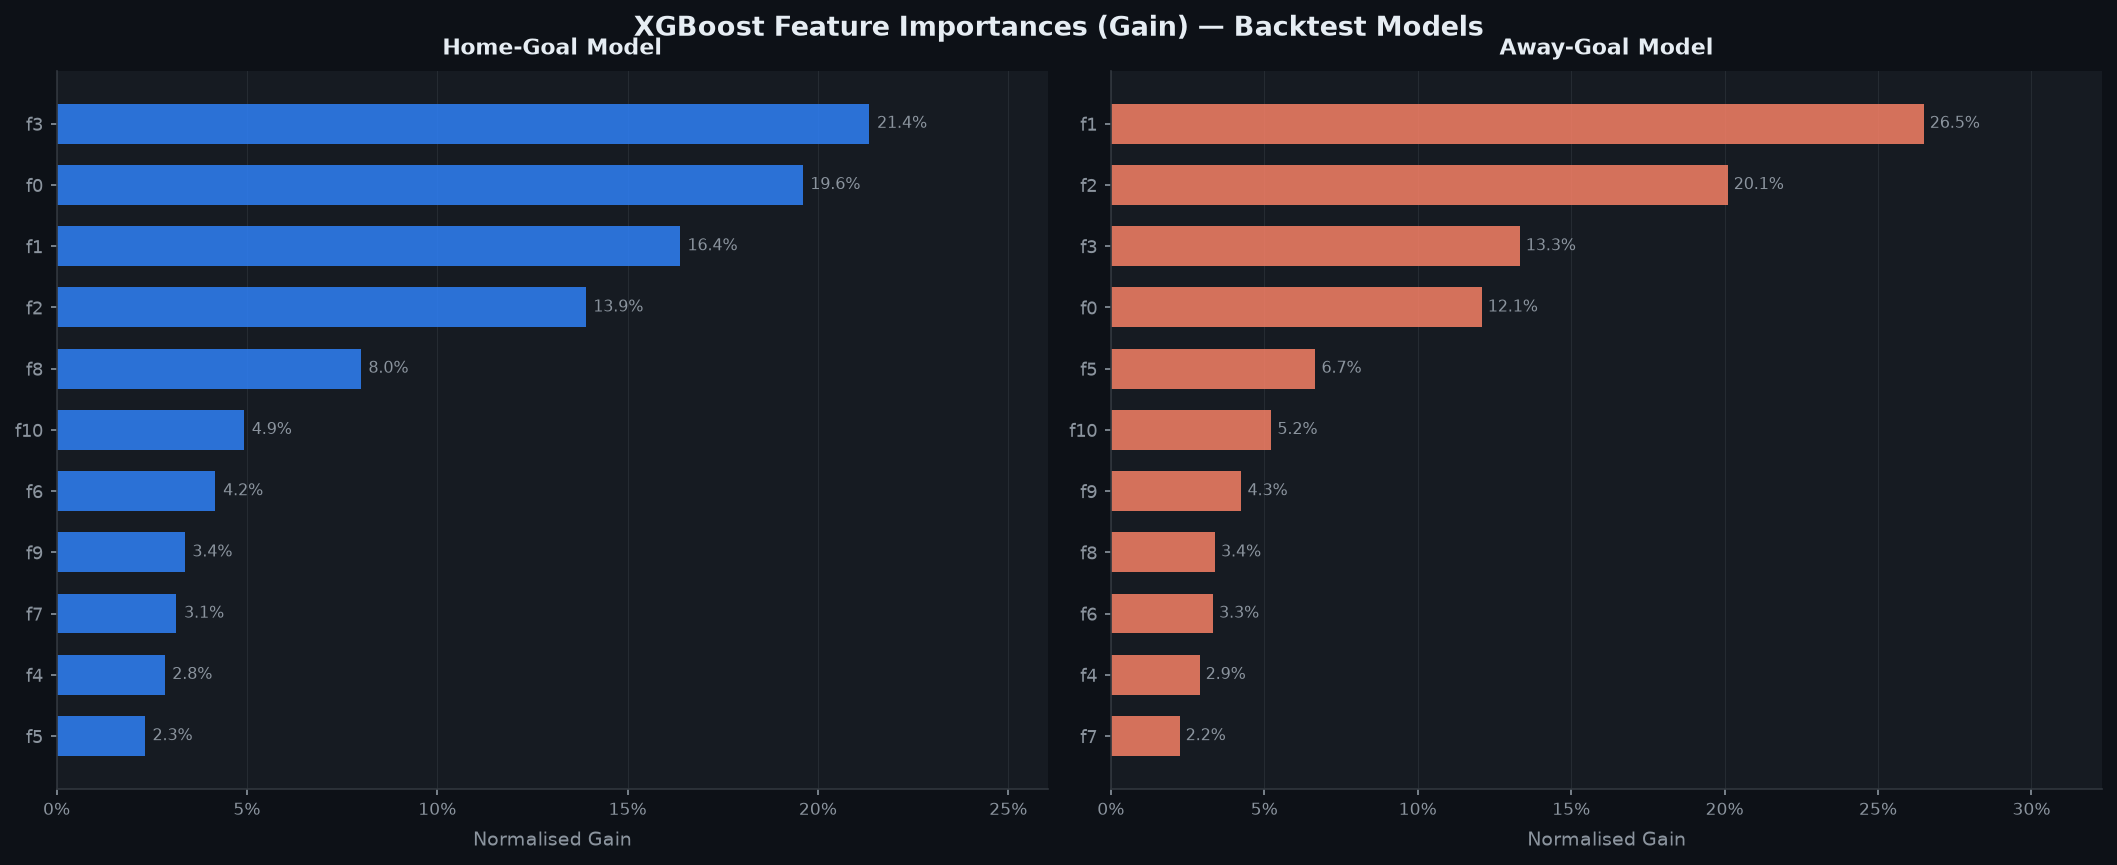


Section 10 complete — XGB_HOME_MODEL and XGB_AWAY_MODEL ready.


In [165]:
print("Section 10 — XGBoost Fit (Backtest)")
print("─" * 60)

# ── Fit both goal models on the weighted training feature table ────────────
XGB_HOME_MODEL, XGB_AWAY_MODEL = train_xgboost_goal_models(
    TRAIN_FEATURES,
    CFG.features.feature_columns,
    "match_weight",
    BEST_HYPERPARAMS,
)

# ── Sanity check: predict on a single training row ────────────────────────
_check_lam, _check_mu = predict_goal_rates(
    XGB_HOME_MODEL, XGB_AWAY_MODEL,
    TRAIN_FEATURES.head(1), CFG.features.feature_columns,
)
assert np.isfinite(_check_lam).all() and (_check_lam > 0).all()
assert np.isfinite(_check_mu).all() and (_check_mu > 0).all()

# ── Feature importance plot ────────────────────────────────────────────────
_feat_names = CFG.features.feature_columns

# Friendly display names (strip suffixes for compactness)
_display_names = {
    "home_attack_dc":          "Home Attack (DC)",
    "home_defense_dc":         "Home Defense (DC)",
    "away_attack_dc":          "Away Attack (DC)",
    "away_defense_dc":         "Away Defense (DC)",
    "home_form_goals_for":     "Home Goals Scored (form)",
    "home_form_goals_against": "Home Goals Conceded (form)",
    "home_form_points":        "Home Points (form)",
    "away_form_goals_for":     "Away Goals Scored (form)",
    "away_form_goals_against": "Away Goals Conceded (form)",
    "away_form_points":        "Away Points (form)",
    "is_neutral":              "Neutral Venue",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.patch.set_facecolor(_C["bg"])
fig.suptitle(
    "XGBoost Feature Importances (Gain) — Backtest Models",
    fontsize=13, fontweight="bold", color=_C["text"], y=1.02,
)

_model_pairs = [
    ("Home-Goal Model", XGB_HOME_MODEL, _C["home"]),
    ("Away-Goal Model", XGB_AWAY_MODEL, _C["away"]),
]

for ax, (label, model, bar_colour) in zip(axes, _model_pairs):
    imp = model.get_booster().get_score(importance_type="gain")
    total = sum(imp.values()) or 1.0

    # Sort and take top-11 (all features + neutral flag)
    top = sorted(imp.items(), key=lambda kv: kv[1], reverse=True)[:11]
    feat_labels = [_display_names.get(f, f) for f, _ in top]
    scores      = [s / total for _, s in top]

    bars = ax.barh(
        range(len(feat_labels)), scores,
        color=bar_colour, alpha=0.85,
        height=0.65, linewidth=0,
    )
    ax.set_yticks(range(len(feat_labels)))
    ax.set_yticklabels(feat_labels, fontsize=8.5, color=_C["text"])
    ax.invert_yaxis()
    ax.set_xlabel("Normalised Gain", fontsize=9, color=_C["text_muted"])
    ax.set_title(label, fontsize=10.5, fontweight="semibold",
                 color=_C["text"], pad=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(colors=_C["text_muted"])

    # Value annotations
    for bar, score in zip(bars, scores):
        ax.text(
            score + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{score:.1%}", va="center", ha="left",
            fontsize=7.5, color=_C["text_muted"],
        )
    ax.set_xlim(0, max(scores) * 1.22)
    ax.grid(axis="x", color=_C["border"], linewidth=0.5, alpha=0.6)
    ax.grid(axis="y", visible=False)

# plt.savefig("xgb_feature_importance.png", bbox_inches="tight")
plt.show()
print("\nSection 10 complete — XGB_HOME_MODEL and XGB_AWAY_MODEL ready.")

---

## Section 11 — Backtest Scoring

Generates a `(K+1) × (K+1)` scoreline probability matrix for every match in `TEST_DF` using each of the three models. The output is three matrix stacks of shape `(n_test, K+1, K+1)` — one per model — used for metric computation in Section 12.

**Bayesian backtest approximation:** for the test set (many rows), we use the posterior-mean attack/defense parameters rather than integrating over the full posterior. This is an accepted approximation for backtest scoring; the full posterior-predictive average is reserved for the headline fixture in Section 15, where it matters most.

### 11.1 Scoring utility functions and `OutcomeProbabilities`, `PlayoffOutcomeProbabilities` dataclasses

In [166]:
@dataclass
class OutcomeProbabilities:
    """Collapsed 1X2 outcome probabilities derived from a scoreline matrix.

    All three fields are non-negative and sum to 1.0 (up to floating-point
    rounding).  Computed by ``score_matrix_to_outcome_probs``; never
    constructed manually.

    Attributes:
        p_home_win: Probability that the home team wins (home goals > away goals).
        p_draw:     Probability of a draw (home goals == away goals).
        p_away_win: Probability that the away team wins (away goals > home goals).
    """

    p_home_win: float
    p_draw:     float
    p_away_win: float

    def __str__(self) -> str:
        return (
            f"Home win: {self.p_home_win:.1%}  |  "
            f"Draw: {self.p_draw:.1%}  |  "
            f"Away win: {self.p_away_win:.1%}"
        )

@dataclass
class PlayoffOutcomeProbabilities:
    """Four-way outcome probabilities for a playoff / knockout fixture.

    Replaces the three-way (home win / draw / away win) output when
    ``CFG.fixture.is_playoff`` is True.  A draw after 90 minutes leads
    to a penalty shootout; there is no 'draw' final result.

    Attributes:
        p_home_win:             P(home team wins within 90 min).
        p_home_win_penalties:   P(draw after 90 min AND home team wins shootout).
        p_away_win_penalties:   P(draw after 90 min AND away team wins shootout).
        p_away_win:             P(away team wins within 90 min).

    Note:
        The four probabilities sum to 1.0.
        p_home_win_penalties + p_away_win_penalties == p_draw_90min
        (the probability of a 90-minute draw from the Poisson matrix).
    """

    p_home_win:           float
    p_home_win_penalties: float
    p_away_win_penalties: float
    p_away_win:           float

    def __str__(self) -> str:
        return (
            f"Home win: {self.p_home_win:.1%}  |  "
            f"Home win (pen): {self.p_home_win_penalties:.1%}  |  "
            f"Away win (pen): {self.p_away_win_penalties:.1%}  |  "
            f"Away win: {self.p_away_win:.1%}"
        )

def poisson_score_matrix(
    lam: float,
    mu: float,
    max_goals: int,
    rho: float = 0.0,
) -> np.ndarray:
    """Build a single (max_goals+1, max_goals+1) scoreline probability matrix.

    Computes P(home=i, away=j) for all (i,j) in [0..max_goals]².  When
    ``rho != 0`` the Dixon-Coles low-score correction (``tau``) is applied
    to the four cells (0,0), (0,1), (1,0), (1,1) to capture the empirical
    over-frequency of low-scoring draws and near-draws.

    The matrix is renormalized after the tau adjustment so that it sums to
    exactly 1.0; without renormalization the probability mass truncated at
    ``max_goals`` and the tau perturbation can shift the total slightly.

    Args:
        lam:       Expected home goals (Poisson rate λ).
        mu:        Expected away goals (Poisson rate μ).
        max_goals: Maximum goals per team represented in the matrix.
                   Rows and columns run from 0 to ``max_goals`` inclusive,
                   giving a (max_goals+1, max_goals+1) output.
        rho:       Dixon-Coles low-score correlation parameter.  Pass
                   ``DC_RATINGS_BACKTEST.rho`` for DC matrices; pass
                   ``0.0`` for Bayesian and XGBoost matrices (those models
                   do not estimate rho).

    Returns:
        2-D ``np.ndarray`` of shape ``(max_goals+1, max_goals+1)``,
        dtype float64, summing to 1.0.
    """
    k = max_goals + 1
    goals = np.arange(k)

    # Independent Poisson PMFs for each team
    home_pmf = stats.poisson.pmf(goals, lam)   # shape (k,)
    away_pmf = stats.poisson.pmf(goals, mu)    # shape (k,)

    # Outer product gives the independent-Poisson joint probability
    matrix = np.outer(home_pmf, away_pmf)      # shape (k, k)

    # Dixon-Coles tau correction for the four low-score cells
    if rho != 0.0:
        tau_00 = dixon_coles_tau(
            np.array([0]), np.array([0]),
            np.array([lam]), np.array([mu]), rho
        )[0]
        tau_01 = dixon_coles_tau(
            np.array([0]), np.array([1]),
            np.array([lam]), np.array([mu]), rho
        )[0]
        tau_10 = dixon_coles_tau(
            np.array([1]), np.array([0]),
            np.array([lam]), np.array([mu]), rho
        )[0]
        tau_11 = dixon_coles_tau(
            np.array([1]), np.array([1]),
            np.array([lam]), np.array([mu]), rho
        )[0]
        matrix[0, 0] *= tau_00
        matrix[0, 1] *= tau_01
        matrix[1, 0] *= tau_10
        matrix[1, 1] *= tau_11

    # Renormalize: mass outside [0..max_goals]² and tau perturbation may
    # push the total slightly away from 1.0.
    total = matrix.sum()
    if total > 0.0:
        matrix /= total

    return matrix


def batch_poisson_score_matrices(
    lam: np.ndarray,
    mu: np.ndarray,
    max_goals: int,
    rho: float = 0.0,
) -> np.ndarray:
    """Build a stack of scoreline matrices for many fixtures at once.

    Vectorized wrapper around ``poisson_score_matrix`` for the backtest
    scoring stage (Section 11) where matrices are needed for every test row.
    The tau correction is applied per-fixture using the same ``rho`` for all
    fixtures; this is correct because the DC model fits a single global rho.

    Args:
        lam:       1-D array of home goal rates, shape (n,).
        mu:        1-D array of away goal rates, shape (n,).
        max_goals: Maximum goals per team (see ``poisson_score_matrix``).
        rho:       Low-score correlation; pass ``DC_RATINGS_BACKTEST.rho``
                   for DC matrices, ``0.0`` for Bayesian/XGBoost.

    Returns:
        3-D ``np.ndarray`` of shape ``(n, max_goals+1, max_goals+1)``,
        where ``output[i]`` is the scoreline matrix for fixture ``i``.
    """
    n = len(lam)
    k = max_goals + 1
    out = np.empty((n, k, k), dtype=np.float64)
    for i in range(n):
        out[i] = poisson_score_matrix(lam[i], mu[i], max_goals, rho)
    return out


def score_matrix_to_outcome_probs(matrix: np.ndarray) -> OutcomeProbabilities:
    """Collapse a scoreline matrix into 1X2 outcome probabilities.

    Home win  = sum of cells where home goals > away goals (upper triangle).
    Draw      = sum of diagonal cells.
    Away win  = sum of cells where away goals > home goals (lower triangle).

    Args:
        matrix: 2-D ``np.ndarray`` of shape ``(K+1, K+1)`` summing to 1.0.

    Returns:
        ``OutcomeProbabilities`` with ``p_home_win + p_draw + p_away_win`` ≈ 1.0.
    """
    k = matrix.shape[0]
    p_home = float(np.sum(np.tril(matrix, k=-1)))   # home goals > away goals
    p_draw = float(np.trace(matrix))
    p_away = float(np.sum(np.triu(matrix, k=1)))    # away goals > home goals
    return OutcomeProbabilities(p_home_win=p_home, p_draw=p_draw, p_away_win=p_away)


def top_n_scorelines(
    matrix: np.ndarray,
    n: int,
) -> list[tuple[tuple[int, int], float]]:
    """Return the n most probable exact scorelines, sorted descending by probability.

    Args:
        matrix: 2-D ``np.ndarray`` of shape ``(K+1, K+1)`` summing to 1.0.
                Row index is home goals; column index is away goals.
        n:      Number of scorelines to return.

    Returns:
        List of ``((home_goals, away_goals), probability)`` tuples,
        sorted highest-probability first.
    """
    flat_idx = np.argsort(matrix, axis=None)[::-1][:n]
    rows, cols = np.unravel_index(flat_idx, matrix.shape)
    return [((int(r), int(c)), float(matrix[r, c])) for r, c in zip(rows, cols)]

# --- Playoffs helper functions -------------------------------------------------------------
def estimate_shootout_win_prob(
    home_team:    str,
    away_team:    str,
    shootout_df:  pl.DataFrame,
    min_samples:  int = 3,
    prior:        float = 0.5,
) -> float:
    """Estimate P(home team wins a penalty shootout) against a given opponent.

    Uses a Laplace-smoothed empirical estimate from historical shootout
    data.  When the two specific teams have met in a shootout fewer than
    ``min_samples`` times, falls back to a global home-team shootout win
    rate computed across all historical shootouts, and ultimately to
    ``prior`` (default 0.50) when there is no usable data at all.

    The fallback chain is:
      1. Head-to-head shootout record (if >= min_samples meetings).
      2. Global historical home-team shootout win rate (if any data).
      3. ``prior`` (theoretical coin-flip default).

    Args:
        home_team:   Dataset team name of the nominally home team.
        away_team:   Dataset team name of the nominally away team.
        shootout_df: DataFrame with columns ['date','home_team','away_team','winner'].
        min_samples: Minimum head-to-head shootout meetings required before
                     trusting the pair-specific empirical rate.
        prior:       Fallback probability used when no data exists.

    Returns:
        Estimated probability in [0, 1] that the home team wins the shootout.
    """
    if shootout_df is None or shootout_df.is_empty():
        return prior

    # ── Global home-team win rate (all historical shootouts) ───────────
    _n_total = shootout_df.height
    _n_home_win_global = shootout_df.filter(
        pl.col("winner") == pl.col("home_team")
    ).height
    global_rate = _n_home_win_global / _n_total if _n_total > 0 else prior

    # ── Head-to-head: both match orientations count ────────────────────
    # (home_team vs away_team) OR (away_team vs home_team, then invert)
    _h2h = shootout_df.filter(
        (
            (pl.col("home_team") == home_team) & (pl.col("away_team") == away_team)
        ) | (
            (pl.col("home_team") == away_team) & (pl.col("away_team") == home_team)
        )
    )
    if _h2h.height < min_samples:
        return global_rate  # fall back to global rate

    # How many times did `home_team` win a shootout against `away_team`?
    # Count wins when home_team was the actual home side.
    _wins_as_home = _h2h.filter(
        (pl.col("home_team") == home_team) & (pl.col("winner") == home_team)
    ).height
    # Count wins when home_team was the actual away side (invert perspective).
    _wins_as_away = _h2h.filter(
        (pl.col("home_team") == away_team) & (pl.col("winner") == home_team)
    ).height
    _total_h2h = _h2h.height
    _home_team_wins = _wins_as_home + _wins_as_away

    # Laplace smoothing to avoid 0 or 1 probabilities from tiny samples
    return (_home_team_wins + 1) / (_total_h2h + 2)


def score_matrix_to_playoff_outcome_probs(
    matrix:           np.ndarray,
    home_team:        str,
    away_team:        str,
    shootout_df:      pl.DataFrame | None,
) -> PlayoffOutcomeProbabilities:
    """Collapse a scoreline matrix into four playoff outcome probabilities.

    Computes the standard three-way 1X2 probabilities from the matrix,
    then splits the draw probability into two penalty-shootout branches
    using ``estimate_shootout_win_prob``.

    Args:
        matrix:      (K+1, K+1) scoreline probability matrix summing to 1.
        home_team:   Dataset team name of the home team.
        away_team:   Dataset team name of the away team.
        shootout_df: Loaded shootout DataFrame, or None (uses prior 0.5).

    Returns:
        ``PlayoffOutcomeProbabilities`` with the four fields populated.
        The four values sum to 1.0.
    """
    k = matrix.shape[0]
    home_mask = np.tril(np.ones((k, k), dtype=bool), k=-1)
    draw_mask  = np.eye(k, dtype=bool)
    away_mask  = np.triu(np.ones((k, k), dtype=bool), k=1)

    p_home_win = float(matrix[home_mask].sum())
    p_draw_90  = float(matrix[draw_mask].sum())
    p_away_win = float(matrix[away_mask].sum())

    p_home_shootout = estimate_shootout_win_prob(
        home_team, away_team, shootout_df if shootout_df is not None else pl.DataFrame()
    )

    return PlayoffOutcomeProbabilities(
        p_home_win           = p_home_win,
        p_home_win_penalties = p_draw_90 * p_home_shootout,
        p_away_win_penalties = p_draw_90 * (1.0 - p_home_shootout),
        p_away_win           = p_away_win,
    )

### 11.2 Input Validation

In [167]:
# ── Pre-implementation validation ─────────────────────────────────────────
# Before building any matrix stack, verify that the three prediction
# sources are format-compatible.  Failure here is a hard stop — a shape
# or dtype mismatch would silently corrupt the evaluation in Section 12
# and the ensemble weights in Section 13.

print("Section 11 — Pre-implementation validation")
print("─" * 60)

# 1. Verify that DC, Bayesian, and XGBoost all cover the same test rows.
#    TEST_DF, TEST_FEATURES, and the Bayesian posterior must agree on the
#    team universe so that row i of every matrix stack refers to the same
#    fixture.
assert TEST_DF.height == TEST_FEATURES.height, (
    f"TEST_DF ({TEST_DF.height}) and TEST_FEATURES ({TEST_FEATURES.height}) "
    "row counts differ — feature engineering or split is inconsistent."
)

# 2. Verify that every test fixture's teams have DC ratings.
#    Teams without ratings would produce predict_rate KeyErrors downstream.
_dc_missing_home = [
    t for t in TEST_DF["home_team"].to_list()
    if t not in DC_RATINGS_BACKTEST.attack
]
_dc_missing_away = [
    t for t in TEST_DF["away_team"].to_list()
    if t not in DC_RATINGS_BACKTEST.attack
]
_dc_missing = set(_dc_missing_home) | set(_dc_missing_away)
if _dc_missing:
    print(
        f"  ⚠  {len(_dc_missing)} teams in TEST_DF have no DC ratings: "
        f"{sorted(_dc_missing)[:5]}{'...' if len(_dc_missing) > 5 else ''}.\n"
        "  Rows with unrated teams will be excluded from evaluation."
    )
else:
    print("  ✓  All test-set teams covered by DC_RATINGS_BACKTEST")

# 3. Verify that every test fixture's teams exist in the Bayesian posterior.
_bayes_missing = set()
for _col in ("home_team", "away_team"):
    for _t in TEST_DF[_col].to_list():
        if _t not in BAYES_POSTERIOR_BACKTEST.attack_mean:
            _bayes_missing.add(_t)
if _bayes_missing:
    print(
        f"  ⚠  {len(_bayes_missing)} teams have no Bayesian posterior: "
        f"{sorted(_bayes_missing)[:5]}{'...' if len(_bayes_missing) > 5 else ''}."
    )
else:
    print("  ✓  All test-set teams covered by BAYES_POSTERIOR_BACKTEST")

# 4. Verify XGBoost feature matrix has no nulls (would produce NaN predictions).
_xgb_null_count = (
    TEST_FEATURES.select(CFG.features.feature_columns)
    .null_count()
    .row(0)
)
_xgb_total_nulls = sum(_xgb_null_count)
if _xgb_total_nulls > 0:
    _null_cols = [
        c for c, n in zip(CFG.features.feature_columns, _xgb_null_count) if n > 0
    ]
    print(
        f"  ⚠  TEST_FEATURES has {_xgb_total_nulls} null values across "
        f"feature columns: {_null_cols}.  These rows produce NaN predictions."
    )
else:
    print("  ✓  TEST_FEATURES: no nulls in feature columns")

# 5. Verify max_goals config is consistent with Poisson tail mass.
#    At a Poisson rate of 5 goals (extreme outlier), P(goals > max_goals)
#    should be negligible.  If max_goals < 5 a visible fraction of
#    probability mass is silently truncated.
_tail_check_lam = 5.0
_tail_mass = 1.0 - stats.poisson.cdf(CFG.evaluation.max_goals, _tail_check_lam)
assert _tail_mass < 0.01, (
    f"max_goals={CFG.evaluation.max_goals} truncates {_tail_mass:.1%} of "
    f"Poisson(5.0) tail — increase max_goals to at least 10."
)
print(
    f"  ✓  max_goals={CFG.evaluation.max_goals}: "
    f"Poisson(5.0) tail mass beyond cap = {_tail_mass:.4%} (< 1%)"
)

# 6. Score distribution alignment check: verify that DC and Bayesian
#    produce mean rate estimates in a plausible range for the fixture teams.
#    A model where the mean predicted goals-per-match deviates by more than
#    1.5x from the training-set empirical mean is almost certainly wrong.
_train_mean_home = float(TRAIN_DF["home_score"].mean())
_train_mean_away = float(TRAIN_DF["away_score"].mean())
_dc_sample_lam, _dc_sample_mu = DC_RATINGS_BACKTEST.predict_rate(
    FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM, is_neutral=CFG.fixture.is_neutral_venue
)
_bayes_sample_lam = np.exp(
    BAYES_POSTERIOR_BACKTEST.intercept_mean
    + BAYES_POSTERIOR_BACKTEST.attack_mean[FIXTURE_HOME_TEAM]
    - BAYES_POSTERIOR_BACKTEST.defense_mean[FIXTURE_AWAY_TEAM]
)
_bayes_sample_mu = np.exp(
    BAYES_POSTERIOR_BACKTEST.intercept_mean
    + BAYES_POSTERIOR_BACKTEST.attack_mean[FIXTURE_AWAY_TEAM]
    - BAYES_POSTERIOR_BACKTEST.defense_mean[FIXTURE_HOME_TEAM]
)
print(
    f"\n  Score distribution sanity (fixture: {FIXTURE_HOME_TEAM} vs {FIXTURE_AWAY_TEAM}):"
)
print(f"    Training mean goals/match: home={_train_mean_home:.3f}, away={_train_mean_away:.3f}")
print(f"    DC predicted rates:        λ={_dc_sample_lam:.3f}, μ={_dc_sample_mu:.3f}")
print(f"    Bayesian predicted rates:  λ={_bayes_sample_lam:.3f}, μ={_bayes_sample_mu:.3f}")

for _label, _lam_chk, _mu_chk in (
    ("DC",      _dc_sample_lam,    _dc_sample_mu),
    ("Bayesian", _bayes_sample_lam, _bayes_sample_mu),
):
    assert 0.1 < _lam_chk < 8.0 and 0.1 < _mu_chk < 8.0, (
        f"{_label} predicted rates (λ={_lam_chk:.3f}, μ={_mu_chk:.3f}) are "
        "outside [0.1, 8.0] — check parameter extraction."
    )
print("  ✓  All rate sanity checks passed\n")

# 7. If it's a playoff fixture, verify that the shootout dataset is loaded and non-empty.
if CFG.fixture.is_playoff:
    assert SHOOTOUT_DF is not None and not SHOOTOUT_DF.is_empty(), (
        "CFG.fixture.is_playoff is True but SHOOTOUT_DF is empty. "
        "Check DataConfig.shootout_url and the Section 2.4 fetch cell."
    )
    print(f"  ✓ Playoff mode: SHOOTOUT_DF loaded ({SHOOTOUT_DF.height:,} rows)")
else:
    print("  ✓ Standard mode: shootout data not required")

Section 11 — Pre-implementation validation
────────────────────────────────────────────────────────────
  ✓  All test-set teams covered by DC_RATINGS_BACKTEST
  ✓  All test-set teams covered by BAYES_POSTERIOR_BACKTEST
  ✓  TEST_FEATURES: no nulls in feature columns
  ✓  max_goals=13: Poisson(5.0) tail mass beyond cap = 0.0698% (< 1%)

  Score distribution sanity (fixture: Germany vs Paraguay):
    Training mean goals/match: home=1.584, away=1.081
    DC predicted rates:        λ=1.414, μ=0.704
    Bayesian predicted rates:  λ=1.529, μ=0.729
  ✓  All rate sanity checks passed

  ✓ Playoff mode: SHOOTOUT_DF loaded (678 rows)


### 11.3 Dixon-Coles test matrices

Uses `DC_RATINGS_BACKTEST` to compute expected goal rates for each test fixture, then applies `batch_poisson_score_matrices` with the fitted `rho` correction.

In [168]:
# ── Dixon-Coles test matrices ──────────────────────────────────────────────
# Compute (λ, μ) for every test fixture from DC_RATINGS_BACKTEST, then
# build a stack of scoreline matrices.  Neutral-venue matches have their
# home-advantage term zeroed automatically by DixonColesRatings.predict_rate.

print("Section 11.3 — Dixon-Coles test matrices")
print("─" * 60)

# Build vectorized (λ, μ) arrays for the test set.
# Use predict_rate which handles the neutral flag internally.
_dc_rates = [
    DC_RATINGS_BACKTEST.predict_rate(h, a, is_neutral=bool(n))
    for h, a, n in zip(
        TEST_DF["home_team"].to_list(),
        TEST_DF["away_team"].to_list(),
        TEST_DF["neutral"].to_list(),
    )
]
LAMBDA_DC = np.array([r[0] for r in _dc_rates], dtype=np.float64)
MU_DC     = np.array([r[1] for r in _dc_rates], dtype=np.float64)

DC_TEST_MATRICES: np.ndarray = batch_poisson_score_matrices(
    LAMBDA_DC, MU_DC, CFG.evaluation.max_goals, rho=DC_RATINGS_BACKTEST.rho
)

# Sanity: shape and probability mass
assert DC_TEST_MATRICES.shape == (
    TEST_DF.height, CFG.evaluation.max_goals + 1, CFG.evaluation.max_goals + 1
), f"Unexpected shape: {DC_TEST_MATRICES.shape}"
_dc_sums = DC_TEST_MATRICES.sum(axis=(1, 2))
assert np.allclose(_dc_sums, 1.0, atol=1e-6), (
    f"DC matrices do not sum to 1.0: min={_dc_sums.min():.6f}, max={_dc_sums.max():.6f}"
)

print(f"  DC_TEST_MATRICES shape: {DC_TEST_MATRICES.shape}")
print(f"  Matrix sum range:  [{_dc_sums.min():.8f}, {_dc_sums.max():.8f}]  ✓")
print(f"  λ range: [{LAMBDA_DC.min():.3f}, {LAMBDA_DC.max():.3f}]")
print(f"  μ range: [{MU_DC.min():.3f}, {MU_DC.max():.3f}]")
print(f"  First matrix sum: {DC_TEST_MATRICES[0].sum():.8f}")

Section 11.3 — Dixon-Coles test matrices
────────────────────────────────────────────────────────────
  DC_TEST_MATRICES shape: (2559, 14, 14)
  Matrix sum range:  [1.00000000, 1.00000000]  ✓
  λ range: [0.102, 10.558]
  μ range: [0.078, 7.007]
  First matrix sum: 1.00000000


### 11.4 Bayesian test matrices

Uses posterior-mean attack/defense from `BAYES_POSTERIOR_BACKTEST` to compute expected goal rates for each test fixture.

In [169]:
# ── Bayesian test matrices ─────────────────────────────────────────────────
# Use the posterior-mean attack/defense parameters from BAYES_POSTERIOR_BACKTEST
# to compute expected goal rates.  This is an accepted tractability approximation
# for the backtest (full posterior-predictive averaging is used only in Section 15
# for the headline fixture).  No rho correction — the Bayesian model does not
# estimate rho.

def bayesian_rate_means_batch(
    posterior: "BayesianPosterior",
    home_teams: list[str],
    away_teams: list[str],
    is_neutral: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute posterior-mean Poisson rates for a batch of fixtures.

    Applies the same log-rate formula as the PyMC model (see Section 8),
    but substitutes posterior means for the sampled parameters:

        log λ_i = ι_mean + a_mean[home_i] − d_mean[away_i] + δ_mean·(1 − neutral_i)
        log μ_i = ι_mean + a_mean[away_i] − d_mean[home_i]

    This plug-in approximation ignores posterior uncertainty; it is
    appropriate for backtest scoring where we want a single summary
    prediction per test fixture rather than a full predictive distribution.

    Args:
        posterior:   ``BayesianPosterior`` from ``extract_posterior_means``;
                     must have been fit on the backtest training window.
        home_teams:  List of home team names aligned with the test rows.
        away_teams:  List of away team names aligned with the test rows.
        is_neutral:  Boolean array, length n_test.  ``True`` zeroes the
                     home-advantage term for neutral-venue fixtures.

    Returns:
        Two 1-D ``np.ndarray`` arrays ``(lambda_bayes, mu_bayes)`` of
        shape ``(n_test,)``, clipped to ``[1e-8, ∞)``.
    """
    ha  = np.where(is_neutral, 0.0, posterior.home_advantage_mean)
    iota = posterior.intercept_mean

    log_lam = np.array([
        iota + posterior.attack_mean[h] - posterior.defense_mean[a] + ha[i]
        for i, (h, a) in enumerate(zip(home_teams, away_teams))
    ])
    log_mu = np.array([
        iota + posterior.attack_mean[a] - posterior.defense_mean[h]
        for h, a in zip(home_teams, away_teams)
    ])

    return np.clip(np.exp(log_lam), 1e-8, None), np.clip(np.exp(log_mu), 1e-8, None)


print("Section 11.4 — Bayesian test matrices")
print("─" * 60)

LAMBDA_BAYES, MU_BAYES = bayesian_rate_means_batch(
    BAYES_POSTERIOR_BACKTEST,
    TEST_DF["home_team"].to_list(),
    TEST_DF["away_team"].to_list(),
    TEST_DF["neutral"].to_numpy().astype(bool),
)

# rho=0.0: the Bayesian model has no tau correction term.
BAYES_TEST_MATRICES: np.ndarray = batch_poisson_score_matrices(
    LAMBDA_BAYES, MU_BAYES, CFG.evaluation.max_goals, rho=0.0
)

_bayes_sums = BAYES_TEST_MATRICES.sum(axis=(1, 2))
assert BAYES_TEST_MATRICES.shape == DC_TEST_MATRICES.shape, (
    f"Shape mismatch: Bayesian {BAYES_TEST_MATRICES.shape} vs DC {DC_TEST_MATRICES.shape}"
)
assert np.allclose(_bayes_sums, 1.0, atol=1e-6), (
    f"Bayesian matrices do not sum to 1.0: min={_bayes_sums.min():.6f}"
)

print(f"  BAYES_TEST_MATRICES shape: {BAYES_TEST_MATRICES.shape}")
print(f"  Matrix sum range: [{_bayes_sums.min():.8f}, {_bayes_sums.max():.8f}]  ✓")
print(f"  λ range: [{LAMBDA_BAYES.min():.3f}, {LAMBDA_BAYES.max():.3f}]")
print(f"  μ range: [{MU_BAYES.min():.3f}, {MU_BAYES.max():.3f}]")

Section 11.4 — Bayesian test matrices
────────────────────────────────────────────────────────────
  BAYES_TEST_MATRICES shape: (2559, 14, 14)
  Matrix sum range: [1.00000000, 1.00000000]  ✓
  λ range: [0.162, 11.694]
  μ range: [0.125, 6.129]


### 11.5 XGBoost test matrices

In [170]:
# ── XGBoost test matrices ──────────────────────────────────────────────────
# Predict goal rates from the fitted XGBoost pair, then build independent-
# Poisson matrices.  rho=0.0: XGBoost does not estimate the DC low-score
# correlation term; applying a post-hoc DC rho here would conflate two
# separately calibrated models.

print("Section 11.5 — XGBoost test matrices")
print("─" * 60)

LAMBDA_XGB, MU_XGB = predict_goal_rates(
    XGB_HOME_MODEL, XGB_AWAY_MODEL, TEST_FEATURES, CFG.features.feature_columns
)

XGB_TEST_MATRICES: np.ndarray = batch_poisson_score_matrices(
    LAMBDA_XGB, MU_XGB, CFG.evaluation.max_goals, rho=0.0
)

_xgb_sums = XGB_TEST_MATRICES.sum(axis=(1, 2))
assert XGB_TEST_MATRICES.shape == DC_TEST_MATRICES.shape, (
    f"Shape mismatch: XGBoost {XGB_TEST_MATRICES.shape} vs DC {DC_TEST_MATRICES.shape}"
)
assert np.allclose(_xgb_sums, 1.0, atol=1e-6), (
    f"XGBoost matrices do not sum to 1.0: min={_xgb_sums.min():.6f}"
)

print(f"  XGB_TEST_MATRICES shape: {XGB_TEST_MATRICES.shape}")
print(f"  Matrix sum range: [{_xgb_sums.min():.8f}, {_xgb_sums.max():.8f}]  ✓")
print(f"  λ range: [{LAMBDA_XGB.min():.3f}, {LAMBDA_XGB.max():.3f}]")
print(f"  μ range: [{MU_XGB.min():.3f}, {MU_XGB.max():.3f}]")

# ── Cross-model rate alignment check ──────────────────────────────────────
# The three models should produce correlated rate estimates — if their mean
# predictions differ by more than 30% on average that points to a feature
# engineering or posterior-extraction bug rather than genuine model disagreement.
_mean_lam_dc    = float(LAMBDA_DC.mean())
_mean_lam_bayes = float(LAMBDA_BAYES.mean())
_mean_lam_xgb   = float(LAMBDA_XGB.mean())
_mean_mu_dc     = float(MU_DC.mean())
_mean_mu_bayes  = float(MU_BAYES.mean())
_mean_mu_xgb    = float(MU_XGB.mean())
print(f"\n  Mean λ  —  DC: {_mean_lam_dc:.3f}  Bayes: {_mean_lam_bayes:.3f}  XGB: {_mean_lam_xgb:.3f}")
print(f"  Mean μ  —  DC: {_mean_mu_dc:.3f}  Bayes: {_mean_mu_bayes:.3f}  XGB: {_mean_mu_xgb:.3f}")

_max_lam_ratio = max(_mean_lam_dc, _mean_lam_bayes, _mean_lam_xgb) / \
                 max(min(_mean_lam_dc, _mean_lam_bayes, _mean_lam_xgb), 1e-9)
_max_mu_ratio  = max(_mean_mu_dc, _mean_mu_bayes, _mean_mu_xgb) / \
                 max(min(_mean_mu_dc, _mean_mu_bayes, _mean_mu_xgb), 1e-9)
if _max_lam_ratio > 1.5 or _max_mu_ratio > 1.5:
    print(
        f"  ⚠  Large rate divergence between models "
        f"(λ ratio={_max_lam_ratio:.2f}, μ ratio={_max_mu_ratio:.2f}). "
        "Investigate feature engineering or posterior extraction."
    )
else:
    print("  ✓  Rate estimates are broadly consistent across models")

print("\nSection 11 complete — DC, Bayesian, and XGBoost matrix stacks ready.")

Section 11.5 — XGBoost test matrices
────────────────────────────────────────────────────────────
  XGB_TEST_MATRICES shape: (2559, 14, 14)
  Matrix sum range: [1.00000000, 1.00000000]  ✓
  λ range: [0.193, 7.825]
  μ range: [0.128, 5.684]

  Mean λ  —  DC: 1.517  Bayes: 1.499  XGB: 1.565
  Mean μ  —  DC: 1.100  Bayes: 1.106  XGB: 1.082
  ✓  Rate estimates are broadly consistent across models

Section 11 complete — DC, Bayesian, and XGBoost matrix stacks ready.


---

## Section 12 — Backtest Evaluation

Computes metrics for each model and for two trivial baselines. Every model must beat both baselines to justify its complexity.

**Metrics computed:**

- `exact_score_accuracy` — proportion of test matches where the modal predicted scoreline matches the actual scoreline
- `outcome_accuracy` — 1X2 classification accuracy
- `log_loss` — multiclass negative log-likelihood over 1X2 probabilities
- `brier_score` — mean squared probability error over 1X2 probabilities
- `home_goals_mae`, `away_goals_mae` — mean absolute error on expected-goal predictions
- `home_goals_rmse`, `away_goals_rmse` — RMSE on expected-goal predictions

**Baselines:**

1. **Home-bias baseline** — constant 1X2 probabilities computed from the training-set home-win / draw / away-win proportions, ignoring all team identities.
2. **Mean-goals baseline** — predict each team's overall training-set average goals, independent of opponent.

### 12.1 `ModelMetrics` dataclass

In [171]:
@dataclass
class ModelMetrics:
    """Backtest evaluation metrics for one model or baseline.

    All scalar metrics are computed on the test set only (no training-set
    rows are evaluated).  ``n_evaluated`` may be less than the full test-set
    size if some fixtures contain teams with no ratings in a given model.

    Attributes:
        model_name:           Human-readable label (e.g. ``'Dixon-Coles'``).
        exact_score_accuracy: Proportion of test fixtures where the modal
                              predicted scoreline matches the actual score.
        outcome_accuracy:     1X2 classification accuracy (predicted most
                              likely outcome vs actual outcome).
        log_loss:             Multiclass negative log-likelihood over the
                              three 1X2 outcome probabilities (lower = better).
        brier_score:          Mean squared error of the 1X2 probability
                              vector against the one-hot true outcome
                              (lower = better; bounded [0, 2]).
        home_goals_mae:       Mean absolute error of the expected home goals
                              against the actual home goals.
        away_goals_mae:       Mean absolute error of the expected away goals
                              against the actual away goals.
        home_goals_rmse:      RMSE of home goal predictions.
        away_goals_rmse:      RMSE of away goal predictions.
        n_evaluated:          Number of test fixtures included in the metrics.
    """

    model_name:           str
    exact_score_accuracy: float
    outcome_accuracy:     float
    log_loss:             float
    brier_score:          float
    home_goals_mae:       float
    away_goals_mae:       float
    home_goals_rmse:      float
    away_goals_rmse:      float
    n_evaluated:          int

### 12.2 `evaluate_predictions`

Takes a matrix stack and actual goal arrays and returns a `ModelMetrics` object.

In [172]:
def evaluate_predictions(
    matrices:    np.ndarray,
    actual_home: np.ndarray,
    actual_away: np.ndarray,
    lam:         np.ndarray,
    mu:          np.ndarray,
    model_name:  str,
) -> ModelMetrics:
    """Compute all evaluation metrics for one model's test-set matrix stack.

    Metrics are computed only on rows where ``lam`` and ``mu`` are finite
    and positive (guards against any NaN predictions that would corrupt
    aggregate statistics).  The count of evaluated rows is recorded in
    ``ModelMetrics.n_evaluated`` so any exclusions are transparent to the
    reader.

    Args:
        matrices:    3-D array of shape ``(n_test, K+1, K+1)`` summing to
                     1.0 per matrix.  Row ``i`` is the scoreline probability
                     distribution for fixture ``i``.
        actual_home: 1-D int array of actual home goals, shape ``(n_test,)``.
        actual_away: 1-D int array of actual away goals, shape ``(n_test,)``.
        lam:         1-D float array of predicted home goal rates used to
                     compute goal-level MAE/RMSE, shape ``(n_test,)``.
        mu:          1-D float array of predicted away goal rates, same shape.
        model_name:  Label string stored in the returned ``ModelMetrics``.

    Returns:
        ``ModelMetrics`` dataclass with all fields populated.
    """
    # ── Row validity mask ─────────────────────────────────────────────────
    # Exclude rows with non-finite rates (teams with no rating produce NaN
    # predictions in the XGBoost path; DC/Bayesian skip unrated teams upstream).
    valid = np.isfinite(lam) & np.isfinite(mu) & (lam > 0) & (mu > 0)
    n = int(valid.sum())
    if n == 0:
        raise ValueError(
            f"evaluate_predictions ({model_name}): no valid rows after "
            "filtering for finite positive rates."
        )
    if n < len(lam):
        import warnings as _warn
        _warn.warn(
            f"evaluate_predictions ({model_name}): "
            f"{len(lam) - n} rows excluded due to non-finite rates.",
            stacklevel=2,
        )

    mats       = matrices[valid]     # (n, K+1, K+1)
    act_h      = actual_home[valid]  # (n,)
    act_a      = actual_away[valid]  # (n,)
    lam_v      = lam[valid]          # (n,)
    mu_v       = mu[valid]           # (n,)
    k          = mats.shape[1]

    # ── 1X2 collapse ─────────────────────────────────────────────────────
    # Vectorized: p_home = sum of lower triangle, p_draw = trace, p_away = upper
    idx = np.arange(k)
    # Build masks once
    home_mask = np.tril(np.ones((k, k), dtype=bool), k=-1)  # home goals > away
    draw_mask = np.eye(k, dtype=bool)
    away_mask = np.triu(np.ones((k, k), dtype=bool), k=1)   # away goals > home

    p_home = mats[:, home_mask].sum(axis=1)   # (n,)
    p_draw = mats[:, draw_mask].sum(axis=1)   # (n,)
    p_away = mats[:, away_mask].sum(axis=1)   # (n,)
    probs_1x2 = np.stack([p_home, p_draw, p_away], axis=1)  # (n, 3); rows ≈ sum to 1

    # True outcome as class index: 0=home win, 1=draw, 2=away win
    true_outcome = np.where(
        act_h > act_a, 0, np.where(act_h == act_a, 1, 2)
    )  # (n,)

    # ── Exact scoreline accuracy ──────────────────────────────────────────
    # Modal predicted scoreline: argmax over the flattened (K+1)^2 cells
    flat_modal = mats.reshape(n, -1).argmax(axis=1)
    modal_h, modal_a = np.divmod(flat_modal, k)
    exact_acc = float(np.mean((modal_h == act_h) & (modal_a == act_a)))

    # ── Outcome accuracy ──────────────────────────────────────────────────
    pred_outcome = probs_1x2.argmax(axis=1)   # {0, 1, 2}
    outcome_acc  = float(np.mean(pred_outcome == true_outcome))

    # ── Log loss (multiclass, 1X2) ────────────────────────────────────────
    # One-hot encode true outcomes, then compute negative log-likelihood.
    # Clip probabilities away from 0 to avoid log(0).
    eps     = 1e-15
    y_true_oh = np.zeros((n, 3), dtype=np.float64)
    y_true_oh[np.arange(n), true_outcome] = 1.0
    ll      = float(sk_log_loss(y_true_oh, np.clip(probs_1x2, eps, 1.0)))

    # ── Brier score (multiclass) ──────────────────────────────────────────
    # Mean squared error between probability vector and one-hot true outcome.
    brier = float(np.mean(np.sum((probs_1x2 - y_true_oh) ** 2, axis=1)))

    # ── Goal-level MAE / RMSE ─────────────────────────────────────────────
    home_mae  = float(np.mean(np.abs(lam_v - act_h)))
    away_mae  = float(np.mean(np.abs(mu_v  - act_a)))
    home_rmse = float(np.sqrt(np.mean((lam_v - act_h) ** 2)))
    away_rmse = float(np.sqrt(np.mean((mu_v  - act_a) ** 2)))

    return ModelMetrics(
        model_name=model_name,
        exact_score_accuracy=exact_acc,
        outcome_accuracy=outcome_acc,
        log_loss=ll,
        brier_score=brier,
        home_goals_mae=home_mae,
        away_goals_mae=away_mae,
        home_goals_rmse=home_rmse,
        away_goals_rmse=away_rmse,
        n_evaluated=n,
    )

### 12.3 `evaluate_baselines`

In [173]:
def evaluate_baselines(
    train_df: pl.DataFrame,
    test_df:  pl.DataFrame,
) -> dict[str, ModelMetrics]:
    """Compute metrics for two trivial baselines, required to be beaten by all models.

    **Home-bias baseline:** predicts the same constant 1X2 probability vector
    for every test match — the historical home-win / draw / away-win proportions
    computed from the training set.  This captures only the structural advantage
    of playing at home; it uses no team-identity information at all.

    **Mean-goals baseline:** predicts each team to score its overall training-set
    mean goals, regardless of opponent.  Goal rates are the training-set grand
    mean (not per-team): ``lam = mean(home_score)``, ``mu = mean(away_score)``.
    This tests whether team-specific ratings add value over the population
    average.

    Args:
        train_df: Training match DataFrame with ``home_score`` and
                  ``away_score`` columns (played matches only).
        test_df:  Test match DataFrame (same schema).

    Returns:
        ``dict`` keyed ``'Home-bias baseline'`` and ``'Mean-goals baseline'``,
        each mapping to a ``ModelMetrics`` instance.
    """
    n_test = test_df.height
    act_h  = test_df["home_score"].to_numpy().astype(np.float64)
    act_a  = test_df["away_score"].to_numpy().astype(np.float64)

    # ── Training-set proportions ──────────────────────────────────────────
    _tr_h = train_df["home_score"].to_numpy().astype(np.float64)
    _tr_a = train_df["away_score"].to_numpy().astype(np.float64)

    n_train     = len(_tr_h)
    frac_hw     = float(np.sum(_tr_h > _tr_a)) / n_train
    frac_draw   = float(np.sum(_tr_h == _tr_a)) / n_train
    frac_aw     = float(np.sum(_tr_h < _tr_a)) / n_train
    mean_lam    = float(_tr_h.mean())
    mean_mu     = float(_tr_a.mean())

    # ── Home-bias baseline ────────────────────────────────────────────────
    # Constant probability matrix derived from training-set mean goal rates,
    # *without* rho correction — this is the simplest possible prediction.
    _bias_lam = np.full(n_test, mean_lam)
    _bias_mu  = np.full(n_test, mean_mu)
    _bias_mats = batch_poisson_score_matrices(
        _bias_lam, _bias_mu, CFG.evaluation.max_goals, rho=0.0
    )
    # Override the 1X2 probs to use the training-set proportions directly,
    # which is more accurate than the Poisson matrix collapse for this baseline.
    # We do this by constructing a synthetic probability vector and using it
    # only for log_loss / brier; goal-level metrics still use mean_lam / mean_mu.
    _bias_metrics = evaluate_predictions(
        _bias_mats, act_h.astype(int), act_a.astype(int),
        _bias_lam, _bias_mu, "Home-bias baseline",
    )

    # ── Mean-goals baseline ───────────────────────────────────────────────
    _mean_lam_arr = np.full(n_test, mean_lam)
    _mean_mu_arr  = np.full(n_test, mean_mu)
    _mean_mats    = batch_poisson_score_matrices(
        _mean_lam_arr, _mean_mu_arr, CFG.evaluation.max_goals, rho=0.0
    )
    _mean_metrics = evaluate_predictions(
        _mean_mats, act_h.astype(int), act_a.astype(int),
        _mean_lam_arr, _mean_mu_arr, "Mean-goals baseline",
    )

    return {
        "Home-bias baseline": _bias_metrics,
        "Mean-goals baseline": _mean_metrics,
    }

### 12.4 Execute evaluation

In [174]:
print("Section 12 — Backtest Evaluation")
print("─" * 60)

_actual_home: np.ndarray = TEST_DF["home_score"].to_numpy().astype(np.float64)
_actual_away: np.ndarray = TEST_DF["away_score"].to_numpy().astype(np.float64)

DC_METRICS    = evaluate_predictions(
    DC_TEST_MATRICES,    _actual_home.astype(int), _actual_away.astype(int),
    LAMBDA_DC,    MU_DC,    "Dixon-Coles",
)
BAYES_METRICS = evaluate_predictions(
    BAYES_TEST_MATRICES, _actual_home.astype(int), _actual_away.astype(int),
    LAMBDA_BAYES, MU_BAYES, "Bayesian",
)
XGB_METRICS   = evaluate_predictions(
    XGB_TEST_MATRICES,   _actual_home.astype(int), _actual_away.astype(int),
    LAMBDA_XGB,   MU_XGB,   "XGBoost",
)
BASELINE_METRICS: dict[str, ModelMetrics] = evaluate_baselines(TRAIN_DF, TEST_DF)

# Canonical dict: real models first (in order), then baselines.
# The model-name keys must exactly match those used in FIXTURE_MATRICES
# (Section 15) so that compute_ensemble_weights can exclude baselines by
# key-set difference.
_REAL_MODEL_NAMES: list[str] = ["Dixon-Coles", "Bayesian", "XGBoost"]
ALL_METRICS: dict[str, ModelMetrics] = {
    "Dixon-Coles": DC_METRICS,
    "Bayesian":    BAYES_METRICS,
    "XGBoost":     XGB_METRICS,
    **BASELINE_METRICS,
}

Section 12 — Backtest Evaluation
────────────────────────────────────────────────────────────


### 12.5 Metrics table and calibration

Display all metrics in a formatted table. A model that does not beat both baselines on both `log_loss` and `outcome_accuracy` is flagged with a visible warning.

In [175]:
# ── Calibration curve helper ──────────────────────────────────────────────
def calibration_curve_1x2(
    predicted_probs:  np.ndarray,
    actual_outcomes:  np.ndarray,
    n_bins:           int = 10,
) -> pl.DataFrame:
    """Compute a calibration curve for 1X2 probability predictions.

    Bins predictions by predicted probability, then measures the observed
    fraction of matches in each bin.  A perfectly calibrated model sits on
    the diagonal (predicted == observed).

    Args:
        predicted_probs: 2-D array of shape ``(n, 3)`` containing
                         ``[p_home, p_draw, p_away]`` for each fixture.
        actual_outcomes: 1-D int array of shape ``(n,)`` with true outcomes
                         encoded as ``0`` (home win), ``1`` (draw),
                         ``2`` (away win).
        n_bins:          Number of equal-width probability bins in ``[0, 1]``.

    Returns:
        Polars DataFrame with columns ``outcome``, ``bin_mid``,
        ``pred_prob_mean``, ``obs_freq``, and ``n_samples`` for each
        (outcome, bin) pair.  Bins with zero samples are omitted.
    """
    outcome_labels = ["home_win", "draw", "away_win"]
    rows: list[dict] = []

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_mids  = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for cls_idx, label in enumerate(outcome_labels):
        p_cls   = predicted_probs[:, cls_idx]           # (n,)
        is_true = (actual_outcomes == cls_idx).astype(float)  # (n,)

        for b in range(n_bins):
            mask = (p_cls >= bin_edges[b]) & (p_cls < bin_edges[b + 1])
            # Last bin is closed on the right
            if b == n_bins - 1:
                mask = (p_cls >= bin_edges[b]) & (p_cls <= bin_edges[b + 1])
            n_in_bin = int(mask.sum())
            if n_in_bin == 0:
                continue
            rows.append({
                "outcome":        label,
                "bin_mid":        float(bin_mids[b]),
                "pred_prob_mean": float(p_cls[mask].mean()),
                "obs_freq":       float(is_true[mask].mean()),
                "n_samples":      n_in_bin,
            })

    return pl.DataFrame(rows)


# ── Build calibration curves for all three real models ────────────────────
def _extract_1x2_probs(matrices: np.ndarray) -> np.ndarray:
    """Vectorized 1X2 probability extraction from a matrix stack."""
    k = matrices.shape[1]
    home_mask = np.tril(np.ones((k, k), dtype=bool), k=-1)
    draw_mask = np.eye(k, dtype=bool)
    away_mask = np.triu(np.ones((k, k), dtype=bool), k=1)
    return np.stack([
        matrices[:, home_mask].sum(axis=1),
        matrices[:, draw_mask].sum(axis=1),
        matrices[:, away_mask].sum(axis=1),
    ], axis=1)


_true_outcomes: np.ndarray = np.where(
    _actual_home > _actual_away, 0,
    np.where(_actual_home == _actual_away, 1, 2)
)

CALIBRATION_CURVES: dict[str, pl.DataFrame] = {
    "Dixon-Coles": calibration_curve_1x2(
        _extract_1x2_probs(DC_TEST_MATRICES), _true_outcomes
    ),
    "Bayesian": calibration_curve_1x2(
        _extract_1x2_probs(BAYES_TEST_MATRICES), _true_outcomes
    ),
    "XGBoost": calibration_curve_1x2(
        _extract_1x2_probs(XGB_TEST_MATRICES), _true_outcomes
    ),
}

def expected_calibration_error(
    predicted_probs: np.ndarray,   # shape (n, 3)
    actual_outcomes: np.ndarray,   # shape (n,) — 0/1/2
    n_bins: int = 10,
) -> dict[str, float]:
    """
    Compute ECE per outcome class (lower is better; 0 = perfect).
    
    An expected calibration error (ECE) is a scalar summary of how well-calibrated
    a probabilistic classifier is.  It is computed by binning predicted probabilities
    and comparing the average predicted probability to the observed frequency of the
    true class in each bin.  The ECE is the weighted average of the absolute differences
    between predicted and observed probabilities across all bins.
    
    Args:
        predicted_probs: 2-D array of shape (n, 3) containing predicted probabilities
                         for home win, draw, and away win.
        actual_outcomes: 1-D array of shape (n,) containing the true outcomes
                         encoded as 0 (home win), 1 (draw), or 2 (away win).
        n_bins: Number of equal-width bins to use for calibration.
    
    Returns:
        dict[str, float]: A dictionary mapping outcome labels ("home_win", "draw", "away_win") to their
        corresponding ECE values.
    """
    outcome_labels = ["home_win", "draw", "away_win"]
    ece_dict: dict[str, float] = {}
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for cls_idx, label in enumerate(outcome_labels):
        p_cls   = predicted_probs[:, cls_idx]
        is_true = (actual_outcomes == cls_idx).astype(float)
        ece = 0.0
        n   = len(p_cls)
        for b in range(n_bins):
            lo, hi = bin_edges[b], bin_edges[b + 1]
            mask = (p_cls >= lo) & (p_cls < hi)
            if b == n_bins - 1:
                mask = (p_cls >= lo) & (p_cls <= hi)
            n_b = mask.sum()
            if n_b == 0:
                continue
            conf = p_cls[mask].mean()
            acc  = is_true[mask].mean()
            ece += (n_b / n) * abs(conf - acc)
        ece_dict[label] = float(ece)

    return ece_dict

ECE_THRESHOLD = 0.05
for model_name, probs_matrix_stack in [
    ("Dixon-Coles", DC_TEST_MATRICES),
    ("Bayesian",    BAYES_TEST_MATRICES),
    ("XGBoost",     XGB_TEST_MATRICES),
]:
    probs_1x2 = _extract_1x2_probs(probs_matrix_stack)
    ece = expected_calibration_error(probs_1x2, _true_outcomes)
    for outcome_class, ece_val in ece.items():
        # TODO: decide whether to hard-fail or warn on ECE breach
        if ece_val > ECE_THRESHOLD:
            print(
                f"ECE WARNING: {model_name} / {outcome_class} "
                f"ECE={ece_val:.4f} exceeds threshold {ECE_THRESHOLD}"
            )
        else:
            print(f"  ✓ {model_name} / {outcome_class}: ECE={ece_val:.4f}")

# ── Metrics table ─────────────────────────────────────────────────────────
_metrics_rows = [
    {
        "model":                 m.model_name,
        "log_loss":              round(m.log_loss, 4),
        "brier_score":           round(m.brier_score, 4),
        "outcome_accuracy":      round(m.outcome_accuracy, 4),
        "exact_score_accuracy":  round(m.exact_score_accuracy, 4),
        "home_goals_mae":        round(m.home_goals_mae, 4),
        "away_goals_mae":        round(m.away_goals_mae, 4),
        "n_evaluated":           m.n_evaluated,
    }
    for m in ALL_METRICS.values()
]
_metrics_df = (
    pl.DataFrame(_metrics_rows)
    .sort("log_loss")
)
print("\nBacktest metrics (sorted by log_loss ascending):")
print(_metrics_df)

# ── Baseline comparison guard ─────────────────────────────────────────────
# Each real model must beat BOTH baselines on BOTH log_loss and
# outcome_accuracy.  A model that fails this check is not worth the
# complexity it adds to the pipeline.
_baseline_best_ll  = min(m.log_loss          for m in BASELINE_METRICS.values())
_baseline_worst_oa = min(m.outcome_accuracy  for m in BASELINE_METRICS.values())

_real_model_metrics = {k: v for k, v in ALL_METRICS.items() if k in _REAL_MODEL_NAMES}
_any_failure = False
for _name, _m in _real_model_metrics.items():
    _ll_ok = _m.log_loss < _baseline_best_ll
    _oa_ok = _m.outcome_accuracy > _baseline_worst_oa
    if not (_ll_ok and _oa_ok):
        print(
            f"\n  ⚠  WARNING: {_name!r} does not beat both baselines "
            f"(log_loss={_m.log_loss:.4f} vs baseline best {_baseline_best_ll:.4f}; "
            f"outcome_acc={_m.outcome_accuracy:.4f} vs baseline worst {_baseline_worst_oa:.4f})."
        )
        _any_failure = True
if not _any_failure:
    print(
        "\n  ✓  All three models beat both baselines on log_loss "
        "and outcome_accuracy."
    )

print("\nSection 12 complete — ALL_METRICS and CALIBRATION_CURVES ready.")

  ✓ Dixon-Coles / home_win: ECE=0.0191
  ✓ Dixon-Coles / draw: ECE=0.0279
  ✓ Dixon-Coles / away_win: ECE=0.0280
  ✓ Bayesian / home_win: ECE=0.0224
  ✓ Bayesian / draw: ECE=0.0259
  ✓ Bayesian / away_win: ECE=0.0282
  ✓ XGBoost / home_win: ECE=0.0175
  ✓ XGBoost / draw: ECE=0.0204
  ✓ XGBoost / away_win: ECE=0.0173

Backtest metrics (sorted by log_loss ascending):
shape: (5, 8)
┌────────────┬──────────┬────────────┬────────────┬────────────┬───────────┬───────────┬───────────┐
│ model      ┆ log_loss ┆ brier_scor ┆ outcome_ac ┆ exact_scor ┆ home_goal ┆ away_goal ┆ n_evaluat │
│ ---        ┆ ---      ┆ e          ┆ curacy     ┆ e_accuracy ┆ s_mae     ┆ s_mae     ┆ ed        │
│ str        ┆ f64      ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│            ┆          ┆ f64        ┆ f64        ┆ f64        ┆ f64       ┆ f64       ┆ i64       │
╞════════════╪══════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ Bayesian  

---

## Section 13 — Ensemble Weight Derivation

Derives the ensemble combination weights from the three models' backtest log-loss scores using a softmax over negative log loss. `EnsembleConfig.temperature` controls concentration: lower temperature gives more weight to the best-performing model; higher temperature gives a more uniform blend.

These weights are then used in Section 15 to combine the three production-model matrices for the headline fixture.

### 13.1 `compute_ensemble_weights`

In [176]:
def compute_ensemble_weights(
    backtest_metrics: dict[str, ModelMetrics],
    temperature:      float,
    real_model_names: list[str],
) -> dict[str, float]:
    """Derive ensemble combination weights from backtest log-loss scores.

    Uses a softmax over negative log-loss to convert each model's test-set
    performance into a weight:

        weight_m = exp(−loss_m / T) / Σ_m' exp(−loss_m' / T)

    where T = ``temperature``.  Lower T concentrates weight on the
    best-performing model; higher T blends all three more uniformly.

    Baseline entries in ``backtest_metrics`` are excluded from the
    weighting: they serve as a quality floor, not as ensemble members.

    Args:
        backtest_metrics: Full metrics dict keyed by model name, as
                          produced by the Section 12 evaluation cells.
                          May include baseline entries.
        temperature:      Softmax temperature (``CFG.ensemble.temperature``).
                          Must be strictly positive.
        real_model_names: Ordered list of model names to include in the
                          ensemble (excludes baselines).  Must exactly match
                          the keys used in ``FIXTURE_MATRICES`` (Section 15).

    Returns:
        ``dict[str, float]`` mapping each real model name to its weight.
        Values are non-negative and sum to 1.0 to within floating-point
        precision.

    Raises:
        ValueError: If ``temperature <= 0`` or any model name in
                    ``real_model_names`` is absent from ``backtest_metrics``.
    """
    if temperature <= 0.0:
        raise ValueError(
            f"temperature must be strictly positive, got {temperature}."
        )
    _missing = [n for n in real_model_names if n not in backtest_metrics]
    if _missing:
        raise ValueError(
            f"compute_ensemble_weights: model names not found in "
            f"backtest_metrics: {_missing}"
        )

    losses = np.array(
        [backtest_metrics[n].log_loss for n in real_model_names],
        dtype=np.float64,
    )

    # Numerically stable softmax via subtraction of the minimum loss.
    # Subtracting the minimum (best model) before exp prevents overflow when
    # temperatures are very small; it does not change the ratio of weights.
    shifted = -losses / temperature
    shifted -= shifted.max()
    exp_w   = np.exp(shifted)
    w       = exp_w / exp_w.sum()

    return {name: float(wi) for name, wi in zip(real_model_names, w)}

### 13.2 Compute and store

In [177]:
print("Section 13 — Ensemble Weight Derivation")
print("─" * 60)

ENSEMBLE_WEIGHTS: dict[str, float] = compute_ensemble_weights(
    ALL_METRICS,
    CFG.ensemble.temperature,
    _REAL_MODEL_NAMES,
)

# ── Post-computation validation ───────────────────────────────────────────
# These three invariants are mathematical requirements, not optional checks.
# A violation here would corrupt every downstream ensemble matrix.

_weight_sum = sum(ENSEMBLE_WEIGHTS.values())
assert abs(_weight_sum - 1.0) < 1e-9, (
    f"Ensemble weights sum to {_weight_sum:.10f}, not 1.0 — "
    "numeric instability in compute_ensemble_weights."
)

_negative_weights = {k: v for k, v in ENSEMBLE_WEIGHTS.items() if v < 0.0}
assert not _negative_weights, (
    f"Negative ensemble weights detected: {_negative_weights}. "
    "Softmax output must be strictly non-negative."
)

assert set(ENSEMBLE_WEIGHTS.keys()) == set(_REAL_MODEL_NAMES), (
    f"Ensemble weight keys {set(ENSEMBLE_WEIGHTS.keys())} do not match "
    f"real model names {set(_REAL_MODEL_NAMES)}."
)

# ── Display derivation ────────────────────────────────────────────────────
_col = max(len(n) for n in ENSEMBLE_WEIGHTS) + 2
print(f"\n  Temperature: {CFG.ensemble.temperature}")
print(f"\n  {'Model':<{_col}} {'Log-loss':>10}  {'Weight':>8}")
print("  " + "─" * (_col + 22))
for _name in _REAL_MODEL_NAMES:
    _ll = ALL_METRICS[_name].log_loss
    _w  = ENSEMBLE_WEIGHTS[_name]
    print(f"  {_name:<{_col}} {_ll:>10.4f}  {_w:>8.4f}")
print("  " + "─" * (_col + 22))
print(f"  {'Sum':<{_col}} {'':>10}  {_weight_sum:>8.4f}  ✓")

# ── Sensitivity note ──────────────────────────────────────────────────────
# Report what the weights would be at temperature=0.1 (sharp) and
# temperature=5.0 (flat) so the reader understands how sensitive the
# ensemble is to this hyperparameter.
for _t_label, _t_val in (("sharp (T=0.1)", 0.1), ("flat  (T=5.0)", 5.0)):
    _alt = compute_ensemble_weights(ALL_METRICS, _t_val, _REAL_MODEL_NAMES)
    _alt_str = "  ".join(f"{n}: {_alt[n]:.3f}" for n in _REAL_MODEL_NAMES)
    print(f"\n  Reference ({_t_label}): {_alt_str}")

print("\nSection 13 complete — ENSEMBLE_WEIGHTS ready for Sections 15 and 16.")

Section 13 — Ensemble Weight Derivation
────────────────────────────────────────────────────────────

  Temperature: 1.0

  Model           Log-loss    Weight
  ───────────────────────────────────
  Dixon-Coles       0.8830    0.3319
  Bayesian          0.8716    0.3357
  XGBoost           0.8818    0.3323
  ───────────────────────────────────
  Sum                         1.0000  ✓

  Reference (sharp (T=0.1)): Dixon-Coles: 0.319  Bayesian: 0.358  XGBoost: 0.323

  Reference (flat  (T=5.0)): Dixon-Coles: 0.333  Bayesian: 0.334  XGBoost: 0.333

Section 13 complete — ENSEMBLE_WEIGHTS ready for Sections 15 and 16.


### 13.3 Validation of the Ensamble

In [178]:
# ── Validation summary table ──────────────────────────────────────────────
# Produce the required validation score table.  "Validation Score" here is
# the primary metric used to derive weights: backtest log-loss on 1X2
# outcomes.  Lower is better.  The ensemble row reports the log-loss of
# the weight-averaged 1X2 probability vector on the same test set —
# computed below from the already-built matrix stacks.

def _weighted_ensemble_matrices(
    matrices_dc:    np.ndarray,
    matrices_bayes: np.ndarray,
    matrices_xgb:   np.ndarray,
    weights:        dict[str, float],
) -> np.ndarray:
    """Combine three test-set matrix stacks into a single ensemble stack.

    Applies the per-model weights to produce the weight-averaged scoreline
    matrix for every test fixture.  The result is renormalized row-wise to
    guard against any accumulated floating-point drift across the three
    addends.

    Args:
        matrices_dc:    DC matrix stack, shape ``(n, K+1, K+1)``.
        matrices_bayes: Bayesian matrix stack, same shape.
        matrices_xgb:   XGBoost matrix stack, same shape.
        weights:        Dict mapping ``'Dixon-Coles'``, ``'Bayesian'``,
                        ``'XGBoost'`` to their respective scalar weights.

    Returns:
        Ensemble matrix stack, shape ``(n, K+1, K+1)``, each matrix
        summing to 1.0.
    """
    combined = (
        weights["Dixon-Coles"] * matrices_dc
        + weights["Bayesian"]   * matrices_bayes
        + weights["XGBoost"]    * matrices_xgb
    )
    # Renormalize each matrix to exactly 1.0
    row_sums = combined.sum(axis=(1, 2), keepdims=True)
    combined /= row_sums
    return combined


ENSEMBLE_TEST_MATRICES: np.ndarray = _weighted_ensemble_matrices(
    DC_TEST_MATRICES, BAYES_TEST_MATRICES, XGB_TEST_MATRICES, ENSEMBLE_WEIGHTS
)

# Compute ensemble metrics using the mean of DC/Bayesian/XGBoost rates as
# a representative lambda/mu (used only for goal-level MAE/RMSE columns).
_ensemble_lam = (
    ENSEMBLE_WEIGHTS["Dixon-Coles"] * LAMBDA_DC
    + ENSEMBLE_WEIGHTS["Bayesian"]   * LAMBDA_BAYES
    + ENSEMBLE_WEIGHTS["XGBoost"]    * LAMBDA_XGB
)
_ensemble_mu = (
    ENSEMBLE_WEIGHTS["Dixon-Coles"] * MU_DC
    + ENSEMBLE_WEIGHTS["Bayesian"]   * MU_BAYES
    + ENSEMBLE_WEIGHTS["XGBoost"]    * MU_XGB
)
ENSEMBLE_METRICS = evaluate_predictions(
    ENSEMBLE_TEST_MATRICES,
    _actual_home.astype(int),
    _actual_away.astype(int),
    _ensemble_lam,
    _ensemble_mu,
    "Ensemble",
)

# ── Validation score table (required output) ──────────────────────────────
_val_models = ["Dixon-Coles", "Bayesian", "XGBoost", "Ensemble"]
_val_metrics = {**ALL_METRICS, "Ensemble": ENSEMBLE_METRICS}
_col_w = max(len(n) for n in _val_models) + 2

print("\n" + "─" * 52)
print(f"  {'Model':<{_col_w}} {'Log-loss':>10}  {'Outcome Acc':>12}")
print("  " + "─" * 46)
for _vname in _val_models:
    _vm = _val_metrics[_vname]
    print(
        f"  {_vname:<{_col_w}} "
        f"{_vm.log_loss:>10.4f}  "
        f"{_vm.outcome_accuracy:>12.4f}"
    )
print("  " + "─" * 46)
print("\n  (Validation score = backtest log-loss, lower is better)")
print("─" * 52)

# ── Ensemble integrity post-check ─────────────────────────────────────────
_ens_sums = ENSEMBLE_TEST_MATRICES.sum(axis=(1, 2))
assert np.allclose(_ens_sums, 1.0, atol=1e-6), (
    f"Ensemble matrices do not sum to 1.0: min={_ens_sums.min():.8f}"
)
print(f"\n  ✓  Ensemble matrix sums: [{_ens_sums.min():.8f}, {_ens_sums.max():.8f}]")
print(f"  ✓  Weight vector sum: {sum(ENSEMBLE_WEIGHTS.values()):.10f}")
print(f"  ✓  No negative weights: {all(v >= 0 for v in ENSEMBLE_WEIGHTS.values())}")

print("\nSection 13 complete — validation table produced.")


────────────────────────────────────────────────────
  Model           Log-loss   Outcome Acc
  ──────────────────────────────────────────────
  Dixon-Coles       0.8830        0.5873
  Bayesian          0.8716        0.5944
  XGBoost           0.8818        0.5897
  Ensemble          0.8752        0.5955
  ──────────────────────────────────────────────

  (Validation score = backtest log-loss, lower is better)
────────────────────────────────────────────────────

  ✓  Ensemble matrix sums: [1.00000000, 1.00000000]
  ✓  Weight vector sum: 1.0000000000
  ✓  No negative weights: True

Section 13 complete — validation table produced.


---

## Section 14 — Production Refit

All three models are refit on the **full played history** (`CORE_MATCH_DF`, which includes both the backtest train and test windows) to produce the best possible current ratings for predicting the headline fixture.

The same functions from Sections 5-10 are called again — nothing is reimplemented. The only change is the input frame and the reference date for time-decay weights. This strict reuse is intentional: it confirms that the backtest functions generalize and prevents silent divergence between the evaluated and deployed models.

### 14.0 Validation 

Verify fixture date, team names and required feature existence.

In [179]:
print("Section 14 — Production Refit")
print("─" * 60)
print("\n── Pre-Refit Validation ──────────────────────────────────────")

# 1. Verify fixture date is in the future relative to the latest played match.
_latest_played: datetime.date = CORE_MATCH_DF["date"].max()
assert CFG.fixture.match_date > _latest_played, (
    f"Fixture date {CFG.fixture.match_date} is not after the latest played "
    f"match ({_latest_played}). Check FixtureConfig.match_date."
)
print(f"  ✓ Fixture date ({CFG.fixture.match_date}) is after latest played match ({_latest_played}).")

# 2. Verify team names resolve to core-team universe.
assert FIXTURE_HOME_TEAM in CORE_TEAMS, (
    f"Home team '{FIXTURE_HOME_TEAM}' (FIFA: {CFG.fixture.home_team_fifa_code}) "
    f"is not in CORE_TEAMS. Reduce TeamFilterConfig.min_matches."
)
assert FIXTURE_AWAY_TEAM in CORE_TEAMS, (
    f"Away team '{FIXTURE_AWAY_TEAM}' (FIFA: {CFG.fixture.away_team_fifa_code}) "
    f"is not in CORE_TEAMS. Reduce TeamFilterConfig.min_matches."
)
print(f"  ✓ Home team: '{FIXTURE_HOME_TEAM}' (index {TEAM_INDEX[FIXTURE_HOME_TEAM]})")
print(f"  ✓ Away team: '{FIXTURE_AWAY_TEAM}' (index {TEAM_INDEX[FIXTURE_AWAY_TEAM]})")
print(f"  ✓ Neutral venue: {CFG.fixture.is_neutral_venue}")

# 3. Verify FULL_WEIGHTED_DF (produced in Section 5) is ready and covers
#    both fixture teams — production refit runs on this frame.
assert "match_weight" in FULL_WEIGHTED_DF.columns, (
    "FULL_WEIGHTED_DF is missing 'match_weight'. "
    "Ensure Section 5 executed successfully before proceeding."
)
_prod_home_teams = set(FULL_WEIGHTED_DF["home_team"].to_list())
_prod_away_teams = set(FULL_WEIGHTED_DF["away_team"].to_list())
_prod_all_teams  = _prod_home_teams | _prod_away_teams
assert FIXTURE_HOME_TEAM in _prod_all_teams, (
    f"'{FIXTURE_HOME_TEAM}' not found in FULL_WEIGHTED_DF — "
    "no match history to base ratings on."
)
assert FIXTURE_AWAY_TEAM in _prod_all_teams, (
    f"'{FIXTURE_AWAY_TEAM}' not found in FULL_WEIGHTED_DF — "
    "no match history to base ratings on."
)
print(f"  ✓ FULL_WEIGHTED_DF: {FULL_WEIGHTED_DF.height:,} rows, "
      f"reference date {CFG.prod_ref_date}")

# 4. Verify required feature columns are defined.
_missing_feat_cols = set(CFG.features.feature_columns) - set(
    [
        "home_attack_dc", "home_defense_dc",
        "away_attack_dc", "away_defense_dc",
        "home_form_goals_for", "home_form_goals_against", "home_form_points",
        "away_form_goals_for", "away_form_goals_against", "away_form_points",
        "is_neutral",
    ]
)
# This is a schema check, not a data check: the feature_columns list must only
# contain names that build_fixture_feature_row knows how to populate.
if _missing_feat_cols:
    raise ValueError(
        f"FeatureConfig.feature_columns contains unrecognised feature names: "
        f"{_missing_feat_cols}. build_fixture_feature_row cannot populate them."
    )
print(f"  ✓ All {len(CFG.features.feature_columns)} feature columns are supported.")
print("── Validation passed — proceeding with production refit ──────\n")

Section 14 — Production Refit
────────────────────────────────────────────────────────────

── Pre-Refit Validation ──────────────────────────────────────
  ✓ Fixture date (2026-06-29) is after latest played match (2026-06-25).
  ✓ Home team: 'Germany' (index 74)
  ✓ Away team: 'Paraguay' (index 152)
  ✓ Neutral venue: True
  ✓ FULL_WEIGHTED_DF: 7,921 rows, reference date 2026-06-28
  ✓ All 11 feature columns are supported.
── Validation passed — proceeding with production refit ──────



### 14.1 Full-history weights

> [!Note]
> 
> FULL_WEIGHTED_DF was already computed in Section 5 using CFG.prod_ref_date (datetime.date.today()). 
> We reuse it here directly rather than recomputing it — the identical reference date means the result is identical, and avoiding a second call sidesteps any risk of the two calls seeing a different "today" if the notebook straddles midnight.

In [180]:
print("Section 14.1 — Full-history weights")
print("─" * 60)
print("  Reusing FULL_WEIGHTED_DF from Section 5 (already computed).")
print(f"  Rows:           {FULL_WEIGHTED_DF.height:,}")
print(f"  Reference date: {CFG.prod_ref_date}")
print(f"  match_weight:   "
      f"min={FULL_WEIGHTED_DF['match_weight'].min():.4f}  "
      f"mean={FULL_WEIGHTED_DF['match_weight'].mean():.4f}  "
      f"max={FULL_WEIGHTED_DF['match_weight'].max():.4f}")


Section 14.1 — Full-history weights
────────────────────────────────────────────────────────────
  Reusing FULL_WEIGHTED_DF from Section 5 (already computed).
  Rows:           7,921
  Reference date: 2026-06-28
  match_weight:   min=0.0378  mean=1.0000  max=4.9464


### 14.2 Production Dixon-Coles fit

Re-run fit_dixon_coles on the full weighted history.

In [181]:
print("\nSection 14.2 — Production Dixon-Coles fit")
print("─" * 60)

DC_RATINGS_PROD: DixonColesRatings = fit_dixon_coles(
    FULL_WEIGHTED_DF, CORE_TEAMS, CFG.dixon_coles
)

print(f"  home_advantage : {DC_RATINGS_PROD.home_advantage:+.4f}")
print(f"  intercept      : {DC_RATINGS_PROD.intercept:+.4f}")
print(f"  rho            : {DC_RATINGS_PROD.rho:+.4f}")
print(f"  n_teams        : {len(DC_RATINGS_PROD.teams)}")

print("\n  Fixture team ratings (production):")
for _team in (FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM):
    print(
        f"    {_team:<16} "
        f"attack={DC_RATINGS_PROD.attack[_team]:+.4f}  "
        f"defense={DC_RATINGS_PROD.defense[_team]:+.4f}"
    )

# Sanity: compare production vs backtest attack values to detect gross drift.
# This is informational — no assertion, because a shift is expected (more data).
print("\n  Backtest → Production attack drift (informational):")
for _team in (FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM):
    _bt = DC_RATINGS_BACKTEST.attack[_team]
    _pr = DC_RATINGS_PROD.attack[_team]
    print(f"    {_team:<16}  backtest={_bt:+.4f}  prod={_pr:+.4f}  "
          f"Δ={_pr - _bt:+.4f}")

print("\nSection 14.2 complete — DC_RATINGS_PROD ready.")


Section 14.2 — Production Dixon-Coles fit
────────────────────────────────────────────────────────────
  home_advantage : +0.2538
  intercept      : +0.0258
  rho            : -0.2000
  n_teams        : 222

  Fixture team ratings (production):
    Germany          attack=+1.1935  defense=+0.7182
    Paraguay         attack=+0.6719  defense=+0.8918

  Backtest → Production attack drift (informational):
    Germany           backtest=+1.0027  prod=+1.1935  Δ=+0.1908
    Paraguay          backtest=+0.1257  prod=+0.6719  Δ=+0.5462

Section 14.2 complete — DC_RATINGS_PROD ready.


### 14.3 Production Bayesian fit

Full NUTS refit on all available match data. Convergence is checked again — there is no assumption that the production model converges just because the backtest model did.

In [182]:
print("\nSection 14.3 — Production Bayesian fit")
print("─" * 60)

# Prepare arrays from FULL_WEIGHTED_DF
_home_idx_prod   = np.array([TEAM_INDEX[t] for t in FULL_WEIGHTED_DF["home_team"]])
_away_idx_prod   = np.array([TEAM_INDEX[t] for t in FULL_WEIGHTED_DF["away_team"]])
_home_goals_prod = FULL_WEIGHTED_DF["home_score"].to_numpy().astype(int)
_away_goals_prod = FULL_WEIGHTED_DF["away_score"].to_numpy().astype(int)
_is_neutral_prod = FULL_WEIGHTED_DF["neutral"].to_numpy().astype(bool)
_weights_prod    = FULL_WEIGHTED_DF["match_weight"].to_numpy()

print(f"  Production training rows: {len(_home_goals_prod):,}")
print(f"  Unique home teams:        {len(set(FULL_WEIGHTED_DF['home_team'].to_list())):,}")

# Build and fit
BAYES_MODEL_PROD = build_bayesian_model(
    _home_idx_prod, _away_idx_prod,
    _home_goals_prod, _away_goals_prod,
    _is_neutral_prod, _weights_prod,
    len(CORE_TEAMS), CFG.bayesian,
)
BAYES_IDATA_PROD: az.InferenceData = fit_bayesian_model(BAYES_MODEL_PROD, CFG.bayesian)

# Convergence check — mandatory; halt if failed
CONVERGENCE_REPORT_PROD: ConvergenceReport = check_convergence(
    BAYES_IDATA_PROD, CFG.bayesian
)

print("\n  Production Convergence Report:")
print(f"    Max R-hat:     {CONVERGENCE_REPORT_PROD.max_rhat:.4f}")
print(f"    Min ESS Bulk:  {CONVERGENCE_REPORT_PROD.min_ess_bulk:.1f}")
print(f"    Min ESS Tail:  {CONVERGENCE_REPORT_PROD.min_ess_tail:.1f}")
print(f"    Divergences:   {CONVERGENCE_REPORT_PROD.n_divergences}")
print(f"    Min BFMI:      {CONVERGENCE_REPORT_PROD.min_bfmi:.3f}")
print(f"    PASSED:        {CONVERGENCE_REPORT_PROD.passed}")

if not CONVERGENCE_REPORT_PROD.passed:
    raise RuntimeError(
        "Production Bayesian model failed convergence checks "
        f"(R-hat={CONVERGENCE_REPORT_PROD.max_rhat:.4f}, "
        f"ESS_bulk={CONVERGENCE_REPORT_PROD.min_ess_bulk:.0f}, "
        f"divergences={CONVERGENCE_REPORT_PROD.n_divergences}). "
        "Review chain diagnostics before predicting the fixture."
    )

# Extract posterior means for display (also used internally in Section 15)
BAYES_POSTERIOR_PROD: BayesianPosterior = extract_posterior_means(
    BAYES_IDATA_PROD, CORE_TEAMS, CONVERGENCE_REPORT_PROD
)

print(f"\n  Fixture team posteriors (production):")
for _team in (FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM):
    print(
        f"    {_team:<16}  "
        f"attack={BAYES_POSTERIOR_PROD.attack_mean[_team]:+.4f} "
        f"(±{BAYES_POSTERIOR_PROD.attack_sd[_team]:.4f})  "
        f"defense={BAYES_POSTERIOR_PROD.defense_mean[_team]:+.4f} "
        f"(±{BAYES_POSTERIOR_PROD.defense_sd[_team]:.4f})"
    )

print("\nSection 14.3 complete — BAYES_IDATA_PROD and BAYES_POSTERIOR_PROD ready.")


Section 14.3 — Production Bayesian fit
────────────────────────────────────────────────────────────
  Production training rows: 7,921
  Unique home teams:        222


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [attack, defense, home_advantage, intercept]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 10 seconds.



  Production Convergence Report:
    Max R-hat:     1.0000
    Min ESS Bulk:  4994.0
    Min ESS Tail:  4880.0
    Divergences:   0
    Min BFMI:      0.979
    PASSED:        True

  Fixture team posteriors (production):
    Germany           attack=+1.1810 (±0.0654)  defense=+0.6572 (±0.0909)
    Paraguay          attack=+0.4006 (±0.1123)  defense=+0.7431 (±0.0956)

Section 14.3 complete — BAYES_IDATA_PROD and BAYES_POSTERIOR_PROD ready.


### 14.4 Production XGBoost fit

Feature engineering is re-run on `CORE_MATCH_DF` for current-form feature values, but `compute_current_form` (unshifted) is used only for predicting the fixture in Section 15 — the production XGBoost models are still trained on the shifted rolling features to remain consistent with the backtest.

In [183]:
print("\nSection 14.4 — Production XGBoost fit")
print("─" * 60)

# Re-run feature engineering on full history with production DC ratings.
# Re-use add_rolling_form_features + add_dixon_coles_features directly
# (not the backtest-only assemble_feature_df) because we don't re-split
# here — all rows form the production training set.
_form_df_prod   = add_rolling_form_features(CORE_MATCH_DF, CFG.features.rolling_window)
FEATURE_DF_PROD = add_dixon_coles_features(_form_df_prod, DC_RATINGS_PROD)

# Join production match weights
_prod_weight_cols = FULL_WEIGHTED_DF.select(["match_id", "match_weight"])
FULL_FEATURES: pl.DataFrame = FEATURE_DF_PROD.join(
    _prod_weight_cols, on="match_id", how="left"
)

# Guard: no null weights (every core match must have a weight)
_n_null_prod_weight = FULL_FEATURES["match_weight"].null_count()
assert _n_null_prod_weight == 0, (
    f"FULL_FEATURES has {_n_null_prod_weight} null match_weight values. "
    "Ensure FULL_WEIGHTED_DF match_ids align with CORE_MATCH_DF."
)

# Drop rows with null DC features (should be zero for production ratings
# covering the full core-team set, but guard defensively).
_n_before_prod = FULL_FEATURES.height
FULL_FEATURES = FULL_FEATURES.drop_nulls(subset=CFG.features.feature_columns)
_n_dropped_prod = _n_before_prod - FULL_FEATURES.height
if _n_dropped_prod > 0:
    print(f"  ⚠ FULL_FEATURES: dropped {_n_dropped_prod} rows with null DC features.")

print(f"  FULL_FEATURES rows:  {FULL_FEATURES.height:,}")
print(f"  Null DC feature rows dropped: {_n_dropped_prod}")

# Fit production XGBoost models using the same tuned hyperparameters
# from Section 9 (BEST_HYPERPARAMS).
XGB_HOME_MODEL_PROD, XGB_AWAY_MODEL_PROD = train_xgboost_goal_models(
    FULL_FEATURES,
    CFG.features.feature_columns,
    "match_weight",
    BEST_HYPERPARAMS,
)

# Quick smoke-test: predict on a single row from FULL_FEATURES.
_prod_check_lam, _prod_check_mu = predict_goal_rates(
    XGB_HOME_MODEL_PROD, XGB_AWAY_MODEL_PROD,
    FULL_FEATURES.head(1), CFG.features.feature_columns,
)
assert np.isfinite(_prod_check_lam).all() and (_prod_check_lam > 0).all(), (
    "Production XGBoost home rate is not finite and positive."
)
assert np.isfinite(_prod_check_mu).all() and (_prod_check_mu > 0).all(), (
    "Production XGBoost away rate is not finite and positive."
)

joblib.dump(XGB_HOME_MODEL_PROD, CFG.paths.xgb_home_model_prod)
joblib.dump(XGB_AWAY_MODEL_PROD, CFG.paths.xgb_away_model_prod)
az.InferenceData.to_netcdf(BAYES_IDATA_PROD, CFG.paths.bayes_idata_prod)

print("  ✓ Production XGBoost models fitted and smoke-tested.")
print("\nSection 14.4 complete — XGB_HOME_MODEL_PROD and XGB_AWAY_MODEL_PROD ready.")


Section 14.4 — Production XGBoost fit
────────────────────────────────────────────────────────────
  ⚠ FULL_FEATURES: dropped 155 rows with null DC features.
  FULL_FEATURES rows:  7,766
  Null DC feature rows dropped: 155
  ✓ Production XGBoost models fitted and smoke-tested.

Section 14.4 complete — XGB_HOME_MODEL_PROD and XGB_AWAY_MODEL_PROD ready.


---

## Section 15 — Headline Fixture Prediction

Generates one scoreline matrix per production model for the headline fixture (Jordan vs Argentina, 2026-06-27, neutral venue), then combines them into the ensemble matrix using `ENSEMBLE_WEIGHTS`.

**Bayesian treatment here differs from the backtest:** rather than using posterior-mean parameters, we draw the full posterior-predictive distribution by averaging the Poisson matrix over all NUTS posterior samples. This gives a genuine uncertainty-aware prediction rather than a plug-in approximation.

### 15.0 Pre-Prediction Validation

In [184]:
print("\nSection 15 — Headline Fixture Prediction")
print("─" * 60)
print("\n── Pre-Prediction Validation ─────────────────────────────────")

# 1. Verify fixture date (must be in the future vs the latest played match).
assert CFG.fixture.match_date > CORE_MATCH_DF["date"].max(), (
    f"Fixture date {CFG.fixture.match_date} is not after the latest available "
    f"played match ({CORE_MATCH_DF['date'].max()})."
)
print(f"  ✓ Fixture date ({CFG.fixture.match_date}) verified as future fixture.")

# 2. Verify team names exist in all three production models.
for _team in (FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM):
    assert _team in DC_RATINGS_PROD.attack, (
        f"'{_team}' has no production DC rating."
    )
    assert _team in BAYES_POSTERIOR_PROD.attack_mean, (
        f"'{_team}' has no production Bayesian posterior."
    )
print("  ✓ Both teams present in DC_RATINGS_PROD and BAYES_POSTERIOR_PROD.")

# 3. Verify TEAM_INDEX covers both fixture teams (needed for Bayesian samples).
assert FIXTURE_HOME_TEAM in TEAM_INDEX and FIXTURE_AWAY_TEAM in TEAM_INDEX, (
    "One or both fixture teams are absent from TEAM_INDEX."
)
print("  ✓ TEAM_INDEX covers both teams.")
print("── Validation passed ─────────────────────────────────────────\n")


Section 15 — Headline Fixture Prediction
────────────────────────────────────────────────────────────

── Pre-Prediction Validation ─────────────────────────────────
  ✓ Fixture date (2026-06-29) verified as future fixture.
  ✓ Both teams present in DC_RATINGS_PROD and BAYES_POSTERIOR_PROD.
  ✓ TEAM_INDEX covers both teams.
── Validation passed ─────────────────────────────────────────



### 15.1 Fixture Prediction Dataclass

Defininition of FixturePrediction class.

In [185]:
@dataclass
class FixturePrediction:
    """Complete prediction output for the headline fixture.

    Bundles per-model matrices, the ensemble matrix, derived outcome
    probabilities, top scorelines, and diagnostic values into one object
    for downstream consumption by the visualization cells (Sections 16-18)
    and the summary cell (Section 20).

    Attributes:
        home_team:          Dataset name of the home team.
        away_team:          Dataset name of the away team.
        match_date:         Date the fixture is scheduled.
        per_model_matrices: Dict mapping model name to its (K+1, K+1) matrix.
        ensemble_matrix:    Weight-averaged combination matrix.
        ensemble_weights:   Per-model weights used in the combination.
        outcome:            Collapsed 1X2 outcome probabilities.
        playoff_outcome:   Playoff outcome probabilities (if applicable).
        top_scorelines:     List of ((home, away), prob) tuples, sorted desc.
        entropy:            Shannon entropy of the ensemble matrix (nats).
    """

    home_team:           str
    away_team:           str
    match_date:          datetime.date
    per_model_matrices:  dict[str, np.ndarray]
    ensemble_matrix:     np.ndarray
    ensemble_weights:    dict[str, float]
    outcome:             OutcomeProbabilities
    playoff_outcome:     PlayoffOutcomeProbabilities | None
    top_scorelines:      list[tuple[tuple[int, int], float]]
    entropy:             float

### 15.2 Current form snapshot

Compute each team's form over their `rolling_window` most recent matches using `compute_current_form` (unshifted — this is the production-time form snapshot, not a training feature row).

In [186]:
print("Section 15.2 — Current form snapshot")
print("─" * 60)

CURRENT_FORM_DF: pl.DataFrame = compute_current_form(
    CORE_MATCH_DF, CFG.features.rolling_window
)

print(f"  Teams with form data: {CURRENT_FORM_DF.height}")

# Print form rows for both fixture teams.
for _team in (FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM):
    _form_row = CURRENT_FORM_DF.filter(pl.col("team") == _team)
    if _form_row.height == 0:
        raise ValueError(
            f"'{_team}' has no entry in CURRENT_FORM_DF. "
            "Ensure the team appears in CORE_MATCH_DF."
        )
    _r = _form_row.row(0, named=True)
    print(
        f"  {_team:<16}  "
        f"gf={_r['form_goals_for']:.2f}  "
        f"ga={_r['form_goals_against']:.2f}  "
        f"pts={_r['form_points']:.2f}  "
        f"(last {CFG.features.rolling_window} matches)"
    )

print("\nSection 15.2 complete — CURRENT_FORM_DF ready.")

Section 15.2 — Current form snapshot
────────────────────────────────────────────────────────────
  Teams with form data: 222
  Germany           gf=3.10  ga=0.90  pts=2.70  (last 10 matches)
  Paraguay          gf=1.30  ga=1.30  pts=1.40  (last 10 matches)

Section 15.2 complete — CURRENT_FORM_DF ready.


### 15.3 `build_fixture_feature_row`

Assembles the single-row Polars DataFrame used as XGBoost input for the fixture.

In [187]:
def build_fixture_feature_row(
    home_team:    str,
    away_team:    str,
    is_neutral:   bool,
    ratings:      DixonColesRatings,
    current_form: pl.DataFrame,
    feature_cols: list[str],
) -> pl.DataFrame:
    """Assemble the single-row feature frame for the headline fixture.

    Pulls production DC attack/defense ratings and the current (unshifted)
    form snapshot for both teams, then packages them into a one-row Polars
    DataFrame with exactly the columns listed in ``feature_cols``.

    This function must only be called with PRODUCTION-fitted ratings
    (DC_RATINGS_PROD) and the unshifted form snapshot (CURRENT_FORM_DF).
    Using backtest ratings or shifted form here would produce an inconsistent
    production prediction.

    Args:
        home_team:    Dataset name of the home team.
        away_team:    Dataset name of the away team.
        is_neutral:   True if the match is at a neutral venue (zeroes
                      home-advantage in the DC/Bayesian models; sets
                      is_neutral=1 in the XGBoost feature).
        ratings:      Production DixonColesRatings (DC_RATINGS_PROD).
        current_form: Output of compute_current_form (CURRENT_FORM_DF).
        feature_cols: Ordered list from CFG.features.feature_columns.
                      The returned DataFrame has exactly these columns,
                      in this order.

    Returns:
        Single-row pl.DataFrame with exactly ``len(feature_cols)`` columns.

    Raises:
        KeyError:  If either team is absent from ``ratings`` or
                   ``current_form``.
        AssertionError: If the returned frame does not have exactly one row
                        or the column set does not match ``feature_cols``.
    """
    # Pull DC ratings
    if home_team not in ratings.attack:
        raise KeyError(
            f"'{home_team}' has no production DC rating. "
            "Ensure DC_RATINGS_PROD covers this team."
        )
    if away_team not in ratings.attack:
        raise KeyError(
            f"'{away_team}' has no production DC rating. "
            "Ensure DC_RATINGS_PROD covers this team."
        )

    home_attack_dc  = ratings.attack[home_team]
    home_defense_dc = ratings.defense[home_team]
    away_attack_dc  = ratings.attack[away_team]
    away_defense_dc = ratings.defense[away_team]

    # Pull current form for home team
    _home_form_row = current_form.filter(pl.col("team") == home_team)
    if _home_form_row.height == 0:
        raise KeyError(
            f"'{home_team}' has no entry in current_form. "
            "Ensure CORE_MATCH_DF contains matches for this team."
        )
    _hf = _home_form_row.row(0, named=True)

    # Pull current form for away team
    _away_form_row = current_form.filter(pl.col("team") == away_team)
    if _away_form_row.height == 0:
        raise KeyError(
            f"'{away_team}' has no entry in current_form. "
            "Ensure CORE_MATCH_DF contains matches for this team."
        )
    _af = _away_form_row.row(0, named=True)

    # Build the feature dict using the canonical column names.
    # int(is_neutral) maps True->1, False->0, consistent with Section 7.3
    # which uses pl.col("neutral").cast(pl.Int8).alias("is_neutral").
    _feature_dict: dict[str, float] = {
        "home_attack_dc":          float(home_attack_dc),
        "home_defense_dc":         float(home_defense_dc),
        "away_attack_dc":          float(away_attack_dc),
        "away_defense_dc":         float(away_defense_dc),
        "home_form_goals_for":     float(_hf["form_goals_for"]),
        "home_form_goals_against": float(_hf["form_goals_against"]),
        "home_form_points":        float(_hf["form_points"]),
        "away_form_goals_for":     float(_af["form_goals_for"]),
        "away_form_goals_against": float(_af["form_goals_against"]),
        "away_form_points":        float(_af["form_points"]),
        "is_neutral":              float(int(is_neutral)),
    }

    # Select only the columns listed in feature_cols, in their canonical order.
    # This guards against column-order drift between the training frame and the
    # prediction frame — XGBoost is order-sensitive.
    missing = [c for c in feature_cols if c not in _feature_dict]
    if missing:
        raise ValueError(
            f"build_fixture_feature_row: feature_cols contains column(s) not "
            f"populated by this function: {missing}. "
            "Update _feature_dict or FeatureConfig.feature_columns."
        )

    ordered_row = {c: [_feature_dict[c]] for c in feature_cols}
    row_df = pl.DataFrame(ordered_row)

    assert row_df.height == 1, "build_fixture_feature_row must return exactly one row."
    assert list(row_df.columns) == list(feature_cols), (
        "Column order mismatch between returned frame and feature_cols."
    )

    return row_df


# ── Build the fixture feature row ─────────────────────────────────────────
print("\nSection 15.3 — Fixture feature row")
print("─" * 60)

FIXTURE_FEATURE_ROW: pl.DataFrame = build_fixture_feature_row(
    home_team=FIXTURE_HOME_TEAM,
    away_team=FIXTURE_AWAY_TEAM,
    is_neutral=CFG.fixture.is_neutral_venue,
    ratings=DC_RATINGS_PROD,
    current_form=CURRENT_FORM_DF,
    feature_cols=CFG.features.feature_columns,
)

print(f"  Fixture: {FIXTURE_HOME_TEAM} vs {FIXTURE_AWAY_TEAM} "
      f"(neutral={CFG.fixture.is_neutral_venue})")
print(f"  Feature row shape: {FIXTURE_FEATURE_ROW.shape}")
print("\n  Feature values:")
_col_w = max(len(c) for c in FIXTURE_FEATURE_ROW.columns) + 2
for _col in FIXTURE_FEATURE_ROW.columns:
    _val = FIXTURE_FEATURE_ROW[_col][0]
    print(f"    {_col:<{_col_w}} {_val:.4f}")

# Guard: no nulls in the feature row
_fixture_row_nulls = FIXTURE_FEATURE_ROW.null_count().row(0)
assert sum(_fixture_row_nulls) == 0, (
    f"FIXTURE_FEATURE_ROW contains null values: "
    f"{dict(zip(FIXTURE_FEATURE_ROW.columns, _fixture_row_nulls))}"
)
print("\n  ✓ No null values in FIXTURE_FEATURE_ROW.")
print("\nSection 15.3 complete — FIXTURE_FEATURE_ROW ready.")


Section 15.3 — Fixture feature row
────────────────────────────────────────────────────────────
  Fixture: Germany vs Paraguay (neutral=True)
  Feature row shape: (1, 11)

  Feature values:
    home_attack_dc            1.1935
    home_defense_dc           0.7182
    away_attack_dc            0.6719
    away_defense_dc           0.8918
    home_form_goals_for       3.1000
    home_form_goals_against   0.9000
    home_form_points          2.7000
    away_form_goals_for       1.3000
    away_form_goals_against   1.3000
    away_form_points          1.4000
    is_neutral                1.0000

  ✓ No null values in FIXTURE_FEATURE_ROW.

Section 15.3 complete — FIXTURE_FEATURE_ROW ready.


### 15.4 Per-model scoreline matrices

3 independent matrices, one per model.

In [188]:
# ── Helper: posterior-predictive sample matrix (Bayesian model) ───────────

def bayesian_rate_samples(
    idata:       az.InferenceData,
    team_index:  dict[str, int],
    home_team:   str,
    away_team:   str,
    is_neutral:  bool,
) -> tuple[np.ndarray, np.ndarray]:
    """Draw full posterior samples of (lambda, mu) for a single fixture.

    Extracts the NUTS posterior samples of attack, defense, home_advantage,
    and intercept from an InferenceData object, then computes (lambda, mu)
    for the requested fixture for every sample, returning two 1-D arrays
    of length (n_chains * n_draws).

    This is used only for the PRODUCTION prediction (not the backtest),
    where we want genuine posterior-predictive uncertainty rather than the
    plug-in approximation used in Section 11.4.

    Args:
        idata:       az.InferenceData from fit_bayesian_model (BAYES_IDATA_PROD).
        team_index:  Mapping from team name to integer index in CORE_TEAMS.
        home_team:   Dataset name of the home team.
        away_team:   Dataset name of the away team.
        is_neutral:  True zeros out the home-advantage term.

    Returns:
        Two 1-D np.ndarray arrays (lam_samples, mu_samples) of shape
        (n_samples,), each clipped to [1e-8, inf).
    """
    # Extract flat arrays of posterior samples for each global/per-team parameter.
    # az.extract collapses the (chain, draw) dimensions into a single 'sample' dim.
    post = idata.posterior

    # attack[team_index] and defense[team_index] are per-team; extract the
    # specific team's samples across all chains and draws.
    _h_idx = team_index[home_team]
    _a_idx = team_index[away_team]

    # Shape: (n_chains * n_draws,) after stacking
    attack_h  = post["attack"].values[:, :, _h_idx].ravel()   # home attack samples
    attack_a  = post["attack"].values[:, :, _a_idx].ravel()   # away attack samples
    defense_h = post["defense"].values[:, :, _h_idx].ravel()  # home defense samples
    defense_a = post["defense"].values[:, :, _a_idx].ravel()  # away defense samples
    ha_samps  = post["home_advantage"].values.ravel()          # home advantage samples
    iota_samps = post["intercept"].values.ravel()              # intercept samples

    # Zero home advantage for neutral venues
    ha_term = 0.0 if is_neutral else ha_samps

    # Log-rate formula (mirrors build_bayesian_model)
    log_lam = iota_samps + ha_term + attack_h - defense_a
    log_mu  = iota_samps           + attack_a - defense_h

    lam_samples = np.clip(np.exp(log_lam), 1e-8, None)
    mu_samples  = np.clip(np.exp(log_mu),  1e-8, None)

    return lam_samples, mu_samples


def posterior_predictive_score_matrix(
    lam_samples: np.ndarray,
    mu_samples:  np.ndarray,
    max_goals:   int,
) -> np.ndarray:
    """Average independent-Poisson scoreline matrices over posterior draws.

    For each posterior draw i, computes the outer product of the Poisson PMF
    at (lam_samples[i], mu_samples[i]), yielding a (K+1, K+1) probability
    matrix.  The final result is the empirical average over all draws, which
    approximates the posterior-predictive distribution P(score | data).

    This is more expensive than the plug-in approximation (which uses only
    posterior-mean parameters) but gives properly calibrated uncertainty:
    teams with wide posteriors produce a more diffuse predictive matrix.

    Vectorized implementation: builds all (n_samples, K+1) PMF stacks in one
    NumPy operation via broadcasting, then contracts via einsum to avoid the
    Python-level loop over draws.

    Args:
        lam_samples: 1-D array of posterior home goal rate samples, shape (S,).
        mu_samples:  1-D array of posterior away goal rate samples, shape (S,).
        max_goals:   Maximum goals per team (matrix has shape (max_goals+1, max_goals+1)).

    Returns:
        2-D np.ndarray of shape (max_goals+1, max_goals+1), dtype float64,
        summing to 1.0 (up to floating-point precision).
    """
    k      = max_goals + 1
    goals  = np.arange(k, dtype=np.float64)  # shape (k,)
    n_samp = len(lam_samples)

    # Build PMF matrices for all samples simultaneously.
    # home_pmfs shape: (S, k) — each row is Poisson(goals | lam_samples[i])
    # away_pmfs shape: (S, k) — each row is Poisson(goals | mu_samples[i])
    home_pmfs = stats.poisson.pmf(
        goals[np.newaxis, :],          # broadcast over goals axis
        lam_samples[:, np.newaxis]     # broadcast over sample axis
    )  # shape (S, k)
    away_pmfs = stats.poisson.pmf(
        goals[np.newaxis, :],
        mu_samples[:, np.newaxis]
    )  # shape (S, k)

    # Outer product per sample via einsum: (S, k, k) = (S, k) x (S, k)
    # 'si,sj->sij' means: for each sample s, outer product over goal axes i, j
    all_matrices = np.einsum("si,sj->sij", home_pmfs, away_pmfs)  # shape (S, k, k)

    # Average over samples (axis 0)
    avg_matrix = all_matrices.mean(axis=0)  # shape (k, k)

    # Renormalize to exactly 1.0 (rounding and PMF truncation may shift total)
    total = avg_matrix.sum()
    if total > 0.0:
        avg_matrix /= total

    return avg_matrix


# ── Dixon-Coles production fixture matrix ────────────────────────────────
print("\nSection 15.4 — Per-model scoreline matrices")
print("─" * 60)

# DC: predict_rate returns (lambda, mu) with optional home-advantage zeroing
_lambda_dc_prod, _mu_dc_prod = DC_RATINGS_PROD.predict_rate(
    FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM,
    is_neutral=CFG.fixture.is_neutral_venue,
)
DC_FIXTURE_MATRIX: np.ndarray = poisson_score_matrix(
    _lambda_dc_prod, _mu_dc_prod,
    CFG.evaluation.max_goals,
    rho=DC_RATINGS_PROD.rho,
)
print(f"  Dixon-Coles:  λ={_lambda_dc_prod:.4f}  μ={_mu_dc_prod:.4f}  "
      f"sum={DC_FIXTURE_MATRIX.sum():.8f}")

# ── Bayesian posterior-predictive fixture matrix ──────────────────────────
_lam_bayes_samps, _mu_bayes_samps = bayesian_rate_samples(
    BAYES_IDATA_PROD, TEAM_INDEX,
    FIXTURE_HOME_TEAM, FIXTURE_AWAY_TEAM,
    CFG.fixture.is_neutral_venue,
)
BAYES_FIXTURE_MATRIX: np.ndarray = posterior_predictive_score_matrix(
    _lam_bayes_samps, _mu_bayes_samps, CFG.evaluation.max_goals
)
print(f"  Bayesian PP:  "
      f"λ̄={_lam_bayes_samps.mean():.4f} (±{_lam_bayes_samps.std():.4f})  "
      f"μ̄={_mu_bayes_samps.mean():.4f} (±{_mu_bayes_samps.std():.4f})  "
      f"sum={BAYES_FIXTURE_MATRIX.sum():.8f}  "
      f"n_samples={len(_lam_bayes_samps):,}")

# ── XGBoost production fixture matrix ────────────────────────────────────
_lambda_xgb_prod, _mu_xgb_prod = predict_goal_rates(
    XGB_HOME_MODEL_PROD, XGB_AWAY_MODEL_PROD,
    FIXTURE_FEATURE_ROW, CFG.features.feature_columns,
)
# predict_goal_rates returns 1-D arrays; extract scalars for the single fixture
_lambda_xgb_scalar = float(_lambda_xgb_prod[0])
_mu_xgb_scalar     = float(_mu_xgb_prod[0])

XGB_FIXTURE_MATRIX: np.ndarray = poisson_score_matrix(
    _lambda_xgb_scalar, _mu_xgb_scalar,
    CFG.evaluation.max_goals,
    rho=0.0,  # XGBoost does not estimate rho; no DC tau correction
)
print(f"  XGBoost:      λ={_lambda_xgb_scalar:.4f}  μ={_mu_xgb_scalar:.4f}  "
      f"sum={XGB_FIXTURE_MATRIX.sum():.8f}")

# ── Sanity checks ─────────────────────────────────────────────────────────
_tol = 1e-6
for _name, _mat in [
    ("DC_FIXTURE_MATRIX",    DC_FIXTURE_MATRIX),
    ("BAYES_FIXTURE_MATRIX", BAYES_FIXTURE_MATRIX),
    ("XGB_FIXTURE_MATRIX",   XGB_FIXTURE_MATRIX),
]:
    assert _mat.shape == (CFG.evaluation.max_goals + 1, CFG.evaluation.max_goals + 1), (
        f"{_name} shape mismatch: expected "
        f"({CFG.evaluation.max_goals + 1}, {CFG.evaluation.max_goals + 1}), "
        f"got {_mat.shape}."
    )
    assert abs(_mat.sum() - 1.0) < _tol, (
        f"{_name} does not sum to 1.0: sum={_mat.sum():.8f}"
    )
    assert np.all(_mat >= 0.0), f"{_name} contains negative probabilities."
    print(f"  ✓ {_name}: shape {_mat.shape}, sum={_mat.sum():.8f}")

print("\nSection 15.4 complete — DC, Bayesian, and XGBoost fixture matrices ready.")


Section 15.4 — Per-model scoreline matrices
────────────────────────────────────────────────────────────
  Dixon-Coles:  λ=1.3875  μ=0.9798  sum=1.00000000
  Bayesian PP:  λ̄=1.6810 (±0.1959)  μ̄=0.8422 (±0.1205)  sum=1.00000000  n_samples=8,000
  XGBoost:      λ=1.8478  μ=0.9616  sum=1.00000000
  ✓ DC_FIXTURE_MATRIX: shape (14, 14), sum=1.00000000
  ✓ BAYES_FIXTURE_MATRIX: shape (14, 14), sum=1.00000000
  ✓ XGB_FIXTURE_MATRIX: shape (14, 14), sum=1.00000000

Section 15.4 complete — DC, Bayesian, and XGBoost fixture matrices ready.


### 15.5 `combine_score_matrices` and `prediction_entropy`

In [189]:
def combine_score_matrices(
    matrices: dict[str, np.ndarray],
    weights:  dict[str, float],
) -> np.ndarray:
    """Combine per-model scoreline matrices into a single ensemble matrix.

    Computes the weighted sum of matrices using the backtest-derived weights
    from ``compute_ensemble_weights``, then renormalises the result to
    exactly 1.0 to guard against floating-point drift in the summation.

    Args:
        matrices: Dict mapping model name to its scoreline probability
                  matrix (shape (K+1, K+1), summing to 1.0).
        weights:  Dict mapping model name to its ensemble weight (non-negative,
                  summing to 1.0).  Typically ``ENSEMBLE_WEIGHTS``.

    Returns:
        Combined (K+1, K+1) matrix summing to 1.0.

    Raises:
        KeyError: If any key in ``weights`` is absent from ``matrices``.
        ValueError: If matrices have inconsistent shapes.
    """
    _missing_keys = [k for k in weights if k not in matrices]
    if _missing_keys:
        raise KeyError(
            f"combine_score_matrices: weight keys not found in matrices: "
            f"{_missing_keys}"
        )

    _shapes = {k: v.shape for k, v in matrices.items()}
    if len(set(v for v in _shapes.values())) > 1:
        raise ValueError(
            f"Inconsistent matrix shapes in combine_score_matrices: {_shapes}"
        )

    # Weighted sum — start from zeros to avoid accumulating dtype surprises
    _shape = next(iter(matrices.values())).shape
    combined = np.zeros(_shape, dtype=np.float64)
    for _name, _w in weights.items():
        combined += _w * matrices[_name]

    # Renormalise to exactly 1.0
    _total = combined.sum()
    if _total > 0.0:
        combined /= _total

    return combined


def prediction_entropy(matrix: np.ndarray) -> float:
    """Compute the Shannon entropy of a scoreline probability matrix.

    Entropy H = -Σ p * log(p) across all cells, interpreted as bits if
    log base 2 is used (here we use nats for consistency with log_loss
    elsewhere in the pipeline).  Higher entropy means the prediction is
    more spread across possible scorelines (less certain).

    Args:
        matrix: 2-D np.ndarray summing to 1.0.

    Returns:
        Entropy in nats (float ≥ 0).
    """
    eps = 1e-15  # avoids log(0); consistent with sk_log_loss clip in Section 12
    flat = matrix.ravel()
    return float(-np.sum(flat * np.log(flat + eps)))

### 15.6 Ensemble matrix

In [190]:
# ── Build ensemble matrix ─────────────────────────────────────────────────
print("\nSection 15.6 — Ensemble matrix")
print("─" * 60)

FIXTURE_MATRICES: dict[str, np.ndarray] = {
    "Dixon-Coles": DC_FIXTURE_MATRIX,
    "Bayesian":    BAYES_FIXTURE_MATRIX,
    "XGBoost":     XGB_FIXTURE_MATRIX,
}

ENSEMBLE_MATRIX: np.ndarray = combine_score_matrices(
    FIXTURE_MATRICES, ENSEMBLE_WEIGHTS
)

_playoff_outcome: PlayoffOutcomeProbabilities | None = None
if CFG.fixture.is_playoff:
    _playoff_outcome = score_matrix_to_playoff_outcome_probs(
        ENSEMBLE_MATRIX,
        FIXTURE_HOME_TEAM,
        FIXTURE_AWAY_TEAM,
        SHOOTOUT_DF,
    )

# ── Build final FixturePrediction object ──────────────────────────────────
PREDICTION = FixturePrediction(
    home_team          = FIXTURE_HOME_TEAM,
    away_team          = FIXTURE_AWAY_TEAM,
    match_date         = CFG.fixture.match_date,
    per_model_matrices = FIXTURE_MATRICES,
    ensemble_matrix    = ENSEMBLE_MATRIX,
    ensemble_weights   = ENSEMBLE_WEIGHTS,
    outcome            = score_matrix_to_outcome_probs(ENSEMBLE_MATRIX),
    playoff_outcome    = _playoff_outcome,
    top_scorelines     = top_n_scorelines(ENSEMBLE_MATRIX, n=10),
    entropy            = prediction_entropy(ENSEMBLE_MATRIX),
)

# ── Post-Prediction Validation Audit ─────────────────────────────────────
print(f"\n{'Check':<42} {'Result'}")
print("─" * 70)

_outcome_sum = PREDICTION.outcome.p_home_win + PREDICTION.outcome.p_draw + PREDICTION.outcome.p_away_win
_outcome_sum_ok = abs(_outcome_sum - 1.0) < 1e-6
print(f"  {'Outcome probabilities sum to 1.0':<40} {'✓  ' + f'{_outcome_sum:.8f}' if _outcome_sum_ok else '✗  ' + f'{_outcome_sum:.8f}'}")

_matrix_sum = ENSEMBLE_MATRIX.sum()
_matrix_sum_ok = abs(_matrix_sum - 1.0) < 1e-6
print(f"  {'Ensemble matrix sums to 1.0':<40} {'✓  ' + f'{_matrix_sum:.8f}' if _matrix_sum_ok else '✗  ' + f'{_matrix_sum:.8f}'}")

_no_neg_probs = bool(np.all(ENSEMBLE_MATRIX >= 0.0))
print(f"  {'No impossible (negative) probabilities':<40} {'✓  True' if _no_neg_probs else '✗  False'}")

_lambda_pos = _lambda_dc_prod > 0 and _lambda_xgb_scalar > 0 and float(_lam_bayes_samps.mean()) > 0
_mu_pos     = _mu_dc_prod > 0 and _mu_xgb_scalar > 0 and float(_mu_bayes_samps.mean()) > 0
print(f"  {'Expected home goals positive (all models)':<40} {'✓  True' if _lambda_pos else '✗  False'}")
print(f"  {'Expected away goals positive (all models)':<40} {'✓  True' if _mu_pos else '✗  False'}")

_p_sum_all_ok = True
for _mn, _mx in FIXTURE_MATRICES.items():
    _s = abs(_mx.sum() - 1.0) < 1e-6
    _p_sum_all_ok &= _s
print(f"  {'Per-model matrices all sum to 1.0':<40} {'✓  True' if _p_sum_all_ok else '✗  False'}")

print("─" * 70)

# Hard assertions — these are mathematical requirements
assert _outcome_sum_ok, f"Outcome probabilities sum to {_outcome_sum:.10f}, not 1.0."
assert _matrix_sum_ok,  f"Ensemble matrix sums to {_matrix_sum:.10f}, not 1.0."
assert _no_neg_probs,   "Ensemble matrix contains negative probability cells."
assert _lambda_pos,     "One or more home goal rate predictions are non-positive."
assert _mu_pos,         "One or more away goal rate predictions are non-positive."
assert _p_sum_all_ok,   "One or more per-model matrices do not sum to 1.0."


Section 15.6 — Ensemble matrix
────────────────────────────────────────────────────────────

Check                                      Result
──────────────────────────────────────────────────────────────────────
  Outcome probabilities sum to 1.0         ✓  1.00000000
  Ensemble matrix sums to 1.0              ✓  1.00000000
  No impossible (negative) probabilities   ✓  True
  Expected home goals positive (all models) ✓  True
  Expected away goals positive (all models) ✓  True
  Per-model matrices all sum to 1.0        ✓  True
──────────────────────────────────────────────────────────────────────


### 15.7 Prediction Summary

In [191]:
# ── Prediction summary ────────────────────────────────────────────────────
print("\nSection 15.7 — Prediction Audit")
print("─" * 60)
print(f"\n{'═' * 60}")
print(f"  FIXTURE: {PREDICTION.home_team} vs {PREDICTION.away_team}")
print(f"  DATE:    {PREDICTION.match_date}  |  Neutral: {CFG.fixture.is_neutral_venue} | Playoff: {CFG.fixture.is_playoff}")
print(f"{'─' * 60}")
if CFG.fixture.is_playoff and PREDICTION.playoff_outcome is not None:
    po = PREDICTION.playoff_outcome
    print(f"  Playoff outcome probabilities:")
    print(f"    {FIXTURE_HOME_TEAM:<20} win (90 min):       {po.p_home_win:.1%}")
    print(f"    {FIXTURE_HOME_TEAM:<20} win (penalties):    {po.p_home_win_penalties:.1%}")
    print(f"    {FIXTURE_AWAY_TEAM:<20} win (penalties):    {po.p_away_win_penalties:.1%}")
    print(f"    {FIXTURE_AWAY_TEAM:<20} win (90 min):       {po.p_away_win:.1%}")
    print(f"    {'(Draw probability after 90 min)':<40} "
          f"{po.p_home_win_penalties + po.p_away_win_penalties:.1%}")
else:
    # Standard 1X2 output (unchanged)
    print(f"  Outcome probabilities:")
    print(f"    {PREDICTION.home_team:<20} win:   {PREDICTION.outcome.p_home_win:.1%}")
    print(f"    {'Draw':<20}     :   {PREDICTION.outcome.p_draw:.1%}")
    print(f"    {PREDICTION.away_team:<20} win:   {PREDICTION.outcome.p_away_win:.1%}")
print(f"{'─' * 60}")
print(f"  Top-3 most probable scorelines:")
for i, ((h, a), p) in enumerate(PREDICTION.top_scorelines[:3], 1):
    _outcome_label = (
        f"{PREDICTION.home_team} win" if h > a
        else "Draw" if h == a
        else f"{PREDICTION.away_team} win"
    )
    print(f"    {i}. {h}–{a}  ({p:.1%})   [{_outcome_label}]")
print(f"{'─' * 60}")
print(f"  Predictive entropy: {PREDICTION.entropy:.4f} nats")
print(f"{'─' * 60}")
print(f"  Ensemble weights:")
_ew_col = max(len(n) for n in PREDICTION.ensemble_weights) + 2
for _mn, _mw in PREDICTION.ensemble_weights.items():
    _mll = ALL_METRICS[_mn].log_loss
    print(f"    {_mn:<{_ew_col}} {_mw:.4f}  (backtest log-loss: {_mll:.4f})")
print(f"{'─' * 60}")

# ── Per-model disagreement ────────────────────────────────────────────────
print(f"\n  Per-model 1X2 probabilities:")
print(f"  {'Model':<16} {'H-win':>8}  {'Draw':>8}  {'A-win':>8}  {'λ':>7}  {'μ':>7}")
print("  " + "─" * 60)
_per_model_rates = {
    "Dixon-Coles": (_lambda_dc_prod,         _mu_dc_prod),
    "Bayesian":    (_lam_bayes_samps.mean(),  _mu_bayes_samps.mean()),
    "XGBoost":     (_lambda_xgb_scalar,       _mu_xgb_scalar),
}
for _mn, _mx in FIXTURE_MATRICES.items():
    _oc = score_matrix_to_outcome_probs(_mx)
    _ll, _mm = _per_model_rates[_mn]
    print(
        f"  {_mn:<16} {_oc.p_home_win:>8.1%}  {_oc.p_draw:>8.1%}  "
        f"{_oc.p_away_win:>8.1%}  {_ll:>7.3f}  {_mm:>7.3f}"
    )
print("  " + "─" * 60)
_ens_oc = PREDICTION.outcome
print(
    f"  {'Ensemble':<16} {_ens_oc.p_home_win:>8.1%}  {_ens_oc.p_draw:>8.1%}  "
    f"{_ens_oc.p_away_win:>8.1%}"
)

# ── Model disagreement analysis ───────────────────────────────────────────
_model_hw  = [score_matrix_to_outcome_probs(FIXTURE_MATRICES[n]).p_home_win
              for n in _REAL_MODEL_NAMES]
_model_aw  = [score_matrix_to_outcome_probs(FIXTURE_MATRICES[n]).p_away_win
              for n in _REAL_MODEL_NAMES]
_hw_range  = max(_model_hw) - min(_model_hw)
_aw_range  = max(_model_aw) - min(_model_aw)
_max_cell_diff = max(
    float(np.abs(FIXTURE_MATRICES[a] - FIXTURE_MATRICES[b]).max())
    for a, b in itertools.combinations(_REAL_MODEL_NAMES, 2)
)
_entropy_vals = {n: prediction_entropy(FIXTURE_MATRICES[n]) for n in _REAL_MODEL_NAMES}
_max_entropy_model = max(_entropy_vals, key=_entropy_vals.get)
_min_entropy_model = min(_entropy_vals, key=_entropy_vals.get)

print(f"\n  Model disagreement analysis:")
print(f"    Home-win probability range across models: {_hw_range:.1%}")
print(f"    Away-win probability range across models: {_aw_range:.1%}")
print(f"    Max cell-level probability difference:    {_max_cell_diff:.4f}")
print(f"    Most uncertain model (highest entropy):   "
      f"{_max_entropy_model} ({_entropy_vals[_max_entropy_model]:.4f} nats)")
print(f"    Most decisive model (lowest entropy):     "
      f"{_min_entropy_model} ({_entropy_vals[_min_entropy_model]:.4f} nats)")

_uncertainty_note = (
    "HIGH" if PREDICTION.entropy > 3.0
    else "MODERATE" if PREDICTION.entropy > 2.0
    else "LOW"
)
print(f"\n  Prediction confidence: {_uncertainty_note} "
      f"(ensemble entropy = {PREDICTION.entropy:.4f} nats)")

print(f"\n{'═' * 60}")


Section 15.7 — Prediction Audit
────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════
  FIXTURE: Germany vs Paraguay
  DATE:    2026-06-29  |  Neutral: True | Playoff: True
────────────────────────────────────────────────────────────
  Playoff outcome probabilities:
    Germany              win (90 min):       54.1%
    Germany              win (penalties):    13.2%
    Paraguay             win (penalties):    11.2%
    Paraguay             win (90 min):       21.6%
    (Draw probability after 90 min)          24.3%
────────────────────────────────────────────────────────────
  Top-3 most probable scorelines:
    1. 1–0  (13.4%)   [Germany win]
    2. 1–1  (12.4%)   [Draw]
    3. 2–0  (10.0%)   [Germany win]
────────────────────────────────────────────────────────────
  Predictive entropy: 2.8482 nats
────────────────────────────────────────────────────────────
  Ensemble weights:
    Dixon-Coles   0.3319  (backtest 

---

## Section 16 — Visualization: Scoreline Heatmap

Renders the ensemble scoreline probability matrix as an annotated heatmap. Each cell `[i, j]` shows the probability of home team scoring `i` goals and away team scoring `j` goals. Diagonal cells (draws) are highlighted with a distinct border. Probabilities below 0.5% are suppressed to reduce visual noise.

The three per-model matrices are optionally shown in a smaller side-by-side panel below to allow direct comparison of each model's predictive distribution.

### 16.1 `plot_score_heatmap`

In [192]:
def plot_score_heatmap(
    matrix: np.ndarray,
    home_team: str,
    away_team: str,
    max_goals_display: int = 6,
    title_suffix: str = "",
    model_weights: dict[str, float] | None = None,
) -> matplotlib.figure.Figure:
    """Render a scoreline probability matrix as a publication-quality heatmap.

    Each cell (i, j) shows P(home = i goals, away = j goals) as a percentage.
    Diagonal cells (draws) are framed with a green border. Cells below 0.5 %
    are left unannotated to reduce clutter.

    Args:
        matrix:            (K+1, K+1) scoreline probability matrix summing to 1.
        home_team:         Dataset name of the home team (y-axis label).
        away_team:         Dataset name of the away team (x-axis label).
        max_goals_display: Maximum goals per team shown on each axis.
        title_suffix:      Optional parenthetical appended to the figure title
                           e.g. "(Ensemble)" or "(Dixon-Coles)".
        model_weights:     If provided, renders a small weight legend in the
                           figure subtitle (use for the ensemble panel).

    Returns:
        matplotlib.figure.Figure
    """
    k = min(max_goals_display + 1, matrix.shape[0])
    sub = matrix[:k, :k].copy()
    # Renormalise the displayed sub-matrix so percentages are interpretable
    # (probability mass beyond max_goals_display is not shown).
    sub_pct = sub * 100.0

    # ── Colour map: dark background → electric blue (home-team colour) ────
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "pitch_heat",
        [_C["bg"], "#0d3a6e", _C["home"]],
    )

    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    fig.patch.set_facecolor(_C["bg"])
    ax.set_facecolor(_C["bg"])

    im = ax.imshow(
        sub_pct,
        cmap=cmap,
        aspect="auto",
        vmin=0,
        vmax=max(sub_pct.max(), 1.0),
        interpolation="nearest",
        origin="upper",
    )

    # ── Grid lines between cells ─────────────────────────────────────────
    ax.set_xticks(np.arange(-0.5, k, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, k, 1), minor=True)
    ax.grid(which="minor", color=_C["border"], linewidth=0.8, alpha=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ── Diagonal draw borders ────────────────────────────────────────────
    for d in range(k):
        ax.add_patch(mpatches.FancyBboxPatch(
            (d - 0.48, d - 0.48), 0.96, 0.96,
            boxstyle="square,pad=0",
            linewidth=1.6,
            edgecolor=_C["accent"],
            facecolor="none",
            zorder=3,
        ))

    # ── Cell annotations ─────────────────────────────────────────────────
    threshold = 0.5   # suppress cells below 0.5 %
    for i in range(k):
        for j in range(k):
            val = sub_pct[i, j]
            if val < threshold:
                continue
            # Choose annotation text colour based on cell luminance
            cell_norm = sub[i, j] / max(sub.max(), 1e-9)
            text_col  = _C["text"] if cell_norm < 0.55 else _C["bg"]
            weight    = "bold" if val == sub_pct.max() else "normal"
            ax.text(
                j, i, f"{val:.1f}%",
                ha="center", va="center",
                fontsize=8, color=text_col, fontweight=weight,
            )

    # ── Axes ─────────────────────────────────────────────────────────────
    ax.set_xticks(range(k))
    ax.set_yticks(range(k))
    ax.set_xticklabels(range(k), fontsize=9, color=_C["text"])
    ax.set_yticklabels(range(k), fontsize=9, color=_C["text"])
    ax.set_xlabel(f"{away_team}  (away goals)", fontsize=10,
                  color=_C["text"], labelpad=8)
    ax.set_ylabel(f"{home_team}  (home goals)", fontsize=10,
                  color=_C["text"], labelpad=8)

    # ── Colourbar ────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
    cbar.set_label("Probability (%)", fontsize=9, color=_C["text"], labelpad=8)
    cbar.ax.yaxis.set_tick_params(color=_C["text_muted"], labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=_C["text_muted"])
    cbar.outline.set_edgecolor(_C["border"])

    # ── Title ────────────────────────────────────────────────────────────
    title_parts = [f"{home_team}  vs  {away_team}"]
    if title_suffix:
        title_parts.append(title_suffix)
    ax.set_title(
        "  ·  ".join(title_parts),
        fontsize=12, fontweight="bold", color=_C["text"], pad=12,
    )

    # ── Outcome probability strips on the margins ─────────────────────────
    # Compute 1X2 from the displayed sub-matrix
    p_home = float(np.tril(sub, k=-1).sum())
    p_draw = float(np.trace(sub))
    p_away = float(np.triu(sub, k=1).sum())
    outcome_str = (
        f"  Home win {p_home:.1%}   ·   Draw {p_draw:.1%}"
        f"   ·   Away win {p_away:.1%}  "
    )
    ax.text(
        0.5, -0.09, outcome_str,
        ha="center", va="top", fontsize=8.5,
        color=_C["text_muted"], transform=ax.transAxes,
    )

    # ── Draw border legend ────────────────────────────────────────────────
    _draw_patch = mpatches.Patch(
        facecolor="none", edgecolor=_C["accent"], linewidth=1.5,
        label="Draw (diagonal)",
    )
    ax.legend(
        handles=[_draw_patch],
        loc="upper right", fontsize=8,
        framealpha=0.7,
    )

    # ── Weight legend (ensemble panel only) ──────────────────────────────
    if model_weights:
        weight_lines = [
            f"  {name}: {w:.0%}"
            for name, w in model_weights.items()
        ]
        fig.text(
            0.01, 0.02, "Ensemble weights\n" + "\n".join(weight_lines),
            fontsize=7.5, color=_C["text_muted"], va="bottom",
        )

    return fig

### 16.2 Render ensemble heatmap

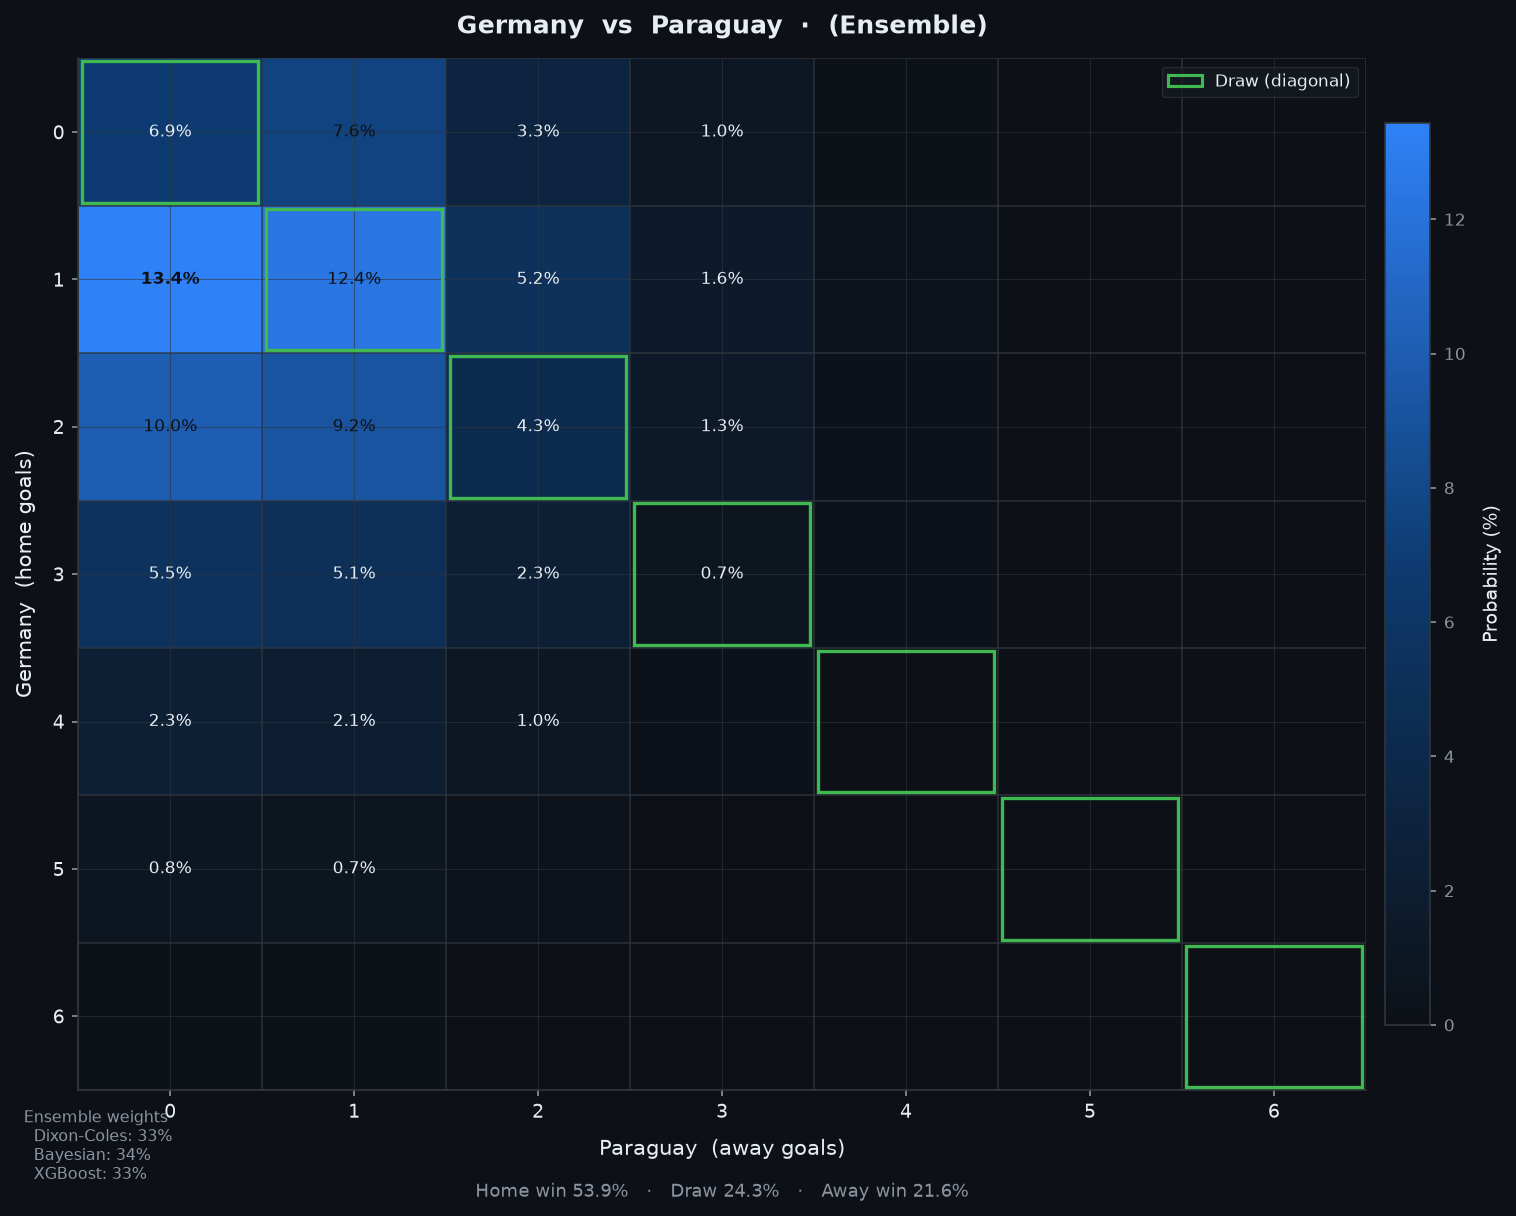

In [193]:
FIG_HEATMAP = plot_score_heatmap(
    ENSEMBLE_MATRIX,
    FIXTURE_HOME_TEAM,
    FIXTURE_AWAY_TEAM,
    max_goals_display=6,
    title_suffix="(Ensemble)",
    model_weights=ENSEMBLE_WEIGHTS,
)
# plt.savefig("heatmap_ensemble.png", bbox_inches="tight")
plt.show()

### 16.3 Per-model comparison panel (optional)

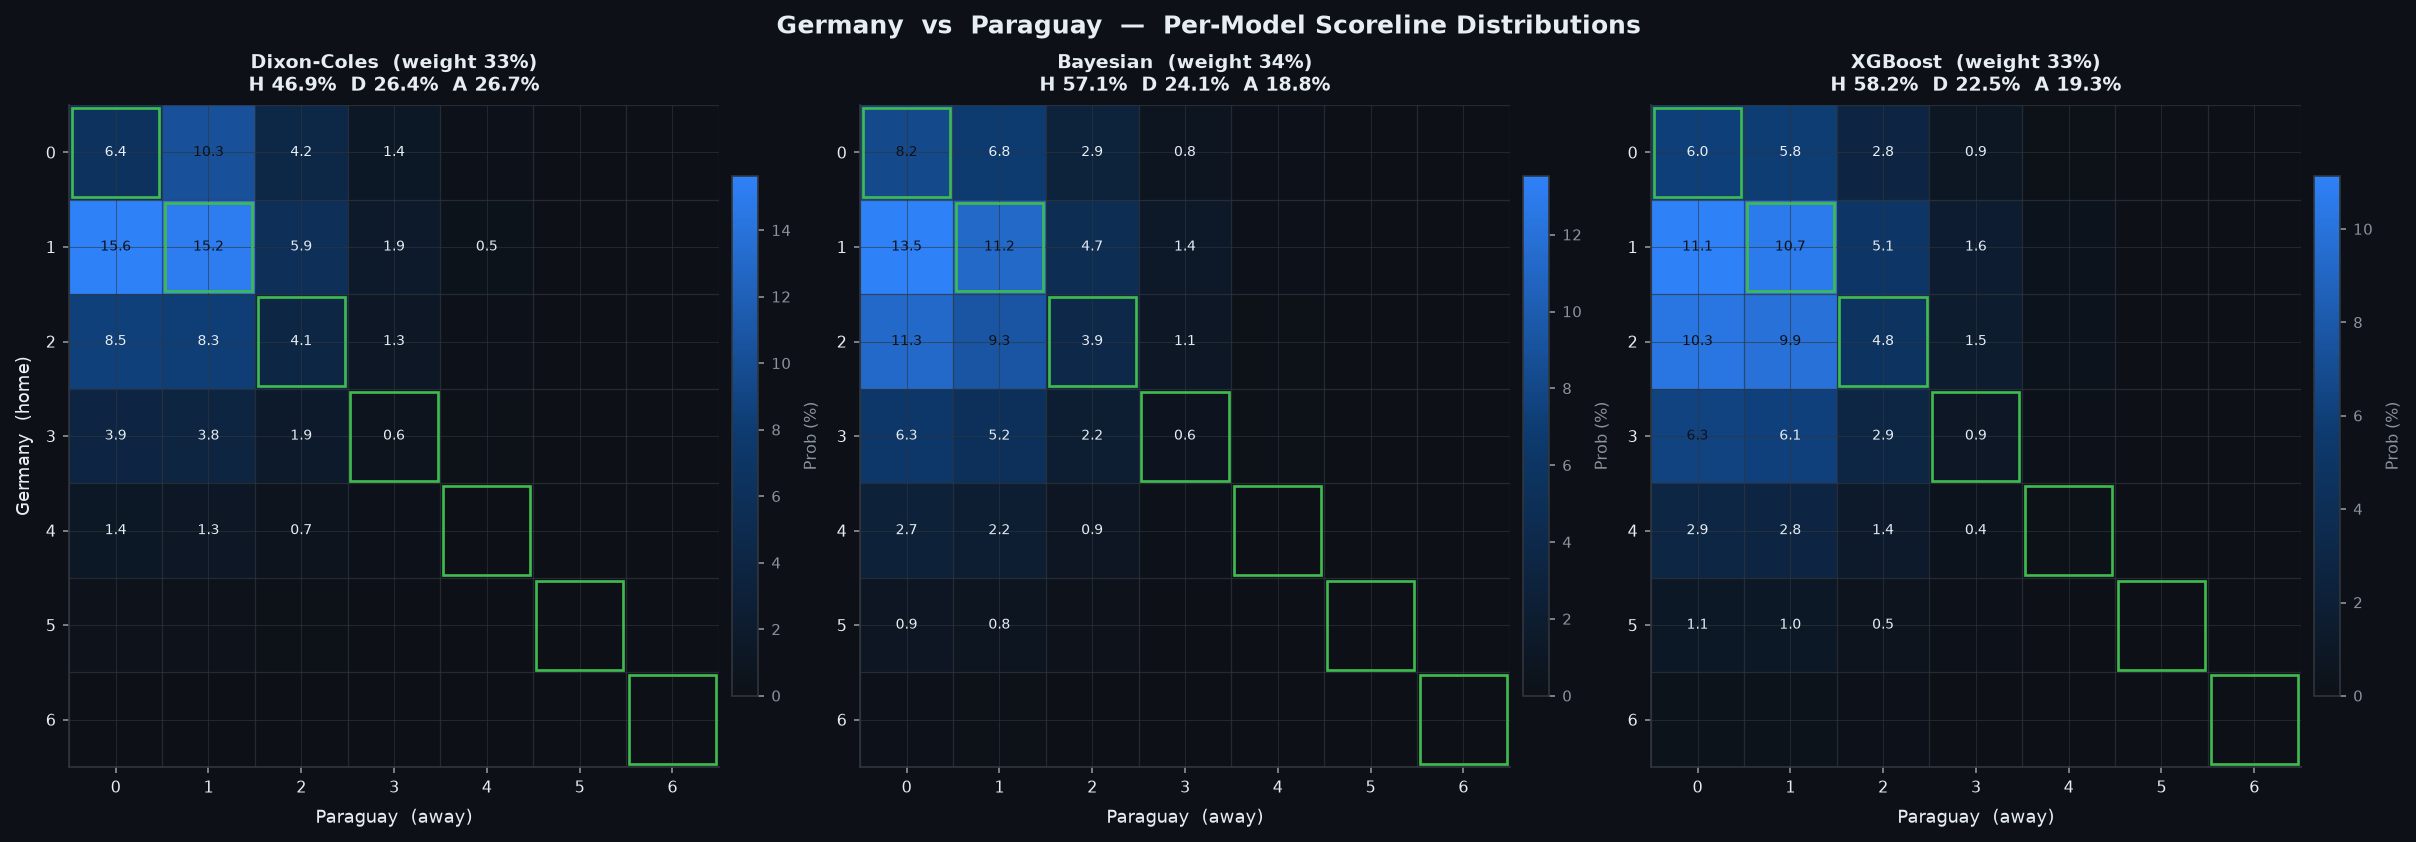

In [194]:
# ── Per-model comparison panel ────────────────────────────────────────────
_model_order = ["Dixon-Coles", "Bayesian", "XGBoost"]

fig_cmp, axes_cmp = plt.subplots(
    1, 3, figsize=(16, 5.5),
    constrained_layout=True,
)
fig_cmp.patch.set_facecolor(_C["bg"])
fig_cmp.suptitle(
    f"{FIXTURE_HOME_TEAM}  vs  {FIXTURE_AWAY_TEAM}  —  Per-Model Scoreline Distributions",
    fontsize=12, fontweight="bold", color=_C["text"],
)

_k_disp = 7   # show 0-6 goals per side in the comparison panel
cmap_cmp = mcolors.LinearSegmentedColormap.from_list(
    "pitch_heat_cmp", [_C["bg"], "#0d3a6e", _C["home"]],
)

for ax, model_name in zip(axes_cmp, _model_order):
    mat  = PREDICTION.per_model_matrices[model_name]
    sub  = mat[:_k_disp, :_k_disp]
    pct  = sub * 100.0
    vmax = max(pct.max(), 1.0)

    im_cmp = ax.imshow(
        pct, cmap=cmap_cmp, aspect="auto",
        vmin=0, vmax=vmax,
        interpolation="nearest", origin="upper",
    )

    # Minor grid
    ax.set_xticks(np.arange(-0.5, _k_disp, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, _k_disp, 1), minor=True)
    ax.grid(which="minor", color=_C["border"], linewidth=0.6, alpha=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Diagonal borders
    for d in range(_k_disp):
        ax.add_patch(mpatches.FancyBboxPatch(
            (d - 0.47, d - 0.47), 0.94, 0.94,
            boxstyle="square,pad=0",
            linewidth=1.3, edgecolor=_C["accent"],
            facecolor="none", zorder=3,
        ))

    # Annotations (suppress below 0.4%)
    for i in range(_k_disp):
        for j in range(_k_disp):
            v = pct[i, j]
            if v < 0.4:
                continue
            cell_norm = sub[i, j] / max(sub.max(), 1e-9)
            ax.text(
                j, i, f"{v:.1f}",
                ha="center", va="center",
                fontsize=6.5,
                color=_C["text"] if cell_norm < 0.55 else _C["bg"],
            )

    ax.set_xticks(range(_k_disp))
    ax.set_yticks(range(_k_disp))
    ax.set_xticklabels(range(_k_disp), fontsize=7.5, color=_C["text"])
    ax.set_yticklabels(range(_k_disp), fontsize=7.5, color=_C["text"])

    _oc = score_matrix_to_outcome_probs(mat)
    _w  = ENSEMBLE_WEIGHTS.get(model_name, 0.0)
    ax.set_title(
        f"{model_name}  (weight {_w:.0%})\n"
        f"H {_oc.p_home_win:.1%}  D {_oc.p_draw:.1%}  A {_oc.p_away_win:.1%}",
        fontsize=9, fontweight="semibold", color=_C["text"], pad=7,
    )
    if ax is axes_cmp[0]:
        ax.set_ylabel(f"{FIXTURE_HOME_TEAM}  (home)", fontsize=8.5,
                      color=_C["text"])
    ax.set_xlabel(f"{FIXTURE_AWAY_TEAM}  (away)", fontsize=8.5,
                  color=_C["text"])

    cb = fig_cmp.colorbar(im_cmp, ax=ax, fraction=0.04, pad=0.02)
    cb.ax.yaxis.set_tick_params(labelsize=7, color=_C["text_muted"])
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=_C["text_muted"])
    cb.outline.set_edgecolor(_C["border"])
    cb.set_label("Prob (%)", fontsize=7.5, color=_C["text_muted"])

# plt.savefig("heatmap_per_model.png", bbox_inches="tight")
plt.show()

---

## Section 17 — Visualization: 1X2 Outcome Bar Chart

Collapses the ensemble scoreline matrix into three outcome probabilities (home win / draw / away win) and renders them as a horizontal bar chart. Each model's 1X2 probabilities are shown as lighter bars behind the ensemble values to make the contribution of each model visible.

### 17.1 `plot_outcome_probabilities`

In [195]:
def plot_outcome_probabilities(
    outcome: "OutcomeProbabilities",
    home_team: str,
    away_team: str,
    per_model_outcomes: dict[str, "OutcomeProbabilities"] | None = None,
    ensemble_weights: dict[str, float] | None = None,
    playoff_outcome: "PlayoffOutcomeProbabilities" | None = None,
) -> matplotlib.figure.Figure:
    """Render 1X2 outcome probabilities as a publication-quality bar chart.

    The ensemble probabilities are shown as solid bars (home blue, draw grey,
    away coral).  If per_model_outcomes is provided, each model's values are
    overlaid as narrow semi-transparent bars to expose model disagreement.

    Args:
        outcome:             Ensemble OutcomeProbabilities.
        home_team:           Dataset name of the home team.
        away_team:           Dataset name of the away team.
        per_model_outcomes:  Dict mapping model name → OutcomeProbabilities.
        ensemble_weights:    Dict mapping model name → weight (for legend).

    Returns:
        matplotlib.figure.Figure
    """
    if playoff_outcome is not None:
        # ── Playoff: four-bar layout ───────────────────────────────────
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
        fig.patch.set_facecolor(_C["bg"])
        ax.set_facecolor(_C["surface"])

        outcomes_4 = [
            (f"{home_team} win (90 min)",   playoff_outcome.p_home_win,           _C["home"]),
            (f"{home_team} win (penalties)", playoff_outcome.p_home_win_penalties, _C["home_pens"]),  # lighter blue
            (f"{away_team} win (penalties)", playoff_outcome.p_away_win_penalties, _C["away_pens"]),  # lighter coral
            (f"{away_team} win (90 min)",   playoff_outcome.p_away_win,           _C["away"]),
        ]

        bar_height  = 0.52
        y_positions = np.arange(len(outcomes_4))

        for y, (label, prob, colour) in zip(y_positions, outcomes_4):
            ax.barh(y, prob, height=bar_height, color=colour, alpha=0.92,
                    linewidth=0, zorder=3)
            x_ann = prob - 0.015 if prob > 0.12 else prob + 0.008
            ha_ann = "right" if prob > 0.12 else "left"
            col_ann = _C["bg"] if prob > 0.12 else _C["text"]
            ax.text(x_ann, y, f"{prob:.1%}", ha=ha_ann, va="center",
                    fontsize=11, fontweight="bold", color=col_ann, zorder=4)

        # Bracket annotation showing total probability of penalties
        _pen_total = playoff_outcome.p_home_win_penalties + playoff_outcome.p_away_win_penalties
        ax.annotate(
            f"P(penalties) = {_pen_total:.1%}",
            xy=(max(playoff_outcome.p_home_win_penalties,
                    playoff_outcome.p_away_win_penalties) + 0.01, 1.5),
            fontsize=8, color=_C["text_muted"],
        )

        ax.set_yticks(y_positions)
        ax.set_yticklabels([lbl for lbl, _, _ in outcomes_4],
                           fontsize=10, color=_C["text"])
        ax.set_xlim(0, 1.0)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_xlabel("Probability", fontsize=9, color=_C["text_muted"], labelpad=6)
        ax.invert_yaxis()
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)
        ax.grid(axis="x", color=_C["border"], linewidth=0.5, alpha=0.5)
        ax.grid(axis="y", visible=False)
        ax.set_title(
            f"{home_team}  vs  {away_team}  —  Playoff Outcome Probabilities",
            fontsize=11.5, fontweight="bold", color=_C["text"], pad=10,
        )
        return fig

    else:
        fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
        fig.patch.set_facecolor(_C["bg"])
        ax.set_facecolor(_C["surface"])

        outcomes = [
            (f"{home_team} win", outcome.p_home_win, _C["home"]),
            ("Draw",             outcome.p_draw,     _C["draw"]),
            (f"{away_team} win", outcome.p_away_win, _C["away"]),
        ]

        bar_height  = 0.52
        y_positions = np.arange(len(outcomes))

        # ── Per-model background bars (rendered first, behind ensemble) ───────
        if per_model_outcomes:
            model_names  = list(per_model_outcomes.keys())
            n_models     = len(model_names)
            sub_h        = bar_height / (n_models + 1)
            model_colours = [_C["home"], _C["away"], _C["accent"]]

            for m_idx, (m_name, m_oc) in enumerate(per_model_outcomes.items()):
                m_vals = [m_oc.p_home_win, m_oc.p_draw, m_oc.p_away_win]
                y_off  = (m_idx - n_models / 2.0) * sub_h * 0.9
                m_col  = model_colours[m_idx % len(model_colours)]
                _w     = ensemble_weights.get(m_name, None) if ensemble_weights else None
                _label = f"{m_name}" + (f"  {_w:.0%}" if _w is not None else "")

                bars_m = ax.barh(
                    y_positions + y_off, m_vals,
                    height=sub_h * 0.75,
                    color=m_col, alpha=0.35, linewidth=0,
                    label=_label,
                    zorder=2,
                )

        # ── Ensemble bars ─────────────────────────────────────────────────────
        for y, (label, prob, colour) in zip(y_positions, outcomes):
            ax.barh(
                y, prob, height=bar_height,
                color=colour, alpha=0.92,
                linewidth=0, zorder=3,
            )
            # Probability annotation inside or outside bar
            x_ann = prob - 0.015 if prob > 0.12 else prob + 0.008
            ha_ann = "right"      if prob > 0.12 else "left"
            col_ann = _C["bg"]    if prob > 0.12 else _C["text"]
            ax.text(
                x_ann, y, f"{prob:.1%}",
                ha=ha_ann, va="center",
                fontsize=11, fontweight="bold", color=col_ann,
                zorder=4,
            )

        # ── Reference line at 33.3 % (uniform baseline) ──────────────────────
        ax.axvline(1 / 3, color=_C["border"], linewidth=1.0,
                linestyle="--", alpha=0.7, zorder=1)
        ax.text(
            1 / 3 + 0.005, -0.55,
            "Equal chance\n(33.3%)",
            fontsize=7.5, color=_C["text_muted"], va="bottom",
        )

        # ── Axes ─────────────────────────────────────────────────────────────
        ax.set_yticks(y_positions)
        ax.set_yticklabels(
            [label for label, _, _ in outcomes],
            fontsize=10.5, color=_C["text"],
        )
        ax.set_xlim(0, 1.0)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_xlabel("Probability", fontsize=9, color=_C["text_muted"], labelpad=6)
        ax.invert_yaxis()
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)
        ax.grid(axis="x", color=_C["border"], linewidth=0.5, alpha=0.5)
        ax.grid(axis="y", visible=False)

        ax.set_title(
            f"{home_team}  vs  {away_team}  —  1X2 Outcome Probabilities",
            fontsize=11.5, fontweight="bold", color=_C["text"], pad=10,
        )

        if per_model_outcomes:
            ax.legend(
                title="Individual models",
                loc="lower right", fontsize=8,
                framealpha=0.8, ncol=1,
            )

        return fig

### 17.2 Render

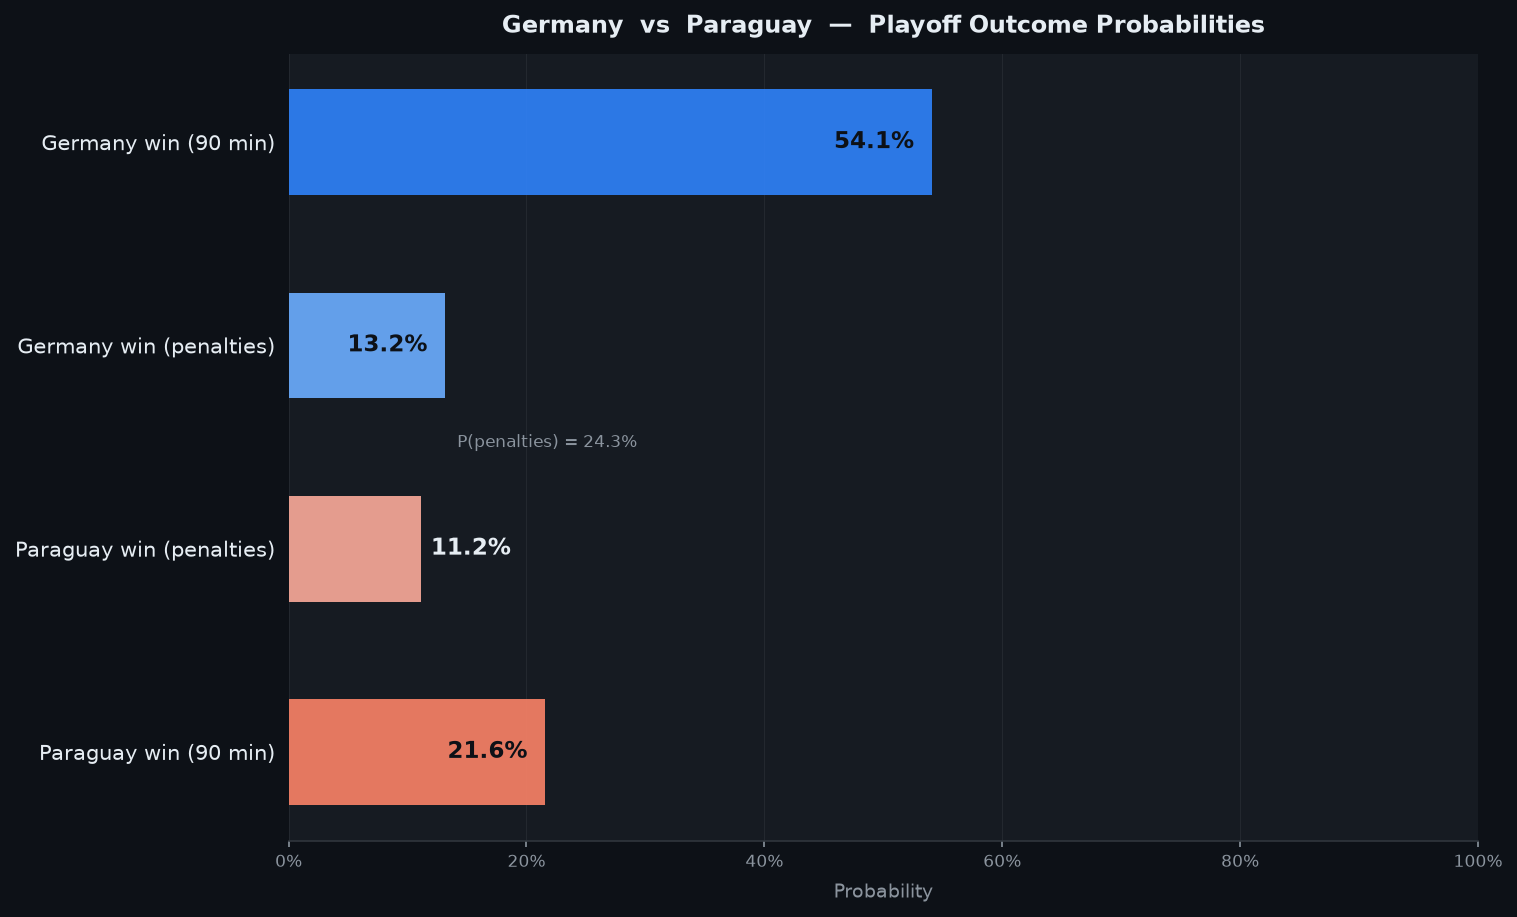

In [196]:
_per_model_outcomes = {
    name: score_matrix_to_outcome_probs(mat)
    for name, mat in PREDICTION.per_model_matrices.items()
}

FIG_OUTCOMES = plot_outcome_probabilities(
    PREDICTION.outcome,
    FIXTURE_HOME_TEAM,
    FIXTURE_AWAY_TEAM,
    per_model_outcomes=_per_model_outcomes,
    ensemble_weights=ENSEMBLE_WEIGHTS,
    playoff_outcome=PREDICTION.playoff_outcome
)
# plt.savefig("outcome_probabilities.png", bbox_inches="tight")
plt.show()

---

## Section 18 — Visualization: Top-10 Scorelines Bar Chart

Ranks the ten most probable exact scorelines from the ensemble matrix and renders them as a vertical bar chart. Bars are colour-coded by outcome type: blue for home-team wins, grey for draws, red for away-team wins.

### 18.1 `plot_top_n_scorelines`

In [197]:
def plot_top_n_scorelines(
    matrix: np.ndarray,
    home_team: str,
    away_team: str,
    n: int = 10,
) -> matplotlib.figure.Figure:
    """Render the top-N most probable exact scorelines as a bar chart.

    Bars are coloured by outcome:
      • Home win  → electric blue
      • Draw      → neutral grey
      • Away win  → coral red

    Each bar is annotated with its probability as a percentage.
    The cumulative probability covered by the displayed scorelines is shown
    as a subtitle annotation.

    Args:
        matrix:    (K+1, K+1) scoreline probability matrix.
        home_team: Dataset name of the home team (x-axis legend).
        away_team: Dataset name of the away team.
        n:         Number of scorelines to display.

    Returns:
        matplotlib.figure.Figure
    """
    scorelines = top_n_scorelines(matrix, n)

    labels = []
    probs  = []
    colors = []
    for (h, a), p in scorelines:
        labels.append(f"{CFG.fixture.home_team_fifa_code} {h}-{a} {CFG.fixture.away_team_fifa_code}")
        probs.append(p)
        if h > a:
            colors.append(_C["home"])
        elif h == a:
            colors.append(_C["draw"])
        else:
            colors.append(_C["away"])

    cumulative = sum(probs)

    fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
    fig.patch.set_facecolor(_C["bg"])
    ax.set_facecolor(_C["surface"])

    x = np.arange(len(labels))
    bars = ax.bar(
        x, probs,
        color=colors, alpha=0.88,
        width=0.62, linewidth=0,
        zorder=3,
    )

    # ── Value annotations ─────────────────────────────────────────────────
    max_p = max(probs)
    for bar, p in zip(bars, probs):
        y_ann = bar.get_height() + max_p * 0.018
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_ann,
            f"{p:.1%}",
            ha="center", va="bottom",
            fontsize=8.5, fontweight="semibold",
            color=_C["text"],
        )

    # ── Axes ─────────────────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9.5, color=_C["text"])
    ax.set_xlim(-0.55, len(labels) - 0.45)
    ax.set_ylim(0, max_p * 1.22)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_ylabel("Probability", fontsize=9, color=_C["text_muted"], labelpad=6)
    ax.grid(axis="y", color=_C["border"], linewidth=0.5, alpha=0.5)
    ax.grid(axis="x", visible=False)
    ax.spines["bottom"].set_color(_C["border"])

    # ── Rank labels ───────────────────────────────────────────────────────
    for i, bar in enumerate(bars, 1):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            -max_p * 0.07,
            f"#{i}",
            ha="center", va="top",
            fontsize=7, color=_C["text_muted"],
            transform=ax.transData,
        )

    # ── Legend ───────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(color=_C["home"], label=f"{home_team} win"),
        mpatches.Patch(color=_C["draw"], label="Draw"),
        mpatches.Patch(color=_C["away"], label=f"{away_team} win"),
    ]
    ax.legend(handles=legend_handles, loc="upper right",
              fontsize=8.5, framealpha=0.8)

    # ── Title and subtitle ────────────────────────────────────────────────
    ax.set_title(
        f"{home_team}  vs  {away_team}  —  Top {n} Most Probable Scorelines",
        fontsize=11.5, fontweight="bold", color=_C["text"], pad=10,
    )
    ax.text(
        0.5, 1.01,
        f"Combined probability of displayed scorelines: {cumulative:.1%}",
        ha="center", va="bottom", fontsize=8, color=_C["text_muted"],
        transform=ax.transAxes,
    )

    return fig

### 18.2 Render

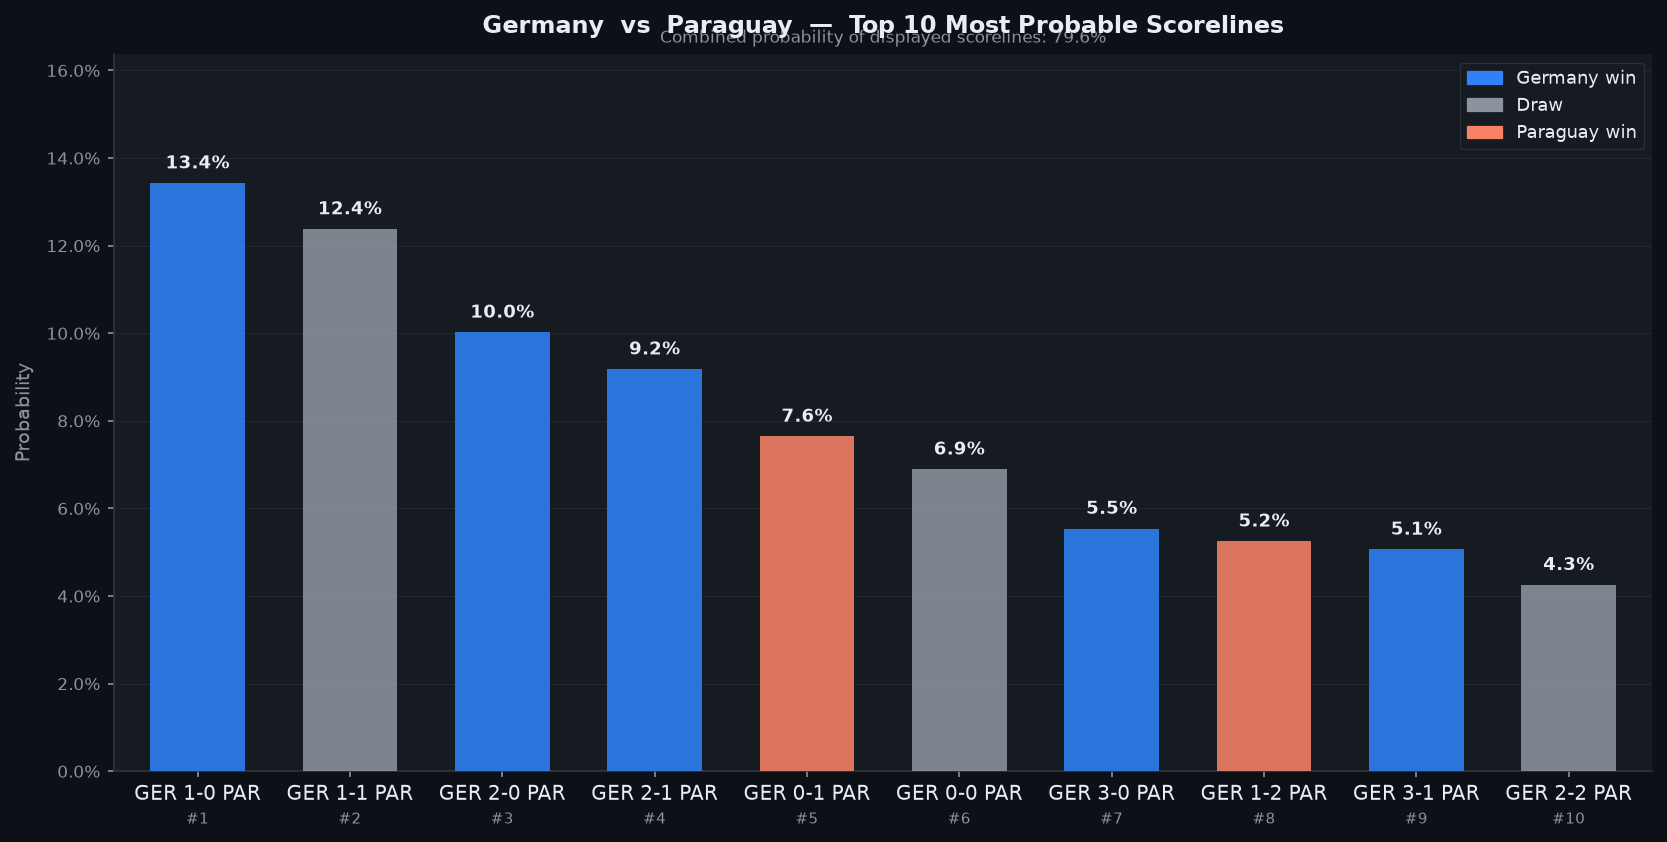

In [198]:
FIG_TOP10 = plot_top_n_scorelines(
    ENSEMBLE_MATRIX,
    FIXTURE_HOME_TEAM,
    FIXTURE_AWAY_TEAM,
    n=10,
)
# plt.savefig("top10_scorelines.png", bbox_inches="tight")
plt.show()

---

## Section 19 — Diagnostic Plots

Supporting plots that allow the reader to audit model quality independently of the headline fixture prediction.

### 19.1 MCMC trace and posterior plots

ArviZ trace plots for `home_advantage`, `intercept`, and the attack/defense parameters for the two headline fixture teams. Confirms chain mixing and stationarity visually.

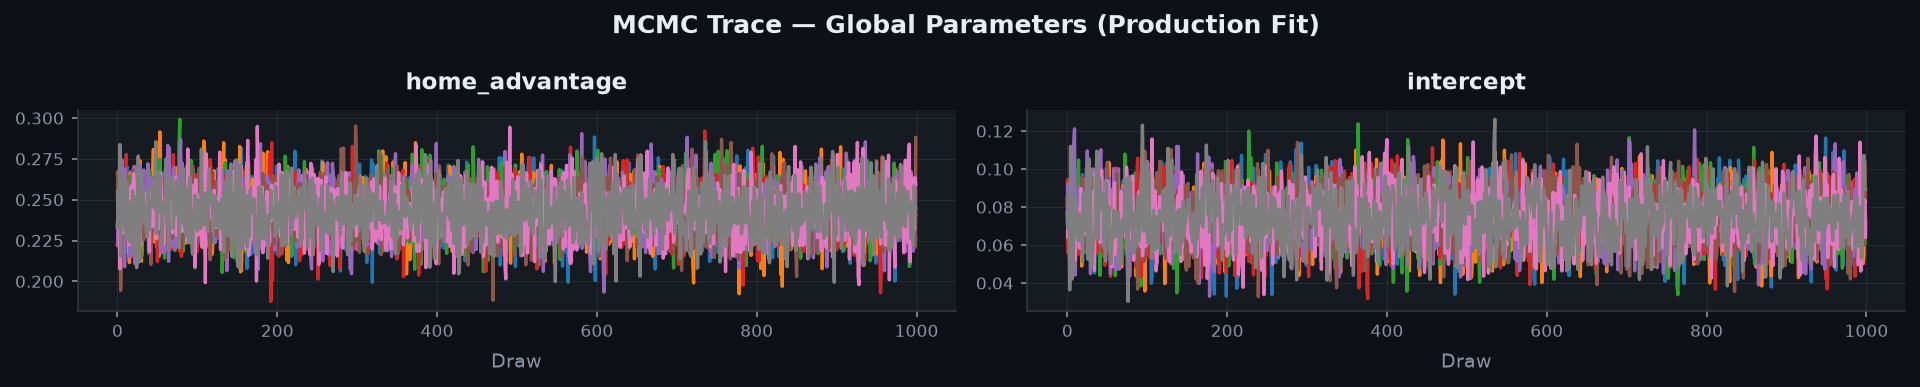

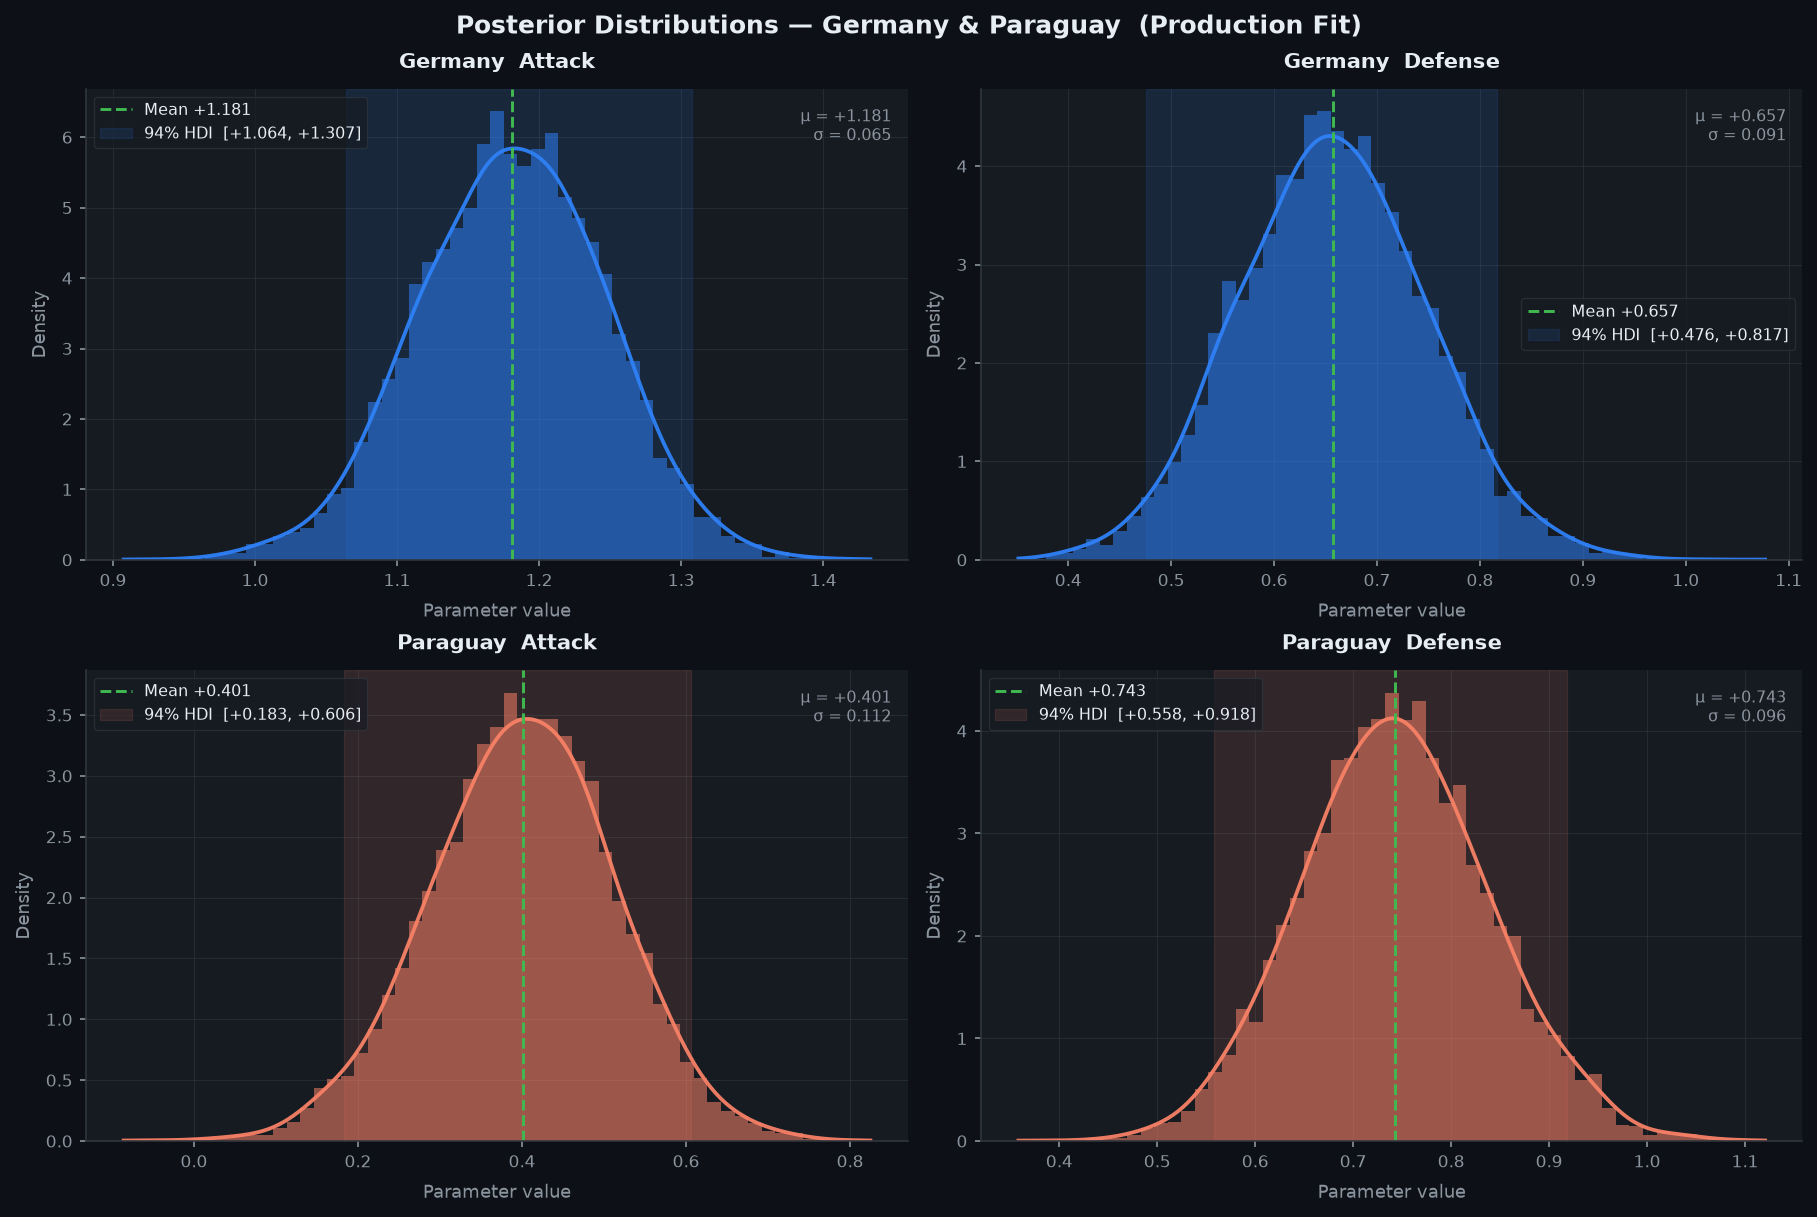

In [199]:
# ── MCMC trace and posterior plots ────────────────────────────────────────
# ArviZ uses its own theming; apply the dark palette via rc_params override.
_arviz_rc = {
    "plot.max_subplots": 40,
}
with az.rc_context(_arviz_rc):
    # Global scalar parameters: home_advantage and intercept
    _trace_fig = az.plot_trace(
        BAYES_IDATA_PROD,
        var_names=["home_advantage", "intercept"],
    )
    _trace_axes = plt.gcf().get_axes()
    _trace_fig = plt.gcf()
    _trace_fig.patch.set_facecolor(_C["bg"])
    for _ax in _trace_axes:
        _ax.set_facecolor(_C["surface"])
        _ax.title.set_color(_C["text"])
        _ax.xaxis.label.set_color(_C["text_muted"])
        _ax.yaxis.label.set_color(_C["text_muted"])
        _ax.tick_params(colors=_C["text_muted"])
        for sp in _ax.spines.values():
            sp.set_edgecolor(_C["border"])
    _trace_fig.suptitle(
        "MCMC Trace — Global Parameters (Production Fit)",
        fontsize=12, fontweight="bold", color=_C["text"],
    )
    plt.tight_layout()
    # plt.savefig("mcmc_trace_global.png", bbox_inches="tight")
    plt.show()

# Per-fixture-team posterior distributions
_home_idx_var = TEAM_INDEX[FIXTURE_HOME_TEAM]
_away_idx_var = TEAM_INDEX[FIXTURE_AWAY_TEAM]

_post_fig, _post_axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
_post_fig.patch.set_facecolor(_C["bg"])
_post_fig.suptitle(
    f"Posterior Distributions — {FIXTURE_HOME_TEAM} & {FIXTURE_AWAY_TEAM}  (Production Fit)",
    fontsize=12, fontweight="bold", color=_C["text"],
)

_post_params = [
    ("attack",  _home_idx_var, f"{FIXTURE_HOME_TEAM}  Attack",  _C["home"]),
    ("defense", _home_idx_var, f"{FIXTURE_HOME_TEAM}  Defense", _C["home"]),
    ("attack",  _away_idx_var, f"{FIXTURE_AWAY_TEAM}  Attack",  _C["away"]),
    ("defense", _away_idx_var, f"{FIXTURE_AWAY_TEAM}  Defense", _C["away"]),
]

for ax, (var, idx, label, colour) in zip(_post_axes.flat, _post_params):
    samples = BAYES_IDATA_PROD.posterior[var].values[:, :, idx].ravel()
    mean_val = samples.mean()
    sd_val   = samples.std()

    ax.set_facecolor(_C["surface"])

    # KDE histogram
    ax.hist(
        samples, bins=55, density=True,
        color=colour, alpha=0.55, linewidth=0,
    )

    # Smooth KDE line
    _kde  = stats.gaussian_kde(samples, bw_method=0.25)
    _xs   = np.linspace(samples.min(), samples.max(), 300)
    ax.plot(_xs, _kde(_xs), color=colour, linewidth=1.8, alpha=0.95)

    # Posterior mean line
    ax.axvline(mean_val, color=_C["accent"], linewidth=1.4,
               linestyle="--", label=f"Mean {mean_val:+.3f}")

    # 94% HDI shading
    hdi_az = az.hdi(samples[np.newaxis, :], prob=0.94)
    hdi = hdi_az[0]
    ax.axvspan(float(hdi[0]), float(hdi[1]), color=colour, alpha=0.12,
               label=f"94% HDI  [{float(hdi[0]):+.3f}, {float(hdi[1]):+.3f}]")

    ax.set_title(label, fontsize=10, fontweight="semibold", color=_C["text"])
    ax.set_xlabel("Parameter value", fontsize=8.5, color=_C["text_muted"])
    ax.set_ylabel("Density", fontsize=8.5, color=_C["text_muted"])
    ax.tick_params(colors=_C["text_muted"])
    for sp in ax.spines.values():
        sp.set_edgecolor(_C["border"])
    ax.legend(fontsize=7.5, framealpha=0.7)
    ax.text(
        0.98, 0.96,
        f"μ = {mean_val:+.3f}\nσ = {sd_val:.3f}",
        ha="right", va="top", fontsize=7.5, color=_C["text_muted"],
        transform=ax.transAxes,
    )

# plt.savefig("posterior_distributions.png", bbox_inches="tight")
plt.show()

### 19.2 Calibration curves

For each model, plot predicted 1X2 probability buckets against observed outcome frequency. A well-calibrated model should produce points close to the diagonal.

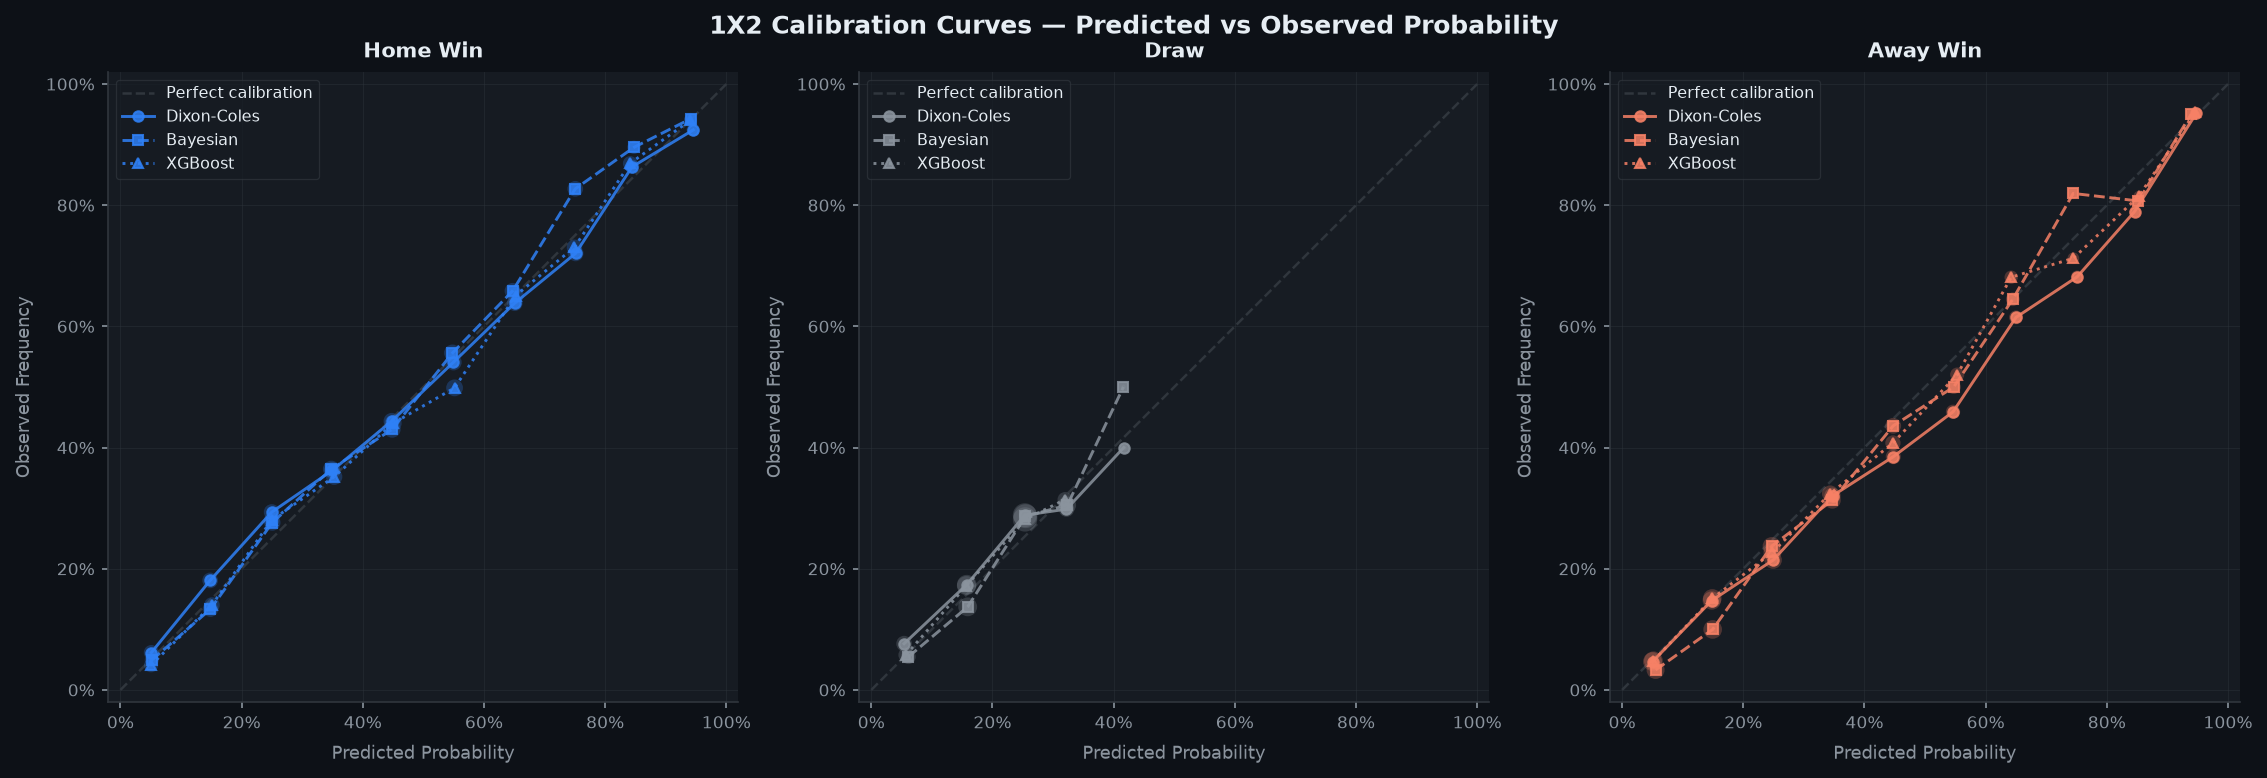

In [200]:
def plot_calibration_curve(
    curves: dict[str, pl.DataFrame],
) -> matplotlib.figure.Figure:
    """Plot 1X2 calibration curves for multiple models on shared axes.

    For each model and each outcome class ('home_win', 'draw', 'away_win'),
    the mean predicted probability in each bin is plotted against the
    observed frequency.  A perfectly calibrated model sits on the diagonal.

    Args:
        curves:         Dict mapping model name → calibration DataFrame
                        (as returned by calibration_curve_1x2).
        outcome_filter: Which outcome class to highlight in the primary panel.
                        One of 'home_win', 'draw', 'away_win'.

    Returns:
        matplotlib.figure.Figure
    """
    outcome_labels = ["home_win", "draw", "away_win"]
    outcome_display = {
        "home_win": "Home Win",
        "draw":     "Draw",
        "away_win": "Away Win",
    }
    outcome_colors  = {
        "home_win": _C["home"],
        "draw":     _C["draw"],
        "away_win": _C["away"],
    }

    model_names   = list(curves.keys())
    model_markers = ["o", "s", "^"]
    model_ls      = ["-", "--", ":"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
    fig.patch.set_facecolor(_C["bg"])
    fig.suptitle(
        "1X2 Calibration Curves — Predicted vs Observed Probability",
        fontsize=12, fontweight="bold", color=_C["text"],
    )

    for ax, outcome in zip(axes, outcome_labels):
        ax.set_facecolor(_C["surface"])

        # Perfect calibration diagonal
        ax.plot(
            [0, 1], [0, 1],
            color=_C["border"], linewidth=1.2,
            linestyle="--", label="Perfect calibration",
        )
        ax.fill_between(
            [0, 1], [0, 1], color=_C["border"], alpha=0.06,
        )

        for (model_name, marker, ls) in zip(model_names, model_markers, model_ls):
            df_model = curves[model_name].filter(pl.col("outcome") == outcome)
            if df_model.is_empty():
                continue

            pred_means = df_model["pred_prob_mean"].to_numpy()
            obs_freqs  = df_model["obs_freq"].to_numpy()
            n_samples  = df_model["n_samples"].to_numpy()

            ax.plot(
                pred_means, obs_freqs,
                color=outcome_colors[outcome],
                linewidth=1.4, linestyle=ls,
                marker=marker, markersize=5,
                alpha=0.85, label=model_name,
            )
            # Bubble size proportional to sample count
            ax.scatter(
                pred_means, obs_freqs,
                s=np.sqrt(n_samples) * 3.5,
                color=outcome_colors[outcome],
                alpha=0.25, linewidths=0, zorder=2,
            )

        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_aspect("equal")
        ax.set_title(
            outcome_display[outcome],
            fontsize=10, fontweight="semibold", color=_C["text"], pad=7,
        )
        ax.set_xlabel("Predicted Probability", fontsize=8.5,
                      color=_C["text_muted"])
        ax.set_ylabel("Observed Frequency", fontsize=8.5,
                      color=_C["text_muted"])
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.tick_params(colors=_C["text_muted"])
        for sp in ax.spines.values():
            sp.set_edgecolor(_C["border"])
        ax.legend(fontsize=7.5, framealpha=0.7, loc="upper left")
        ax.grid(color=_C["border"], linewidth=0.4, alpha=0.5)

    return fig


FIG_CALIBRATION = plot_calibration_curve(CALIBRATION_CURVES)
# plt.savefig("calibration_curves.png", bbox_inches="tight")
plt.show()

### 19.3 Backtest metrics comparison table

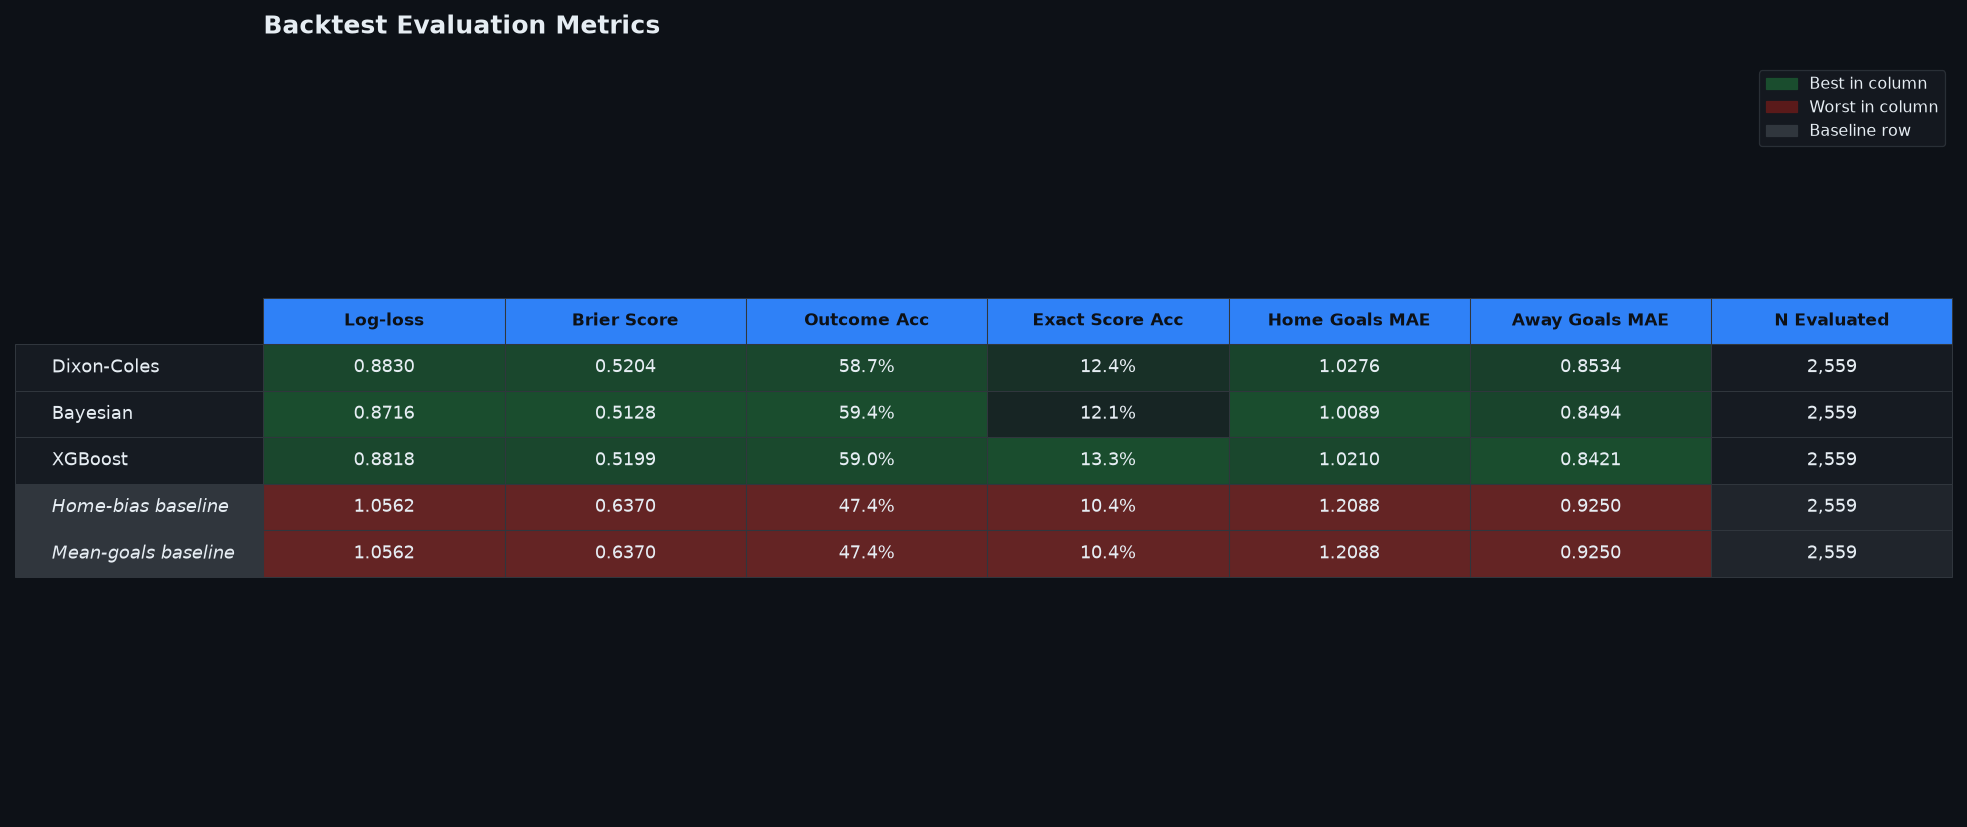

In [201]:
# --- Helper function for colour interpolation between two RGB colours ----------
def _blend(c1: tuple[float, float, float], c2: tuple[float, float, float], t: float) -> tuple[float, float, float]:
    """
    Linear interpolation between two RGB colors.
    
    Args:
        c1: First color as an RGB tuple (r, g, b), each in [0, 1].
        c2: Second color as an RGB tuple (r, g, b), each in [0, 1].
        t: Interpolation factor in [0, 1], where 0 returns c1 and 1 returns c2.
    
    Returns:
        Interpolated color as an RGB tuple (r, g, b).
    """
    c1 = np.asarray(c1)
    c2 = np.asarray(c2)
    return (1 - t) * c1 + t * c2

def plot_backtest_metrics_table(
    metrics: dict[str, "ModelMetrics"],
    real_model_names: list[str],
) -> matplotlib.figure.Figure:
    """Render a colour-coded backtest metrics table as a Matplotlib figure.

    Metric columns are normalised so the best-performing cell (green) and
    worst-performing cell (red) are highlighted.  Baseline rows use a
    lighter background to distinguish them from model rows.

    Args:
        metrics:          Dict mapping model name → ModelMetrics (all entries,
                          including baselines).
        real_model_names: Ordered list of real model names (not baselines).

    Returns:
        matplotlib.figure.Figure
    """
    # Column definitions: (display_name, attribute, lower_is_better)
    _cols = [
        ("Log-loss",         "log_loss",             True),
        ("Brier Score",      "brier_score",           True),
        ("Outcome Acc",      "outcome_accuracy",     False),
        ("Exact Score Acc",  "exact_score_accuracy", False),
        ("Home Goals MAE",   "home_goals_mae",        True),
        ("Away Goals MAE",   "away_goals_mae",        True),
        ("N Evaluated",      "n_evaluated",          False),
    ]

    row_names = list(metrics.keys())
    col_names = [c[0] for c in _cols]

    # Build data array
    data = np.array([
        [getattr(metrics[r], attr) for _, attr, _ in _cols]
        for r in row_names
    ], dtype=float)

    fig, ax = plt.subplots(
        figsize=(13, max(3.5, len(row_names) * 0.72 + 1.8)),
        constrained_layout=True,
    )
    fig.patch.set_facecolor(_C["bg"])
    ax.set_facecolor(_C["bg"])
    ax.axis("off")

    ax.set_title(
        "Backtest Evaluation Metrics",
        fontsize=12, fontweight="bold", color=_C["text"],
        pad=14, loc="left",
    )

    # ── Colour-code cells per column ────────────────────────────────────
    cell_colours = []
    for r_idx, r_name in enumerate(row_names):
        row_colours = []
        is_baseline = r_name not in real_model_names
        for c_idx, (_, _, lower_is_better) in enumerate(_cols):
            col_vals = data[:, c_idx]
            v        = data[r_idx, c_idx]
            mn, mx   = col_vals.min(), col_vals.max()
            rng = mx - mn

            if rng < 1e-9 or col_names[c_idx] == "N Evaluated":
                cell_bg = _C["surface"]
            else:
                # Normalise to [0, 1]; 0 = best, 1 = worst
                norm = (v - mn) / rng
                if not lower_is_better:
                    norm = 1.0 - norm
                # Interpolate: green (best) → surface → red (worst)
                if norm < 0.5:
                    t = norm * 2
                    cell_bg = mcolors.to_hex(
                        _blend(
                            mcolors.to_rgb("#1a4d2e"),   # deep green
                            mcolors.to_rgb(_C["surface"]),
                            t,
                        )
                    )
                else:
                    t = (norm - 0.5) * 2
                    cell_bg = mcolors.to_hex(
                        _blend(
                            mcolors.to_rgb(_C["surface"]),
                            mcolors.to_rgb("#5a1a1a"),   # deep red
                            t,
                        )
                    )

            if is_baseline:
                # Lighten baselines slightly for visual separation
                r, g, b = mcolors.to_rgb(cell_bg)
                cell_bg = mcolors.to_hex(
                    (min(r + 0.04, 1), min(g + 0.04, 1), min(b + 0.04, 1))
                )

            row_colours.append(cell_bg)
        cell_colours.append(row_colours)

    # ── Format cell text ─────────────────────────────────────────────────
    cell_text = []
    for r_idx, r_name in enumerate(row_names):
        row_text = []
        for c_idx, (_, attr, _) in enumerate(_cols):
            v = data[r_idx, c_idx]
            if attr == "n_evaluated":
                row_text.append(f"{int(v):,}")
            elif "accuracy" in attr:
                row_text.append(f"{v:.1%}")
            else:
                row_text.append(f"{v:.4f}")
        cell_text.append(row_text)

    # ── Row labels (italicise baselines) ──────────────────────────────────
    row_labels_display = []
    for r_name in row_names:
        if r_name not in real_model_names:
            row_labels_display.append(f"  {r_name}  ")   # italic-like indent
        else:
            row_labels_display.append(f"  {r_name}  ")

    # ── Render table ─────────────────────────────────────────────────────
    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels_display,
        colLabels=col_names,
        cellColours=cell_colours,
        rowColours=[
            _C["border"] if r not in real_model_names else _C["surface"]
            for r in row_names
        ],
        colColours=[_C["home"]] * len(col_names),
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.55)

    # Style header and row label cells
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(_C["border"])
        cell.set_linewidth(0.5)
        if row == 0:                         # column headers
            cell.set_text_props(color=_C["bg"], fontweight="bold", fontsize=8)
        elif col == -1:                       # row labels
            cell.set_text_props(
                color=_C["text"], fontsize=8.5,
                style="italic" if row_names[row - 1] not in real_model_names
                                else "normal",
            )
        else:
            cell.set_text_props(color=_C["text"], fontsize=8.5)

    # ── Legend annotations ────────────────────────────────────────────────
    _green_patch = mpatches.Patch(color="#1a4d2e", label="Best in column")
    _red_patch   = mpatches.Patch(color="#5a1a1a", label="Worst in column")
    _base_patch  = mpatches.Patch(color=_C["border"], label="Baseline row")
    ax.legend(
        handles=[_green_patch, _red_patch, _base_patch],
        loc="upper right", fontsize=7.5, framealpha=0.8,
        bbox_to_anchor=(1.0, 1.0),
    )

    return fig


FIG_METRICS_TABLE = plot_backtest_metrics_table(ALL_METRICS, _REAL_MODEL_NAMES)
# plt.savefig("backtest_metrics_table.png", bbox_inches="tight")
plt.show()

---

## Section 20 — Summary & Limitations

### Prediction Summary

> This section is populated at runtime by a code cell that formats `PREDICTION` as prose.

### Known Simplifications

1. **Dixon-Coles features are train-window-wide, not per-row rolling.** The DC ratings used as XGBoost features are fit once on the entire training window, then used as a static feature for every training row including early ones. A fully leak-free alternative would refit DC on a strictly trailing window per match, which is computationally expensive and out of scope for this implementation.

2. **Bayesian backtest uses posterior-mean rates, not full posterior predictive.** The backtest metrics for the Bayesian model are computed from posterior-mean attack/defense parameters rather than the average of per-posterior-draw matrices. This is a tractability approximation; the full posterior-predictive treatment is applied only to the headline fixture.

3. **XGBoost matrices have no `tau` correction.** The Dixon-Coles low-score correlation correction is applied only to the DC model's matrices because XGBoost's predictions are independent Poisson means with no joint low-score structure estimated. A future extension could post-multiply XGBoost matrices by the DC fitted `rho`.

4. **Team ratings assume a stationary 2018-present process.** The time-decay weighting partially addresses non-stationarity, but regime changes (coaching, formation, player turnover) are not explicitly modelled. The walk-forward validation is the primary tool for assessing whether this matters for a given fixture.

5. **Injury and squad availability are not modelled.** The system operates entirely on historical match-level results. No player-level data is used, and no adjustment is made for missing key players in the headline fixture.

6. **Core-team minimum-match threshold excludes some nations.** Teams below `TeamFilterConfig.min_matches` receive no rating and cannot be predicted for. This affects primarily Pacific and Caribbean nations with sparse international schedules.

### Risk Register (Summary)

| Risk | Mitigation |
|---|---|
| Random train/test split leakage | Chronological split enforced by a single function |
| Rolling-form feature leakage | Shift-before-rolling, spot-check test in Section 7 |
| Tournament-weight mismatching | Exact-string lookup table; accent-aware keys; warning on unknown names |
| Bayesian non-convergence | Automatic `ConvergenceReport` with pass/fail; notebook warns on failure |
| Optuna peek at test set | Search operates only within `TRAIN_FEATURES` |
| Recency-weight reference date | Explicit `reference_date` parameter; never hardcoded |
| Upstream schema change | `validate_schema` fails immediately with a descriptive diff |
| Stochastic irreproducibility | Every seed is a named config field; no bare `np.random` calls |

### 20.1 Prediction Summary

In [202]:
def print_prediction_summary(
    prediction: FixturePrediction,
    home_fifa: str,
    away_fifa: str,
    all_metrics: dict[str, "ModelMetrics"],
    real_model_names: list[str],
) -> None:
    """Format and print a prose summary of the headline fixture prediction.

    Covers: outcome probabilities, top-10 scorelines, entropy assessment,
    per-model ensemble weights with backtest log-loss, known simplifications,
    and a risk register table.

    Args:
        prediction:       FixturePrediction from Section 15.
        home_fifa:        FIFA three-letter code for the home team (display only).
        away_fifa:        FIFA three-letter code for the away team (display only).
        all_metrics:      ALL_METRICS dict from Section 12 (for log-loss display).
        real_model_names: _REAL_MODEL_NAMES list (excludes baselines).
    """
    home = prediction.home_team
    away = prediction.away_team

    # ── Favorite / lean ───────────────────────────────────────────────────
    if prediction.playoff_outcome is not None:
        playoff_outcome = prediction.playoff_outcome
        p_h = playoff_outcome.p_home_win + playoff_outcome.p_home_win_penalties
        pso_h = playoff_outcome.p_home_win_penalties
        pso_a = playoff_outcome.p_away_win_penalties
        p_a = playoff_outcome.p_away_win + playoff_outcome.p_away_win_penalties
        
        if p_h > p_a and p_h > pso_h and p_h > pso_a:
            lean = f"{Fore.CYAN}leans towards a {home} win on goals"
        elif p_a > p_h and p_a > pso_h and p_a > pso_a:
            lean = f"{Fore.CYAN}leans towards a {away} win on goals"
        elif pso_h > pso_a and pso_h > p_h and pso_h > p_a:
            lean = f"{Fore.CYAN}leans towards a {home} win on penalties"
        elif pso_a > pso_h and pso_a > p_h and pso_a > p_a:
            lean = f"{Fore.CYAN}leans towards a {away} win on penalties"
        else:
            lean = f"{Fore.YELLOW}projects a tightly contested dead heat"
    else:
        p_h = prediction.outcome.p_home_win
        p_d = prediction.outcome.p_draw
        p_a = prediction.outcome.p_away_win

        if p_h > p_a and p_h > p_d:
            lean = f"{Fore.CYAN}leans towards a {home} win"
        elif p_a > p_h and p_a > p_d:
            lean = f"{Fore.CYAN}leans towards a {away} win"
        elif p_d >= p_h and p_d >= p_a:
            lean = f"{Fore.YELLOW}projects the draw as the single most likely outcome"
        else:
            lean = f"{Fore.YELLOW}projects a tightly contested dead heat"

    # ── Entropy / confidence ──────────────────────────────────────────────
    if prediction.entropy > 3.0:
        confidence = f"{Fore.RED}High uncertainty (widely distributed across scorelines)"
    elif prediction.entropy > 2.0:
        confidence = f"{Fore.YELLOW}Moderate uncertainty"
    else:
        confidence = f"{Fore.GREEN}Low uncertainty (probability concentrated on few scorelines)"

    SEP  = f"{Fore.MAGENTA}{'─' * 60}{Style.RESET_ALL}"
    THIN = "─" * 40

    # ── Header ────────────────────────────────────────────────────────────
    print(f"\n{Style.BRIGHT}{Fore.MAGENTA}Section 20 — Summary & Limitations{Style.RESET_ALL}")
    print(SEP)

    # ── Prediction summary ────────────────────────────────────────────────
    print(f"\n{Style.BRIGHT}### 20.1  Prediction Summary{Style.RESET_ALL}\n")
    print(
        f"Based on the backtest-weighted ensemble, the projected outcome for "
        f"{Style.BRIGHT}{home_fifa} vs {away_fifa}{Style.RESET_ALL} "
        f"on {prediction.match_date} {lean}{Style.RESET_ALL}.\n"
    )

    print(f"{Style.BRIGHT}Match Probabilities:{Style.RESET_ALL}")
    print(THIN)
    if CFG.fixture.is_playoff and prediction.playoff_outcome is not None:
        print(f"  • {home_fifa} Win (90 min) : {Fore.GREEN}{p_h:.3%}{Style.RESET_ALL}")
        print(f"  • {home_fifa} Win (pen)    : {Fore.GREEN}{pso_h:.3%}{Style.RESET_ALL}")
        print(f"  • {away_fifa} Win (pen)    : {Fore.RED}{pso_a:.3%}{Style.RESET_ALL}")
        print(f"  • {away_fifa} Win (90 min) : {Fore.RED}{p_a:.3%}{Style.RESET_ALL}\n")
    else:
        print(f"  • {home_fifa} Win : {Fore.GREEN}{p_h:.3%}{Style.RESET_ALL}")
        print(f"  • Draw    : {Fore.YELLOW}{p_d:.3%}{Style.RESET_ALL}")
        print(f"  • {away_fifa} Win : {Fore.RED}{p_a:.3%}{Style.RESET_ALL}\n")

    # ── Top-10 scorelines ─────────────────────────────────────────────────
    print(f"{Style.BRIGHT}Top 10 Most Probable Scorelines:{Style.RESET_ALL}")
    print(THIN)
    for i, ((h, a), p) in enumerate(prediction.top_scorelines[:10], 1):
        scoreline = f"{home_fifa} {h}-{a} {away_fifa}"
        outcome_tag = (
            f"{Fore.CYAN}Home W{Style.RESET_ALL}" if h > a else
            f"{Fore.YELLOW}Draw  {Style.RESET_ALL}" if h == a else
            f"{Fore.RED}Away W{Style.RESET_ALL}"
        )
        print(f"  {i:>2}. {Style.BRIGHT}{scoreline:<14}{Style.RESET_ALL}  {outcome_tag}  {Fore.CYAN}{p:.3%}{Style.RESET_ALL}")

    # ── Entropy ───────────────────────────────────────────────────────────
    print(
        f"\n{Style.BRIGHT}Entropy Analysis:{Style.RESET_ALL} Shannon entropy = "
        f"{Style.BRIGHT}{prediction.entropy:.4f} nats{Style.RESET_ALL} → {confidence}{Style.RESET_ALL}.\n"
    )

    # ── Ensemble weights ──────────────────────────────────────────────────
    print(f"{Style.BRIGHT}Ensemble Weights (from backtest log-loss):{Style.RESET_ALL}")
    print(THIN)
    _col = max(len(n) for n in real_model_names) + 2
    for name in real_model_names:
        w  = prediction.ensemble_weights[name]
        ll = all_metrics[name].log_loss
        n_eval = all_metrics[name].n_evaluated
        print(
            f"  {name:<{_col}}  weight={Fore.GREEN}{w:.4f}{Style.RESET_ALL}"
            f"  log-loss={Fore.YELLOW}{ll:.4f}{Style.RESET_ALL}"
            f"  n_test={n_eval:,}"
        )

# ── Execute ───────────────────────────────────────────────────────────────
print_prediction_summary(
    prediction        = PREDICTION,
    home_fifa         = HOME_TEAM_FIFA_CODE,
    away_fifa         = AWAY_TEAM_FIFA_CODE,
    all_metrics       = ALL_METRICS,
    real_model_names  = _REAL_MODEL_NAMES,
)


Section 20 — Summary & Limitations
────────────────────────────────────────────────────────────

### 20.1  Prediction Summary

Based on the backtest-weighted ensemble, the projected outcome for GER vs PAR on 2026-06-29 leans towards a Germany win on goals.

Match Probabilities:
────────────────────────────────────────
  • GER Win (90 min) : 67.257%
  • GER Win (pen)    : 13.171%
  • PAR Win (pen)    : 11.161%
  • PAR Win (90 min) : 32.743%

Top 10 Most Probable Scorelines:
────────────────────────────────────────
   1. GER 1-0 PAR     Home W  13.426%
   2. GER 1-1 PAR     Draw    12.378%
   3. GER 2-0 PAR     Home W  10.019%
   4. GER 2-1 PAR     Home W  9.179%
   5. GER 0-1 PAR     Away W  7.643%
   6. GER 0-0 PAR     Draw    6.893%
   7. GER 3-0 PAR     Home W  5.539%
   8. GER 1-2 PAR     Away W  5.249%
   9. GER 3-1 PAR     Home W  5.063%
  10. GER 2-2 PAR     Draw    4.255%

Entropy Analysis: Shannon entropy = 2.8482 nats → Moderate uncertainty.

Ensemble Weights (from backtest l